# Task 1: Fashion Item Type Classification

**COSC2753 Machine Learning, Assignment 2 (2026B)**

## Executive Summary

- **Problem.** Predict `articleType` from a 60x80 catalogue image. 37,846 labelled rows and 124 observable classes, with support running from 6,780 images (Tshirts) down to 1. The long tail, not the label space size, is what makes this task hard.
- **Evaluation first.** Section 2 fixes the split, the metrics, and the baselines before any model is fitted. Every later number is scored by the same function on the same rows, so the comparison table is a like-for-like one.
- **Primary metric: macro-F1** over the classes present in validation, reported beside top-1 accuracy, balanced accuracy, top-5 accuracy, and macro-F1 broken down by class support bucket. A single aggregate number cannot separate "learns the head" from "learns the tail" on this distribution.
- **Three models, one rung each.** HOG + linear SVM (does this need deep learning?), a plain CNN trained from scratch (the reference point), and a small ResNet with decoupled classifier retraining (the advanced model). The CNN is kept deliberately plain so the gain of the third model is attributable.
- **Ablations, not extra models.** The imbalance treatments (plain cross-entropy, logit-adjusted cross-entropy, class-balanced classifier retraining) are three rows measured on one architecture, not three separate submissions.
- **Ultimate judgement.** Section 8 goes past the metric table: confusion structure checked against the visual-confusability hypotheses from Section 2.3 of the preprocessing notebook, per-class F1 against support, hierarchical error severity, calibration, and inference cost.

- **Recoverable by construction.** Every fitted model is banked the moment it exists and every training loop checkpoints its full optimiser and generator state each epoch, so an interrupted run resumes where it stopped instead of retraining from Section 3. A configuration fingerprint stored in each file means a checkpoint written under different hyperparameters is ignored rather than silently reused.

All preprocessing decisions are inherited from `00_eda_and_preprocessing.ipynb`. This notebook makes no data decision of its own; it reads the audited manifest and follows the five handover rules in Section 5 of that notebook.

## How to Run

### Prerequisites

This notebook sits in `notebooks/` alongside `00_eda_and_preprocessing.ipynb` and expects the layout that notebook documents:

```
<repository root>
|- notebooks/
|   |- 00_eda_and_preprocessing.ipynb
|   |- 01_task1_article_type.ipynb      <- this file
|- src/
|   |- preprocessing.py                 shared data access, imported below
|- datasets/
|   |- train/images_train/
|   |- test/images_test/
|   |- test/styles_prediction.csv
|- preprocessed_datasets/
|   |- train_manifest.csv               written by notebook 00
|- models/task1/                        created by Section 1.1
|   |- checkpoints/                     per-model and mid-run checkpoints
```

**Run `00_eda_and_preprocessing.ipynb` first.** This notebook fails immediately with a readable message if the manifest is absent.

### Environment

```
pip install torch torchvision numpy pandas scikit-learn scikit-image matplotlib seaborn tqdm
```

A GPU is strongly recommended but not required. End to end on one CUDA GPU this is a roughly four hour run: the recorded run in this notebook's outputs spent 39 minutes on the ResNet backbone alone and 35 on the logit-adjusted ablation, at the 65% duty cycle it used. Section 1.0's worker mode is what brings that down to about an hour of wall-clock across several machines. On CPU expect a day or more, so set `QUICK_RUN = True` in the configuration cell for a structural check first.

### Resource budget

Section 1.0 can cap the notebook at a share of the machine. It takes the whole machine by default (`CPU_BUDGET_FRACTION` and `GPU_BUDGET_FRACTION` at 1.0, `THROTTLE_GPU` off); lower either fraction to run it in the background without starving the rest of the system. The CPU and VRAM caps are hard; the GPU compute cap is a time-share rather than an occupancy limit, and Section 1.0 explains what that does and does not guarantee. None of these settings changes what is learned, and none is part of `RUN_FINGERPRINT`, so a throttled run and an unthrottled one share checkpoints freely.

| Flag | Effect |
|---|---|
| `CPU_BUDGET_FRACTION` | Share of logical cores. Sets the OpenMP/MKL/BLAS thread counts, torch's thread pools, and the HOG worker count. |
| `GPU_BUDGET_FRACTION` | Share of VRAM as a hard allocator ceiling, and the target duty cycle for GPU compute. |
| `THROTTLE_GPU` | Set `False` to keep the memory and CPU caps but let compute run flat out. |
| `PIN_CPU_AFFINITY` | Linux only. Restricts the process to a fixed subset of cores, which is stricter than a thread cap. |
| `THROTTLE_MIN_BATCH_MS` | Batches faster than this are not paced, because the pacing would cost more than the work. |

### Runtime controls

| Flag | Effect |
|---|---|
| `QUICK_RUN` | 3 epochs, one seed, 5,000 training rows. Produces meaningless numbers but exercises every cell in a few minutes. |
| `RUN_SEED_STUDY` | Set `False` to skip the multi-seed variance runs, which are the single most expensive section. |
| `RUN_SALIENCY` | Set `False` to skip the gradient saliency figures. |
| `RESUME` | On by default. Reuses banked models and mid-run epoch checkpoints. Set `False` to force everything to retrain. |
| `CHECKPOINT_EVERY` | Epochs between periodic saves. A new best epoch always saves regardless. |
| `USE_COMPILE` | `torch.compile` the backbones. Faster, slightly different numerics, off by default. |
| `DETERMINISTIC` | Bit-reproducible reruns at roughly 10-20% of throughput. |

### Interrupting and resuming

The notebook is safe to stop at any point. Rerun it from the top and it will rebuild the split and the caches, which are cheap, then restore every model that has already finished and continue the one that had not. Three things make that a resumed run rather than a similar one:

- Mid-run checkpoints carry the optimiser moments, the scheduler position, the gradient scaler and every random generator's state, not only the weights. Restoring weights alone would restart Adam from zero and redraw a different augmentation stream.
- Each file stores a fingerprint of the configuration that produced it. Change a hyperparameter and the stale files are ignored, so a resumed run can never quietly mix two recipes.
- Checkpoints are written through a temporary file and renamed, so a crash during a save leaves the previous checkpoint intact.

Delete `models/task1/checkpoints/` to force a clean run.

### What it produces

- `models/task1/` : the selected model's weights, the class-index mapping, the normalisation constants, and the run configuration.
- `outputs/task1_predictions.csv` : an `articleType` prediction for every row of `styles_prediction.csv`, to be merged with the other tasks' columns before submission.
- `models/task1/task1_results.csv` and `task1_seed_study.csv` : the comparison table and the seed variance runs, written incrementally so an interrupted run keeps them.
- `models/task1/checkpoints/` : one file per fitted model, including every seed-study run, which is what makes the ensembling in Section 10.4 possible without retraining.

## 1. Setup

### 1.0 Resource Budget

This notebook is capped at a fixed share of the machine so it can run in the background
without starving the desktop, another notebook, or a second training job on the same card.
Two numbers in the cell below control it, and everything else is derived from them.

| Resource | Mechanism | Nature of the cap |
|---|---|---|
| CPU threads | `OMP/MKL/OPENBLAS_NUM_THREADS`, `torch.set_num_threads` | Hard. The BLAS and OpenMP pools are sized once and cannot grow. |
| CPU processes | `HOG_N_JOBS`, `LOKY_MAX_CPU_COUNT` | Hard. Bounds the Section 3 HOG worker pool. |
| CPU cores | `PIN_CPU_AFFINITY` (Linux, opt-in) | Hard, and the strictest available: the scheduler will not place this process on the excluded cores at all. |
| VRAM | `torch.cuda.set_per_process_memory_fraction` | Hard. The allocator refuses to grow past the ceiling and raises an ordinary CUDA OOM. |
| GPU compute | duty-cycle throttle | **Soft.** See below. |

**The GPU compute cap is the one to read carefully.** There is no CUDA setting that confines
a process to a fraction of a card's SMs. The mechanisms that genuinely partition a GPU, MPS
with `CUDA_MPS_ACTIVE_THREAD_PERCENTAGE` and MIG, are both configured outside the process,
and MIG needs an A100 or newer. What is available from inside PyTorch is time rather than
occupancy: run a batch, measure how long it took, then sleep long enough that the busy share
of wall-clock time comes out at the target. During the busy window the card is at whatever
occupancy the kernel asks for; during the gap it is idle and free for anything else.

That distinction matters for what you will see in `nvidia-smi`. Averaged over a second the
utilisation figure will sit near the target, because the sampler catches the idle gaps. Sampled
inside a busy window it will read close to 100%, and that is the throttle working as designed,
not failing. If a genuine occupancy cap is required rather than a time-share, MPS or MIG is
the answer and it has to be set up outside this notebook.

The cost is arithmetic: a duty cycle of *d* multiplies runtime by *1/d*. At 0.65 the full
notebook goes from roughly 45-70 minutes to roughly 70-110 minutes on a CUDA GPU. Set
`THROTTLE_GPU = False` to keep the VRAM ceiling and the CPU caps but let the compute run flat out.

None of this changes what is learned. Thread counts, a memory ceiling and a duty cycle are
absent from `RUN_FINGERPRINT` in Section 3 by design, so checkpoints written under one budget
are still valid under another and a throttled run resumes an unthrottled one without complaint.


In [ ]:
# =========================================================================================
# Section 1.0  Execution mode, resource policy, platform
# =========================================================================================
# This cell runs before every other import, and it has to. OpenMP, MKL and OpenBLAS each read
# their thread count once, when the shared library is first loaded, and ignore any later change
# to the environment. Setting these variables after `import numpy` is a no-op that looks like
# it worked, which is why this is a separate cell at the top rather than another block in the
# configuration cell below.

import os
import platform

# --- Execution mode ----------------------------------------------------------------------
# JOB_FILTER = None  -> combine mode. Runs the whole notebook end to end: every model that
#                       already has a checkpoint is restored in a second, everything else is
#                       trained, then all the analysis, diagnostics and the prediction run.
#                       This is the final notebook, and it is correct on a bare machine too.
#
# JOB_FILTER = {...} -> worker mode. Trains only the named jobs, banks their checkpoints, and
#                       stops before the analysis. Ship models/task1/checkpoints/ to the
#                       combine machine afterwards.
#
KNOWN_JOBS = {"hog_svm", "cnn", "resnet", "logit_adjusted", "seeds", "seeds_1337",
              "seeds_2024", "phase2", "sweep", "lrsearch"}

JOB_FILTER = None

COMBINE = JOB_FILTER is None

# A misspelt job trains nothing and still reaches the "worker complete" message at the
# bottom, so the run refuses to start instead. The cost of the alternative is a machine
# that idles for an hour and a combine run that finds no checkpoint.
if not COMBINE:
    _unknown = set(JOB_FILTER) - KNOWN_JOBS
    assert not _unknown, (f"unknown job(s) {sorted(_unknown)}; "
                          f"known jobs are {sorted(KNOWN_JOBS)}")


def wanted(job):
    """True if this machine should train `job` when no checkpoint exists for it.

    A checkpoint always wins over this: `restore` is checked first everywhere, so a worker
    handed a job that is already banked reloads it rather than repeating the work.
    """
    return COMBINE or job in JOB_FILTER


def wanted_seeds(seeds):
    """The seeds this machine should run, in `seeds` order.

    The seed study is three independent runs of two models and, at roughly 113 minutes,
    is more than twice the next longest job. Splitting it by seed is what takes it off
    the critical path: each run banks under its own key, so nothing is shared and the
    parts recombine exactly as the whole would have.

    "seeds" asks for all of them, which is the right job for a single spare machine.
    """
    if COMBINE or "seeds" in JOB_FILTER:
        return list(seeds)
    return [seed for seed in seeds if f"seeds_{seed}" in JOB_FILTER]


# --- Resource policy ---------------------------------------------------------------------
# 1.0 means take the machine. Lower either fraction to leave headroom for other work; the
# CPU share is a hard thread cap and the GPU share becomes a hard VRAM ceiling plus, if
# THROTTLE_GPU is on, a duty cycle that trades runtime for idle gaps other processes can use.
#
# None of this changes what is learned. Thread counts, a memory ceiling and a duty cycle are
# deliberately absent from RUN_FINGERPRINT in Section 3, so a checkpoint written under one
# resource policy stays valid under another and a throttled run resumes an unthrottled one.
CPU_BUDGET_FRACTION = 1.0
GPU_BUDGET_FRACTION = 1.0
THROTTLE_GPU = False
THROTTLE_MIN_BATCH_MS = 2.0
PIN_CPU_AFFINITY = False      # Linux only; ignored elsewhere with a printed note

# sched_getaffinity is the right question to ask rather than cpu_count: inside a container or
# under taskset it reports the cores this process may actually use. It does not exist on
# Windows or macOS, hence the fallback.
try:
    VISIBLE_CORES = len(os.sched_getaffinity(0))
except AttributeError:
    VISIBLE_CORES = os.cpu_count() or 1

CPU_BUDGET_CORES = max(1, int(VISIBLE_CORES * CPU_BUDGET_FRACTION))

for _variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
                  "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "BLIS_NUM_THREADS"):
    os.environ[_variable] = str(CPU_BUDGET_CORES)
os.environ["LOKY_MAX_CPU_COUNT"] = str(CPU_BUDGET_CORES)

if PIN_CPU_AFFINITY:
    try:
        _chosen = sorted(os.sched_getaffinity(0))[:CPU_BUDGET_CORES]
        os.sched_setaffinity(0, set(_chosen))
        print(f"Affinity pinned to cores {_chosen}")
    except (AttributeError, OSError) as _error:
        print(f"Affinity pinning unavailable on this platform, thread caps only: {_error}")

HOST_OS = platform.system()          # 'Linux', 'Windows' or 'Darwin'

print(f"Host                  : {HOST_OS} {platform.machine()} | Python {platform.python_version()}")
print(f"Mode                  : {'combine (everything)' if COMBINE else 'worker ' + str(sorted(JOB_FILTER))}")
print(f"CPU budget            : {CPU_BUDGET_CORES} of {VISIBLE_CORES} logical cores")
print(f"GPU budget            : {GPU_BUDGET_FRACTION:.0%} of VRAM"
      + (f", {GPU_BUDGET_FRACTION:.0%} duty cycle" if THROTTLE_GPU else ", compute unthrottled"))


In [2]:
%matplotlib inline

import gc
import hashlib
import json
import math
import os
import random
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.svm import LinearSVC

# joblib parallelises the HOG descriptor and persists the fitted SVM. Both fall back to a
# serial path if it is absent, so it is a soft dependency rather than a requirement.
try:
    from joblib import Parallel, delayed
    from joblib import dump as joblib_dump
    from joblib import load as joblib_load
    JOBLIB_AVAILABLE = True
except ImportError:
    JOBLIB_AVAILABLE = False

# Only the warning families that are genuinely noise here are silenced. The blanket
# UserWarning filter that used to sit on this line also hid sklearn's "y_pred contains labels
# not in y_true" message, which is precisely the signal this notebook's metric framework
# exists to reason about.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*torch.cuda.amp.*")
warnings.filterwarnings("ignore", message=".*Palette images with Transparency.*")

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8b6fc0", "#e87ba4"]
MUTED = "#6b7280"

In [3]:
# The shared data access module written for notebook 00. Importing it rather than
# redefining the transform is what keeps all four task notebooks reading identical pixels.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

try:
    from src.preprocessing import (
        MANIFEST,
        TEST_IMAGE_DIR,
        IMAGE_TARGET_SIZE,
        compute_normalisation,
        describe_split,
        load_image_array,
        load_manifest,
        make_split,
    )
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        f"Could not import src.preprocessing from {REPO_ROOT}. "
        "This notebook must sit in notebooks/ inside the repository root."
    ) from error

if not MANIFEST.exists():
    raise FileNotFoundError(
        f"{MANIFEST} is missing. Run 00_eda_and_preprocessing.ipynb first; "
        "Section 3.4 of that notebook writes it."
    )

print("Repository root:", REPO_ROOT)
print("Manifest:", MANIFEST)
print("Image target size (w, h):", IMAGE_TARGET_SIZE)

Repository root: C:\Users\Administrator\Downloads\Machine-Learning-Assignment-2-feat-task-1\Machine-Learning-Assignment-2-feat-task-1
Manifest: C:\Users\Administrator\Downloads\Machine-Learning-Assignment-2-feat-task-1\Machine-Learning-Assignment-2-feat-task-1\preprocessed_datasets\train_manifest.csv
Image target size (w, h): (60, 80)


### 1.1 Configuration

Every setting the notebook reuses is defined once here. Two rules govern this cell.

- **Nothing below re-declares a preprocessing constant.** `IMAGE_TARGET_SIZE` and the seed come from `src.preprocessing`, so this notebook cannot silently disagree with the audit that produced the manifest.
- **Every hyperparameter that Section 7 tunes is named here**, so a tuning run changes one cell rather than hunting through the training code.

The defaults are the starting point, not the tuned result. Section 10 lists what to sweep and in what order.

#### Performance and Recovery Notes

Seven settings above are about throughput, memory or recoverability rather than modelling, and
none of them changes what is learned.

- **`ALLOW_CPU = False`** stops the notebook if no GPU is visible. A silent CPU fallback is the
  worst failure mode available here: the ResNet is roughly a hundred times slower on a CPU, which
  presents as a hang rather than an error, and the host-side activations at batch 128 are large
  enough to have the operating system kill the kernel without a traceback.
- **`USE_AMP`** runs the forward and backward passes in bf16 where the card supports it and fp16
  with a gradient scaler otherwise. Parameters, the optimiser state and every reported metric stay
  in fp32.
- **`CACHE_ON_DEVICE`** holds the decoded `uint8` images in VRAM, about 0.6 GB. It removes the same
  amount from host RAM and eliminates the per-batch host-to-device copy.
- **`RESUME`** is the switch that makes an interrupted run cheap. Every finished model is banked
  the moment it exists, and every training loop writes its full optimiser state each epoch, so a
  rerun of the notebook restores what is already done instead of retraining it. Set it `False` to
  force everything to train from scratch.
- **`CHECKPOINT_EVERY`** is how many epochs may pass between saves. A new best epoch is always
  saved regardless, so the best weights are never more than one improvement behind the run.
- **`DETERMINISTIC`** trades roughly 10-20% of throughput for bit-reproducible reruns. It is off by
  default because `cudnn.benchmark` is worth more than exact reproducibility here, and because
  Section 7 measures the run-to-run variation directly rather than assuming it away.
- **`USE_COMPILE`** wraps the models in `torch.compile`. It is off by default: at 60x80 it is worth
  a real speedup, but it changes the numerics slightly and interacts awkwardly with the classifier
  surgery in Section 6.2, so it is opt-in rather than assumed.

Expect roughly a 3-5x speedup over the original CPU-side pipeline on a mid-range GPU, and a host
footprint under 1 GB after Section 3 releases the HOG features.

In [4]:
TARGET = "articleType"
RANDOM_STATE = 42

# --- Runtime controls -------------------------------------------------------------
QUICK_RUN = False        # True: 3 epochs, 1 seed, 5,000 training rows. Structural check only.
RUN_SEED_STUDY = True    # False: skip the multi-seed variance runs (the most expensive section)
RUN_SALIENCY = True      # False: skip the gradient saliency figures

# --- Recovery ---------------------------------------------------------------------
# Nothing here changes what is learned. RESUME only decides whether an already-finished model is
# reloaded or retrained; a restored model is the same weights that were reported when it trained.
RESUME = True            # False: retrain from scratch, ignoring banked models and checkpoints
CHECKPOINT_EVERY = 1     # epochs between periodic saves; a new best epoch always saves
KEEP_EPOCH_CHECKPOINTS = False   # True: keep the mid-run files after a run completes

# --- Performance ------------------------------------------------------------------
# ALLOW_CPU exists to make a silent CPU fallback impossible. Training this ResNet on a CPU is
# roughly a hundred times slower than on a mid-range GPU, which presents as a hang rather than
# as an error, so the notebook refuses to start instead. Set it True only for a QUICK_RUN.
ALLOW_CPU = False
USE_AMP = True           # mixed precision on CUDA. bf16 where supported, else fp16 with a scaler
CHANNELS_LAST = True     # NHWC layout, which is what the tensor-core convolution kernels want
CACHE_ON_DEVICE = True   # hold the uint8 image cache in VRAM: ~0.6 GB, and it frees host RAM
USE_COMPILE = False      # torch.compile the backbones. Faster, but changes numerics slightly.
DETERMINISTIC = False    # bit-reproducible reruns at the cost of cudnn autotuning
HOG_N_JOBS = CPU_BUDGET_CORES   # processes for the Section 3 descriptor, taken from the
                                # Section 1.0 budget. The original -1 meant every core.

# --- Split ------------------------------------------------------------------------
VALIDATION_SHARE = 0.20

# --- Optimisation -----------------------------------------------------------------
BATCH_SIZE = 128
EPOCHS = 40
PATIENCE = 8             # early stopping, measured on validation macro-F1
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 3
LABEL_SMOOTHING = 0.05   # justified by the documented label noise, Section 3.2.2 of notebook 00

# --- Augmentation -----------------------------------------------------------------
AUG_FLIP_PROBABILITY = 0.5
AUG_ROTATION_DEGREES = 10.0
AUG_TRANSLATE_FRACTION = 0.08
AUG_JITTER_STRENGTH = 0.2

# --- Long-tail treatments ---------------------------------------------------------
LOGIT_ADJUST_TAU = 1.0   # Menon et al. (2021); 0 disables the adjustment
STAGE2_EPOCHS = 10       # decoupled classifier retraining, Kang et al. (2020)
STAGE2_LR = 1e-2
# The stage-2 head is trained through the same dropout the forward pass applies at inference.
# Set False to reproduce a stage-2 head trained without it.
STAGE2_USE_DROPOUT = True

# --- Seed variance ----------------------------------------------------------------
SEEDS = [42, 1337, 2024]

# --- Support buckets for the tail-aware metric breakdown --------------------------
SUPPORT_BUCKETS = [
    ("head (>=1000)", 1000, np.inf),
    ("body (100-999)", 100, 1000),
    ("tail (10-99)", 10, 100),
    ("rare (<10)", 0, 10),
]

# --- Output locations -------------------------------------------------------------
ARTEFACT_DIR = REPO_ROOT / "models" / "task1"
CHECKPOINT_DIR = ARTEFACT_DIR / "checkpoints"
OUTPUT_DIR = REPO_ROOT / "outputs"
PREDICTION_TEMPLATE = REPO_ROOT / "datasets" / "test" / "styles_prediction.csv"

if QUICK_RUN:
    EPOCHS, STAGE2_EPOCHS, WARMUP_EPOCHS = 3, 2, 1
    SEEDS = [RANDOM_STATE]
    RUN_SEED_STUDY = False
    ALLOW_CPU = True     # a structural check is allowed to be slow; it must not be blocked

FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in (ARTEFACT_DIR, CHECKPOINT_DIR, OUTPUT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def save_figure(name):
    """Write the current figure to outputs/figures/ so the report can reference a file.

    Call this immediately BEFORE plt.show(). In the inline backend show() closes the figure,
    so a savefig placed after it writes a blank page, which is a quiet failure rather than
    an error.
    """
    plt.savefig(FIGURE_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

print("QUICK_RUN:", QUICK_RUN, "| epochs:", EPOCHS, "| seeds:", SEEDS)
print("RESUME:", RESUME, "| checkpoints ->", CHECKPOINT_DIR)

QUICK_RUN: False | epochs: 40 | seeds: [42, 1337, 2024]
RESUME: True | checkpoints -> C:\Users\Administrator\Downloads\Machine-Learning-Assignment-2-feat-task-1\Machine-Learning-Assignment-2-feat-task-1\models\task1\checkpoints


In [5]:
def set_seed(seed):
    """Seed every generator this notebook draws from.

    Torch, NumPy and Python are all seeded because the augmentation, the weight
    initialisation and the batch order each draw from a different one. Without all three,
    a "same seed" rerun is not actually a rerun.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def capture_rng_state():
    """Every generator's state, so a resumed run continues the same random stream.

    Without this, resuming at epoch 20 would draw a different augmentation sequence from the
    one an uninterrupted run would have drawn, and the resumed run would not be the same run.
    """
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state


def restore_rng_state(state):
    """Reinstate the generators captured by `capture_rng_state`."""
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].cpu() if torch.is_tensor(state["torch"])
                        else state["torch"])
    if "cuda" in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all([s.cpu() for s in state["cuda"]])


# --- Device selection, in preference order -----------------------------------------------
# CUDA where it exists, then Apple Silicon's Metal backend, then CPU. MPS is checked through
# getattr because the attribute is absent on torch builds older than 1.12 rather than merely
# reporting False, and an AttributeError here would be a confusing way to learn that.
_mps = getattr(torch.backends, "mps", None)
HAS_MPS = bool(_mps is not None and _mps.is_available())

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif HAS_MPS:
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if DEVICE.type == "cuda":
    name = torch.cuda.get_device_name(0)
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    capability = torch.cuda.get_device_capability(0)
    print(f"GPU: {name} | {total:.1f} GB | compute capability {capability[0]}.{capability[1]}")
    print(f"torch {torch.__version__} built against CUDA {torch.version.cuda}")

    # A wheel without kernels for this card fails here rather than mid-epoch, and the failure
    # is a clear one instead of a process that disappears without a traceback.
    try:
        _ = (torch.zeros(8, device=DEVICE) + 1).sum().item()
    except RuntimeError as error:
        raise RuntimeError(
            f"CUDA is visible but cannot execute a kernel on this card: {error}\n"
            "This is the usual symptom of a PyTorch build without kernels for your GPU. "
            "RTX 50-series cards need a CUDA 12.8 build:\n"
            "  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128"
        ) from error

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # --- VRAM ceiling, only when one was asked for ------------------------------------
    # At GPU_BUDGET_FRACTION = 1.0 this is skipped entirely and the allocator behaves
    # normally. Below 1.0 it is a hard cap: the allocator refuses to grow past it and raises
    # an ordinary CUDA OOM, so an overrun arrives as an exception with a traceback rather
    # than as a machine that starts thrashing or an unrelated process killed by the driver.
    if GPU_BUDGET_FRACTION >= 1.0:
        print(f"VRAM: uncapped ({total:.1f} GB available to this process)")
    else:
        try:
            torch.cuda.set_per_process_memory_fraction(GPU_BUDGET_FRACTION, 0)
            budget_gb = total * GPU_BUDGET_FRACTION
            print(f"VRAM ceiling: {GPU_BUDGET_FRACTION:.0%} of {total:.1f} GB = "
                  f"{budget_gb:.1f} GB ({total - budget_gb:.1f} GB left for others)")
            if budget_gb < 2.5:
                print("  Warning: tight for this configuration. If it OOMs, set "
                      "CACHE_ON_DEVICE = False first (frees ~0.6 GB, costs a little "
                      "throughput). Lowering BATCH_SIZE also works but changes "
                      "RUN_FINGERPRINT, invalidating every checkpoint on disk.")
        except (AttributeError, RuntimeError) as error:
            print("Could not set a VRAM ceiling on this build:", error)

elif DEVICE.type == "mps":
    # Apple Silicon. Considerably slower than a discrete CUDA card for this workload but far
    # faster than the CPU fallback, so it does not need the ALLOW_CPU guard below.
    print(f"Apple Silicon GPU (Metal) | torch {torch.__version__}")
    print("  Mixed precision, channels_last and the on-device image cache are CUDA-only "
          "paths and stay off here. Results are unchanged; throughput is lower.")
    os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

elif not ALLOW_CPU:
    raise RuntimeError(
        "No CUDA or MPS device. Training the ResNet on a CPU takes roughly 10 minutes per "
        "epoch per thousand images, which looks like a hang rather than an error.\n"
        "Either install an accelerated build of PyTorch, or set ALLOW_CPU = True in "
        "Section 1.1 to accept the slowdown deliberately.\n"
        "ALLOW_CPU is absent from RUN_FINGERPRINT, so a CPU run still produces "
        "checkpoints the other machines accept. QUICK_RUN is not: setting it changes "
        "the fingerprint and orphans this machine's work.\n"
        "The hog_svm job is HOG plus liblinear and never touches the GPU, which makes "
        "it the one worth handing to a machine without one."
    )
else:
    print("Running on CPU by explicit request (ALLOW_CPU = True). Expect this to be slow.")

# Determinism is a deliberate trade rather than a default. cudnn.benchmark autotunes the
# convolution algorithm for this fixed input size and is worth real throughput; turning it off
# together with deterministic kernels is what makes two same-seed runs bit-identical.
if DETERMINISTIC:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except (AttributeError, RuntimeError) as error:
        print("Deterministic algorithms unavailable:", error)
else:
    torch.backends.cudnn.benchmark = DEVICE.type == "cuda"

# --- Torch's own thread pools ------------------------------------------------------
# The environment variables in Section 1.0 bound OpenMP, which is what the CPU convolution and
# BLAS kernels use. These two bound torch's own intra-op and inter-op pools, which are sized
# separately. Both matter on a CPU fallback run; the intra-op pool also covers the host-side
# tensor work in a CUDA run.
torch.set_num_threads(CPU_BUDGET_CORES)
try:
    torch.set_num_interop_threads(max(1, CPU_BUDGET_CORES // 2))
except RuntimeError:
    pass          # already fixed, or parallel work has been dispatched; not an error here
print(f"Torch threads: {torch.get_num_threads()} intra-op, "
      f"{torch.get_num_interop_threads()} inter-op")

# bf16 has the dynamic range of fp32 and needs no loss scaling. Turing cards such as the T4
# lack it, so fp16 with a gradient scaler is the fallback. Neither changes what is learned.
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"
AMP_DTYPE = (torch.bfloat16 if AMP_ENABLED and torch.cuda.is_bf16_supported() else torch.float16)
CHANNELS_LAST = CHANNELS_LAST and DEVICE.type == "cuda"
CACHE_ON_DEVICE = CACHE_ON_DEVICE and DEVICE.type == "cuda"
# torch.compile needs a C compiler toolchain that Windows notebooks usually lack, and the
# Inductor backend does not target MPS. Restricting it to Linux + CUDA turns a confusing
# mid-run compilation failure into a printed line.
if USE_COMPILE and not (hasattr(torch, "compile") and DEVICE.type == "cuda"
                        and HOST_OS == "Linux"):
    print(f"torch.compile disabled: unsupported on {HOST_OS} / {DEVICE.type}.")
    USE_COMPILE = False

print(f"Device: {DEVICE.type}")
print(f"Mixed precision: {AMP_ENABLED} ({str(AMP_DTYPE).replace('torch.', '') if AMP_ENABLED else 'fp32'})"
      f" | channels_last: {CHANNELS_LAST} | image cache on device: {CACHE_ON_DEVICE}")
print(f"cudnn.benchmark: {torch.backends.cudnn.benchmark} | deterministic: {DETERMINISTIC} "
      f"| torch.compile: {USE_COMPILE}")

set_seed(RANDOM_STATE)
print("Seeded at", RANDOM_STATE)

GPU: NVIDIA GeForce RTX 5070 | 12.8 GB | compute capability 12.0
torch 2.11.0+cu128 built against CUDA 12.8
VRAM ceiling: 65% of 12.8 GB = 8.3 GB (4.5 GB left for other processes)
Torch threads: 18 intra-op, 9 inter-op
Mixed precision: True (bfloat16) | channels_last: True | image cache on device: True
cudnn.benchmark: True | deterministic: False | torch.compile: False
Seeded at 42


## 2. Data and the Evaluation Framework

This section is built first and then frozen. Nothing after it may change the split, the metric
definitions, or the baselines, because a comparison table is only meaningful if every row was
scored the same way on the same rows.

### 2.1 The Split

`make_split` implements rules 1, 3 and 4 of the handover in Section 5 of notebook 00: whole
`group_id` values stay on one side so byte-identical images cannot leak across, the draw is
stratified on the label, and classes with fewer than two groups go entirely to training because
a class with one example cannot also be evaluated.

The consequence worth stating up front is the **classes absent from validation** count printed
below. Those classes are trainable but unscoreable. Every macro average in this notebook is
therefore computed over the classes present in validation, and the absent count is reported
beside it so the denominator is never ambiguous.

In [6]:
frame = load_manifest(TARGET)
print(f"Rows carrying an {TARGET} label: {len(frame):,}")
print(f"Distinct classes in the manifest: {frame[TARGET].nunique()}")

train_frame, val_frame = make_split(
    frame, TARGET, validation_share=VALIDATION_SHARE, random_state=RANDOM_STATE
)

if QUICK_RUN:
    # Stratified where possible; a plain sample is enough for a structural check.
    train_frame = train_frame.sample(n=min(5000, len(train_frame)), random_state=RANDOM_STATE)
    train_frame = train_frame.reset_index(drop=True)
    print("QUICK_RUN: training rows reduced to", len(train_frame))

display(describe_split(train_frame, val_frame, TARGET))

Rows carrying an articleType label: 37,846
Distinct classes in the manifest: 124


,Target,Training rows,Validation rows,Achieved validation share %,Classes in training,Classes in validation,Classes absent from validation
0,articleType,30278,7568,19.996829,124,110,14


In [7]:
# Label encoding. Fixed to the sorted training classes and persisted in Section 9, because
# reconstructing it later from a different frame would silently permute every prediction.
CLASSES = sorted(train_frame[TARGET].unique())

if QUICK_RUN:
    # The subsample above can drop whole classes, which would leave validation rows with no
    # index to map to. Full runs never enter this branch: make_split keeps every class in training.
    keep = val_frame[TARGET].isin(CLASSES)
    print(f"QUICK_RUN: dropping {int((~keep).sum())} validation rows whose class was "
          "removed by the training subsample.")
    val_frame = val_frame.loc[keep].reset_index(drop=True)

CLASS_TO_INDEX = {label: index for index, label in enumerate(CLASSES)}
N_CLASSES = len(CLASSES)

# Any validation class absent from training cannot be predicted. make_split sends
# single-group classes to training, so this should be empty; the check is what proves it.
unseen = sorted(set(val_frame[TARGET]) - set(CLASSES))
assert not unseen, f"Validation holds classes never seen in training: {unseen}"

y_train = train_frame[TARGET].map(CLASS_TO_INDEX).to_numpy()
y_val = val_frame[TARGET].map(CLASS_TO_INDEX).to_numpy()

train_support = pd.Series(np.bincount(y_train, minlength=N_CLASSES), index=CLASSES)
val_support = pd.Series(np.bincount(y_val, minlength=N_CLASSES), index=CLASSES)
SCOREABLE = np.flatnonzero(val_support.to_numpy() > 0)   # class indices macro averages use

print(f"Classes: {N_CLASSES}")
print(f"Scoreable in validation: {len(SCOREABLE)} | absent: {N_CLASSES - len(SCOREABLE)}")
print(f"Training support range: {train_support.max():,} down to {train_support.min()}")
print("Absent from validation:", sorted(np.array(CLASSES)[val_support.to_numpy() == 0]))

Classes: 124
Scoreable in validation: 110 | absent: 14
Training support range: 5,267 down to 1
Absent from validation: [np.str_('Baby Dolls'), np.str_('Body Wash and Scrub'), np.str_('Concealer'), np.str_('Cushion Covers'), np.str_('Ipad'), np.str_('Key chain'), np.str_('Lehenga Choli'), np.str_('Lounge Tshirts'), np.str_('Rain Jacket'), np.str_('Rain Trousers'), np.str_('Robe'), np.str_('Shapewear'), np.str_('Shoe Laces'), np.str_('Ties and Cufflinks')]


In [8]:
# Support buckets, assigned from TRAINING support so the grouping is a property of the
# learning problem rather than of the particular validation draw.
def assign_bucket(count):
    for name, low, high in SUPPORT_BUCKETS:
        if low <= count < high:
            return name
    return SUPPORT_BUCKETS[-1][0]


BUCKET_OF_CLASS = train_support.map(assign_bucket)
BUCKET_INDICES = {
    name: np.array([CLASS_TO_INDEX[c] for c in BUCKET_OF_CLASS.index[BUCKET_OF_CLASS == name]])
    for name, _, _ in SUPPORT_BUCKETS
}

bucket_table = pd.DataFrame([
    {
        "Bucket": name,
        "Classes": len(indices),
        "Scoreable in validation": len(np.intersect1d(indices, SCOREABLE)),
        "Training images": int(train_support.to_numpy()[indices].sum()) if len(indices) else 0,
        "Share of training images %": (
            train_support.to_numpy()[indices].sum() / len(y_train) * 100 if len(indices) else 0.0
        ),
    }
    for name, indices in BUCKET_INDICES.items()
])
display(bucket_table.style.format({"Share of training images %": "{:.1f}%"}))

,Bucket,Classes,Scoreable in validation,Training images,Share of training images %
0,head (>=1000),8,8,16654,55.0%
1,body (100-999),33,33,11728,38.7%
2,tail (10-99),48,48,1770,5.8%
3,rare (<10),35,21,126,0.4%


#### Why the Buckets Matter More Than the Headline

The table above is the reason a single macro-F1 is not enough on its own. A handful of head
classes account for most of the images while most of the classes hold a small fraction of them,
so two models with the same macro-F1 can have completely different failure profiles: one may be
competent everywhere and mediocre on the head, the other excellent on the head and near zero on
the tail. Reporting macro-F1 per bucket separates those two cases, and it is the breakdown that
Section 8 uses to choose between the finalists.

### 2.2 Loading the Images into Memory

The whole training set is 60x80x3 bytes per image, so all 37,846 images occupy roughly 545 MB as
`uint8`. Holding them in RAM and decoding once is worth doing: it removes JPEG decoding from every
epoch, which on images this small is otherwise the dominant cost and would leave the GPU idle.

**This section now runs before the normalisation constants rather than after them.** In the
original order the training images were decoded twice, once inside `compute_normalisation` and
once again to build this cache, which is a full redundant pass over 30,000 JPEG files. Section 2.3
now reads the constants off this array instead, so each file is opened exactly once for the whole
notebook.

Augmentation still happens per epoch on tensors, so nothing about the training distribution is
frozen by this cache. Only the deterministic transform from Section 3.1 of notebook 00 is applied
here, exactly once per image.

In [9]:
def build_image_cache(frame, description):
    """Decode a frame's images once through the shared transform into one uint8 array.

    Only the deterministic transform from Section 3.1 of notebook 00 is applied here, exactly
    once per image. Augmentation still happens per epoch, so nothing about the training
    distribution is frozen by this cache.

    Returns:
        Array of shape (rows, height, width, 3), dtype uint8, in the frame's row order.
    """
    width, height = IMAGE_TARGET_SIZE
    images = np.empty((len(frame), height, width, 3), dtype=np.uint8)
    start = time.time()
    for position, path in enumerate(frame["path"]):
        images[position] = load_image_array(path, target_size=IMAGE_TARGET_SIZE, scale=False)
        if position and position % 10000 == 0:
            print(f"  {description}: {position:,} / {len(frame):,}")
    print(f"{description}: {len(frame):,} images in {time.time() - start:.0f}s "
          f"({images.nbytes / 1e6:.0f} MB)")
    return images


def report_memory(label=""):
    """Host RSS and, on CUDA, device allocation. Cheap, and it makes a leak visible early."""
    line = []
    try:
        import resource
        peak_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        line.append(f"host peak {peak_kb / 1e6:.2f} GB")
    except (ImportError, AttributeError):
        try:
            import psutil
            line.append(f"host RSS {psutil.Process().memory_info().rss / 1e9:.2f} GB")
        except ImportError:
            pass
    if DEVICE.type == "cuda":
        line.append(f"device allocated {torch.cuda.memory_allocated() / 1e9:.2f} GB "
                    f"reserved {torch.cuda.memory_reserved() / 1e9:.2f} GB")
    print(f"[memory{' ' + label if label else ''}] " + " | ".join(line))


X_train_images = build_image_cache(train_frame, "train")
X_val_images = build_image_cache(val_frame, "validation")

assert len(X_train_images) == len(y_train) and len(X_val_images) == len(y_val)
report_memory("after caching")

  train: 10,000 / 30,278
  train: 20,000 / 30,278
  train: 30,000 / 30,278
train: 30,278 images in 11s (436 MB)
validation: 7,568 images in 3s (109 MB)
[memory after caching] host RSS 1.48 GB | device allocated 0.00 GB reserved 0.00 GB


### 2.3 Normalisation Constants

Rule 5 of the handover: fitted on the training rows only, then applied unchanged to validation
and to the test set. The constants are persisted in Section 9 because inference must reproduce
them exactly; recomputing them at prediction time on a different population would shift the
input distribution the model was trained for.

They are computed from the `uint8` cache built above rather than by re-reading the files. It is
the same pooled mean and standard deviation over the same training rows and the same transform,
accumulated in float64 so the sums are exact at this scale, and it costs a fraction of a second
instead of a second decode pass. `VERIFY_NORMALISATION` re-runs `compute_normalisation` from
notebook 00 and asserts the two agree; run it once to satisfy yourself, then leave it off.

In [10]:
VERIFY_NORMALISATION = False   # True: re-decode from disk and assert the constants match

start = time.time()
# Sums are taken over the raw 0-255 values in float32 and divided by 255 at the end, which is
# the same statistic as scaling first: sum(x/255) is sum(x)/255, and the same for the squares.
# The reductions accumulate into float64, so the running totals stay exact at this scale while
# the working chunk stays float32. Promoting the chunk itself to float64 would cost four bytes
# per channel per pixel twice over, once for the chunk and once for its square.
total = np.zeros(3, dtype=np.float64)
total_square = np.zeros(3, dtype=np.float64)
n_pixels = 0
for begin in range(0, len(X_train_images), 2048):
    chunk = X_train_images[begin:begin + 2048].astype(np.float32)
    total += chunk.sum(axis=(0, 1, 2), dtype=np.float64)
    total_square += np.einsum("nhwc,nhwc->c", chunk, chunk, dtype=np.float64)
    n_pixels += chunk.shape[0] * chunk.shape[1] * chunk.shape[2]

mean_raw = total / n_pixels
variance_raw = np.maximum(total_square / n_pixels - mean_raw ** 2, 0.0)
NORM_MEAN = (mean_raw / 255.0).astype(np.float32)
NORM_STD = np.maximum(np.sqrt(variance_raw) / 255.0, 1e-6).astype(np.float32)

print(f"Fitted on {len(train_frame):,} training rows in {time.time() - start:.1f}s "
      "(from the cache, no second decode pass)")
print("Mean (R, G, B):", np.round(NORM_MEAN, 4))
print("Std  (R, G, B):", np.round(NORM_STD, 4))

if VERIFY_NORMALISATION:
    reference_mean, reference_std = compute_normalisation(train_frame,
                                                          target_size=IMAGE_TARGET_SIZE)
    print("Reference mean:", np.round(reference_mean, 4))
    print("Reference std: ", np.round(reference_std, 4))
    assert np.allclose(NORM_MEAN, reference_mean, atol=1e-4), "Mean disagrees with notebook 00"
    assert np.allclose(NORM_STD, reference_std, atol=1e-4), "Std disagrees with notebook 00"
    print("Verified against compute_normalisation.")

# White studio backgrounds dominate, so a mean near 0.9 is the expected result rather than a bug.
assert (NORM_MEAN > 0.5).all(), "Unexpectedly dark mean; check the transform before continuing."

# --- Run identity ------------------------------------------------------------------------
# A checkpoint is only safe to reuse if it was produced by the same problem and the same
# recipe. The fingerprint below is stored inside every checkpoint and compared on load, so
# changing a hyperparameter silently invalidates the old files instead of silently reusing
# them. Section 5 is where that machinery lives; the value is computed here because the
# normalisation constants above are its last input, and Section 3 banks the SVM before
# Section 5 is reached.
RUN_FINGERPRINT = hashlib.sha1(json.dumps({
    "target": TARGET, "classes": N_CLASSES, "train_rows": int(len(y_train)),
    "val_rows": int(len(y_val)), "seed": RANDOM_STATE, "quick": QUICK_RUN,
    "validation_share": VALIDATION_SHARE, "batch": BATCH_SIZE, "epochs": EPOCHS,
    "patience": PATIENCE, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    "warmup": WARMUP_EPOCHS, "label_smoothing": LABEL_SMOOTHING,
    "aug": [AUG_FLIP_PROBABILITY, AUG_ROTATION_DEGREES, AUG_TRANSLATE_FRACTION,
            AUG_JITTER_STRENGTH],
    "tau": LOGIT_ADJUST_TAU, "stage2": [STAGE2_EPOCHS, STAGE2_LR, STAGE2_USE_DROPOUT],
    "norm": [NORM_MEAN.round(5).tolist(), NORM_STD.round(5).tolist()],
}, sort_keys=True).encode()).hexdigest()[:12]
print("Run fingerprint:", RUN_FINGERPRINT)

Fitted on 30,278 training rows in 4.3s (from the cache, no second decode pass)
Mean (R, G, B): [0.8492 0.8325 0.8267]
Std  (R, G, B): [0.2719 0.2832 0.2869]


### 2.4 Augmentation Policy and Batching

The policy is unchanged from the original notebook. Each choice follows from a finding in
notebook 00 rather than from a default recipe.

| Transform | Justification |
|---|---|
| Horizontal flip, p=0.5 | Catalogue shots have no meaningful left-right orientation, so a flip produces a plausible product photograph. |
| Rotation +/- 10 degrees, translate +/- 8%, fill white | Simulates the small framing variation the catalogue already contains. White fill matches `IMAGE_PAD_RGB`, so an augmented border is indistinguishable from the padding the transform itself applies. |
| Colour jitter 0.2 | `baseColour` is not the target and is excluded from inputs, so colour invariance is desirable: it discourages the model from using colour as a shortcut for article type. |
| **No vertical flip** | Upside-down garments do not occur; the augmentation would move the training distribution away from the test distribution. |
| **No random crop** | Section 3.1 of notebook 00 argues the portrait frame carries class cues at both the top and bottom of a product. A crop deletes exactly the evidence that separates similar article types. |

#### What Changed, and Why It Does Not Change the Policy

The original implementation used `torchvision.transforms` inside a `Dataset`, which applies each
transform to one image at a time on the CPU. At 60x80 the model is small enough that this made
the CPU the bottleneck: the GPU spent most of each epoch waiting for batches, and every image
passed through the host as a separate Python-level call.

This version applies the identical transforms to a whole batch on the device, with **per-sample
random parameters** so that augmentation diversity is exactly what it was before. Two details are
worth stating because they are the only places the implementations differ:

- **Rotation is corrected for the aspect ratio.** `affine_grid` works in normalised coordinates,
  where a naive rotation matrix shears a non-square image. The matrix below rescales by 80/60 so
  the rotation is a true rotation in pixel space, which is what `torchvision` does.
- **White fill is obtained by offsetting.** `grid_sample` can only pad with zeros, so the batch is
  shifted by -1, sampled, and shifted back, which makes out-of-frame pixels exactly 1.0, that is
  white. This is identical to `fill=1.0`, not an approximation of it.

Colour jitter applies brightness, then saturation, then contrast in a fixed order rather than the
shuffled order `torchvision` uses. With independent per-sample factors drawn from the same range,
the resulting distribution of images is equivalent for this purpose.

The `uint8` cache is uploaded to the device once. It costs about 0.6 GB of VRAM and removes the
same amount from host RAM, along with the per-batch host-to-device transfer.

In [11]:
LUMA = torch.tensor([0.299, 0.587, 0.114], device=DEVICE).view(1, 3, 1, 1)
NORM_MEAN_T = torch.tensor(NORM_MEAN, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
NORM_STD_T = torch.tensor(NORM_STD, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)


def augment_batch(x):
    """Apply the Section 2.4 policy to a batch, with independent parameters per sample.

    Args:
        x: float tensor of shape (n, 3, height, width) with values in [0, 1].

    Returns:
        A tensor of the same shape and range.
    """
    n = x.shape[0]
    device = x.device

    # Horizontal flip. torch.where selects per sample, so the draw is genuinely per image.
    flip = torch.rand(n, device=device) < AUG_FLIP_PROBABILITY
    x = torch.where(flip.view(-1, 1, 1, 1), x.flip(-1), x)

    # Rotation and translation in one affine warp. The height/width factors correct for
    # affine_grid's normalised coordinates, without which the rotation would shear.
    height, width = x.shape[-2], x.shape[-1]
    angle = (torch.rand(n, device=device) * 2 - 1) * math.radians(AUG_ROTATION_DEGREES)
    shift_x = (torch.rand(n, device=device) * 2 - 1) * AUG_TRANSLATE_FRACTION * 2
    shift_y = (torch.rand(n, device=device) * 2 - 1) * AUG_TRANSLATE_FRACTION * 2
    cos, sin = torch.cos(angle), torch.sin(angle)

    theta = torch.zeros(n, 2, 3, device=device)
    theta[:, 0, 0] = cos
    theta[:, 0, 1] = -sin * height / width
    theta[:, 0, 2] = shift_x
    theta[:, 1, 0] = sin * width / height
    theta[:, 1, 1] = cos
    theta[:, 1, 2] = shift_y

    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    # Offset by -1 so that grid_sample's zero padding lands on white once shifted back.
    x = F.grid_sample(x - 1.0, grid, mode="bilinear", padding_mode="zeros",
                      align_corners=False) + 1.0

    # Colour jitter: brightness, saturation, contrast, each with its own per-sample factor.
    def factor():
        return 1.0 + (torch.rand(n, 1, 1, 1, device=device) * 2 - 1) * AUG_JITTER_STRENGTH

    x = x * factor()
    grey = (x * LUMA).sum(dim=1, keepdim=True)
    x = (x - grey) * factor() + grey
    mean = grey.mean(dim=(2, 3), keepdim=True)
    x = (x - mean) * factor() + mean

    return x.clamp_(0.0, 1.0)


class BatchStream:
    """Device-resident batches, replacing Dataset plus DataLoader.

    The images are held once as uint8 in the device's memory and converted to float per batch,
    so nothing is copied from the host during training and the host holds no per-batch buffers.

    Args:
        images: uint8 array of shape (rows, height, width, 3), or an existing device tensor
            to share with another stream.
        labels: integer class indices aligned to `images`.
        batch_size: rows per batch.
        augment: apply the Section 2.4 policy. Training only.
        shuffle: reorder each epoch. Ignored when `weights` is given.
        weights: per-row sampling weights for class-balanced draws with replacement. Used by
            the decoupled stage in Section 6.2.
    """

    def __init__(self, images, labels, batch_size=None, augment=False, shuffle=False,
                 weights=None):
        if torch.is_tensor(images):
            self.images = images                      # shared with another stream, not copied
        else:
            self.images = torch.from_numpy(np.ascontiguousarray(images))
            if CACHE_ON_DEVICE:
                self.images = self.images.to(DEVICE, non_blocking=True)
        # Labels may arrive as an array or as an existing device tensor from `variant`,
        # which avoids a pointless round trip through host memory on every derived stream.
        self.labels = (labels.to(device=DEVICE, dtype=torch.long) if torch.is_tensor(labels)
                       else torch.as_tensor(np.asarray(labels), dtype=torch.long,
                                            device=DEVICE))
        self.batch_size = batch_size or BATCH_SIZE
        self.augment = augment
        self.shuffle = shuffle
        if weights is None:
            self.weights = None
        elif torch.is_tensor(weights):
            self.weights = weights.to(device=self.images.device, dtype=torch.double)
        else:
            self.weights = torch.as_tensor(np.asarray(weights), dtype=torch.double,
                                           device=self.images.device)

    def variant(self, **overrides):
        """A stream over the same device tensor with different batching or sampling."""
        settings = {"batch_size": self.batch_size, "augment": self.augment,
                    "shuffle": self.shuffle, "weights": self.weights}
        settings.update(overrides)
        return BatchStream(self.images, self.labels, **settings)

    def __len__(self):
        return math.ceil(len(self.labels) / self.batch_size)

    def _order(self):
        n = len(self.labels)
        if self.weights is not None:
            return torch.multinomial(self.weights, n, replacement=True)
        if self.shuffle:
            return torch.randperm(n, device=self.images.device)
        return torch.arange(n, device=self.images.device)

    def __iter__(self):
        order = self._order()
        for start in range(0, len(order), self.batch_size):
            index = order[start:start + self.batch_size]
            batch = self.images[index].to(DEVICE, non_blocking=True)
            x = batch.permute(0, 3, 1, 2).float().div_(255.0)
            if self.augment:
                x = augment_batch(x)
            x = (x - NORM_MEAN_T) / NORM_STD_T
            if CHANNELS_LAST:
                x = x.contiguous(memory_format=torch.channels_last)
            yield x, self.labels[index.to(self.labels.device)]


def make_loaders(batch_size=BATCH_SIZE, weights=None):
    """Training and validation streams. Reuses the uploaded tensors; nothing is re-copied."""
    return (train_loader.variant(batch_size=batch_size, weights=weights,
                                 shuffle=weights is None),
            val_loader)


train_loader = BatchStream(X_train_images, y_train, BATCH_SIZE, augment=True, shuffle=True)
val_loader = BatchStream(X_val_images, y_val, 512, augment=False, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))
print("Batch tensor:", tuple(batch_images.shape), batch_images.dtype, batch_images.device)
print(f"Normalised range: [{batch_images.min():.2f}, {batch_images.max():.2f}]")
print(f"Batches per epoch: {len(train_loader)}")
report_memory("after upload")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2864\236806125.py:84: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  else torch.as_tensor(np.asarray(labels), dtype=torch.long,


Batch tensor: (128, 3, 80, 60) torch.float32 cuda:0
Normalised range: [-3.12, 0.60]
Batches per epoch: 237
[memory after upload] host RSS 1.98 GB | device allocated 0.56 GB reserved 0.61 GB


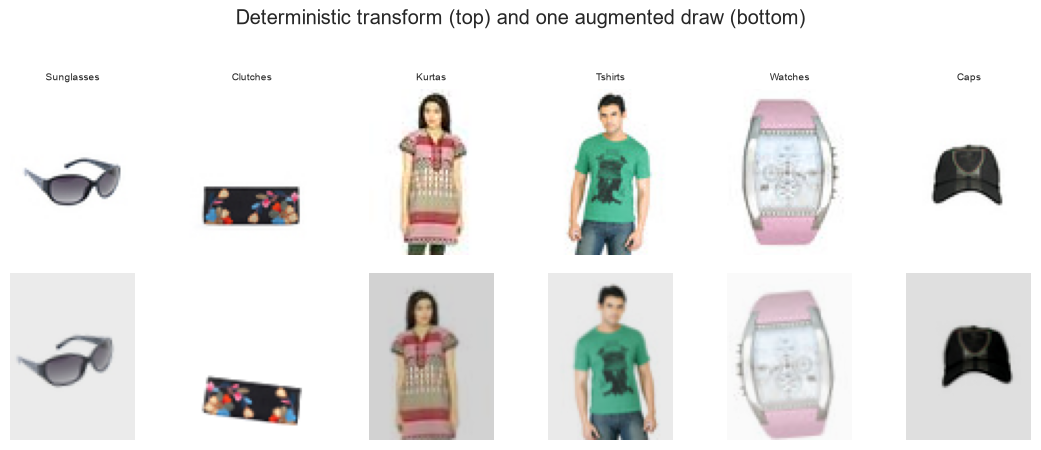

Corner pixels after augmentation: min 0.825, mean 0.921 (1.0 is white)


In [12]:
# Look at what the model actually receives. An augmentation bug is far cheaper to catch here
# than to diagnose from a training curve.
def to_displayable(x01):
    """A [0, 1] CHW tensor as an HWC array ready for imshow."""
    return x01.detach().float().clamp(0, 1).permute(1, 2, 0).cpu().numpy()


sample_positions = np.random.RandomState(RANDOM_STATE).choice(len(y_train), 6, replace=False)
index = torch.as_tensor(sample_positions, device=train_loader.images.device)
raw = train_loader.images[index].to(DEVICE).permute(0, 3, 1, 2).float().div(255.0)

set_seed(RANDOM_STATE)
augmented = augment_batch(raw.clone())

fig, axes = plt.subplots(2, 6, figsize=(11, 4.4))
for column in range(6):
    axes[0, column].imshow(to_displayable(raw[column]))
    axes[0, column].set_title(CLASSES[y_train[sample_positions[column]]], fontsize=7)
    axes[1, column].imshow(to_displayable(augmented[column]))
    for row in range(2):
        axes[row, column].axis("off")
fig.suptitle("Deterministic transform (top) and one augmented draw (bottom)", y=1.02)
plt.tight_layout(); save_figure("01_augmentation_preview"); plt.show()

# White padding must survive the warp: an augmented border darker than the studio background
# would be a fill colour bug, and would teach the model a border cue that the test set lacks.
corners = augmented[:, :, :2, :2]
print(f"Corner pixels after augmentation: min {corners.min():.3f}, mean {corners.mean():.3f} "
      "(1.0 is white)")

### 2.5 Metrics

One function scores every model in this notebook. Five headline numbers plus the bucket
breakdown, each answering a different question.

| Metric | Question it answers |
|---|---|
| Top-1 accuracy | How often is the system exactly right? Dominated by the head, and comparable to published work. |
| **Macro-F1** | How well does it do averaged over classes rather than images? The primary metric, because every article type matters to a catalogue regardless of stock volume. |
| Balanced accuracy | Macro-recall. Read beside macro-F1 it separates "misses tail classes" from "over-predicts tail classes". |
| Weighted F1 | Macro-F1's image-weighted counterpart, for readers who care about aggregate throughput. |
| Top-5 accuracy | The realistic figure for a tagging assistant that proposes candidates for a human to confirm. |

All macro averages are taken over `SCOREABLE`, the classes with at least one validation example.

In [13]:
def evaluate_predictions(y_true, y_pred, scores=None, name=""):
    """Score one model's validation predictions.

    Args:
        y_true: integer class indices.
        y_pred: integer class indices.
        scores: optional (rows, N_CLASSES) array of logits, probabilities, or decision
            values. Only the ranking is used, so any monotone score works for top-5.
        name: row label in the results table.

    Returns:
        A one-row DataFrame.
    """
    row = {
        "Model": name,
        "Top-1 accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, labels=SCOREABLE, average="macro", zero_division=0),
        # Macro-recall over the scoreable classes. This is what balanced_accuracy_score computes
        # on this data, since it drops zero-support classes internally, but stating the label set
        # explicitly makes the denominator the same one macro-F1 uses instead of an implicit one.
        "Balanced accuracy": recall_score(y_true, y_pred, labels=SCOREABLE, average="macro",
                                          zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if scores is not None:
        # argpartition is O(n) in the class count against argsort's O(n log n), and the
        # membership test is vectorised rather than a Python loop over 7,500 rows.
        k = min(5, scores.shape[1])
        top_k = np.argpartition(scores, -k, axis=1)[:, -k:]
        row["Top-5 accuracy"] = float((top_k == np.asarray(y_true)[:, None]).any(axis=1).mean())
    else:
        row["Top-5 accuracy"] = np.nan

    per_class = f1_score(
        y_true, y_pred, labels=np.arange(N_CLASSES), average=None, zero_division=0
    )
    for bucket, indices in BUCKET_INDICES.items():
        scoreable_in_bucket = np.intersect1d(indices, SCOREABLE)
        row[f"F1 {bucket}"] = (
            float(per_class[scoreable_in_bucket].mean()) if len(scoreable_in_bucket) else np.nan
        )

    return pd.DataFrame([row])


def per_class_f1(y_true, y_pred):
    """Per-class F1 as a Series indexed by class name, restricted to scoreable classes."""
    scores = f1_score(y_true, y_pred, labels=np.arange(N_CLASSES), average=None, zero_division=0)
    return pd.Series(scores, index=CLASSES).iloc[SCOREABLE]


RESULTS = []   # every scored model appends its one-row frame here


def record(result_frame):
    """Add a scored row to the comparison table and write the table to disk.

    Two behaviours matter for a notebook that can be resumed. Re-scoring a model that is
    already in the table replaces its row rather than duplicating it, so re-running a cell
    after a restart cannot produce two rows for one model. And the table is written after
    every row, so an interrupted run keeps the comparison it had already earned.
    """
    global RESULTS
    name = result_frame["Model"].iloc[0]
    RESULTS = [r for r in RESULTS if r["Model"].iloc[0] != name] + [result_frame]
    pd.concat(RESULTS, ignore_index=True).to_csv(ARTEFACT_DIR / "task1_results.csv", index=False)
    display(result_frame.style.format({c: "{:.4f}" for c in result_frame.columns if c != "Model"}))
    return result_frame

### 2.6 Baselines

Two, and neither is a strawman.

- **Majority class** always predicts the most frequent training class. Its accuracy is the number
  any model must beat before its accuracy means anything, and its macro-F1 near zero is the
  concrete demonstration that accuracy is the wrong headline for this target.
- **Stratified random** samples from the training class prior. It is the floor for macro-F1
  specifically: a model that scores below it has learned nothing transferable about the tail.

In [14]:
majority_index = int(np.bincount(y_train, minlength=N_CLASSES).argmax())
majority_pred = np.full_like(y_val, majority_index)
majority_scores = np.zeros((len(y_val), N_CLASSES))
majority_scores[:, majority_index] = 1.0
print(f"Majority class: {CLASSES[majority_index]} "
      f"({train_support.iloc[majority_index]:,} training images)")
record(evaluate_predictions(y_val, majority_pred, majority_scores, "Baseline: majority class"))

prior = np.bincount(y_train, minlength=N_CLASSES) / len(y_train)
rng = np.random.RandomState(RANDOM_STATE)
stratified_pred = rng.choice(N_CLASSES, size=len(y_val), p=prior)
record(evaluate_predictions(
    y_val, stratified_pred, np.tile(prior, (len(y_val), 1)), "Baseline: stratified random"
))

Majority class: Tshirts (5,267 training images)


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,Baseline: majority class,0.1740,0.0027,0.0091,0.0516,0.2557,0.0371,0.0000,0.0000,0.0000


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,Baseline: stratified random,0.0579,0.0088,0.0089,0.0583,0.4309,0.0701,0.0095,0.0019,0.0000


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,Baseline: stratified random,0.057875,0.008778,0.008896,0.058285,0.430893,0.070081,0.009464,0.001929,0.0


#### Reading the Baselines

The majority-class row is the argument for the whole metric framework. Its top-1 accuracy is
substantial while its macro-F1 is effectively zero, which is exactly the gap a headline accuracy
would hide. Any claim later in this notebook that a model "performs well" is a claim about the
macro column and the bucket breakdown, not about the accuracy column.

## 3. Model 1: HOG + Linear SVM

The baseline model, and a deliberate one rather than a formality.

Section 2.3 of notebook 00 showed that article types separate largely by **silhouette**: the class
mean images that came out most similar were the ones sharing an outline against the white studio
background. A Histogram of Oriented Gradients descriptor encodes precisely that, local edge
orientation, and discards the colour and texture detail that a 60x80 JPEG barely carries anyway.
It is therefore the strongest classical representation available for this data, not a strawman.

What this model establishes: whether the task needs a learned representation at all. If a linear
classifier over hand-designed edge features closes most of the gap, the deep models must justify
their cost. If it does not, the gap is the evidence for the CNN.

The descriptor uses 8x8 pixel cells over the 60x80 frame with 2x2 block normalisation, giving a
6x9 block grid and 1,944 features per image.

In [15]:
from skimage.feature import hog

HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    feature_vector=True,
)

# Module-level so joblib's process backend can pickle it. Chunked rather than one task per
# image, because 30,000 tasks would spend more time in dispatch than in the descriptor.
_HOG_LUMA = np.array([0.299, 0.587, 0.114], dtype=np.float32)


def _hog_chunk(chunk):
    """HOG descriptors for a contiguous block of images, in the block's own order."""
    features = None
    for position, image in enumerate(chunk):
        grey = (image.astype(np.float32) @ _HOG_LUMA) / 255.0
        descriptor = hog(grey, **HOG_PARAMS).astype(np.float32)
        if features is None:
            features = np.empty((len(chunk), descriptor.size), dtype=np.float32)
        features[position] = descriptor
    return features


def hog_features(images, description, n_jobs=HOG_N_JOBS, chunk_size=2048):
    """HOG descriptor per image, computed on the luminance channel.

    One image at a time, in float32, writing straight into a preallocated output. The obvious
    vectorised form promotes the whole uint8 cache to float64, which peaks at several GB for
    no speed gain and is the single largest host allocation in the notebook.

    The work is spread across processes because skimage's HOG is a single-threaded Python-level
    loop and this is the longest stretch in the notebook during which the GPU sits idle. Chunks
    are concatenated in order, so the output is identical to the serial version row for row.

    Args:
        images: uint8 array of shape (rows, height, width, 3).

    Returns:
        float32 array of shape (rows, n_features).
    """
    start = time.time()
    bounds = list(range(0, len(images), chunk_size))
    parallel = JOBLIB_AVAILABLE and n_jobs != 1 and len(bounds) > 1

    if parallel:
        # A notebook-defined function reaches the worker processes through cloudpickle, which
        # normally works but depends on the joblib backend available on the machine. A failure
        # here is a throughput problem, not a correctness one, so it falls back rather than
        # taking the cell down with it.
        try:
            blocks = Parallel(n_jobs=n_jobs, prefer="processes")(
                delayed(_hog_chunk)(images[begin:begin + chunk_size]) for begin in bounds
            )
        except Exception as error:                    # noqa: BLE001 - any failure falls back
            print(f"  parallel HOG unavailable, computing serially: {error}")
            parallel = False

    if not parallel:
        blocks = [_hog_chunk(images[begin:begin + chunk_size]) for begin in bounds]

    features = np.concatenate(blocks, axis=0)
    print(f"{description}: {features.shape[0]:,} x {features.shape[1]} features "
          f"in {time.time() - start:.0f}s ({features.nbytes / 1e6:.0f} MB, "
          f"{'parallel' if parallel else 'serial'})")
    return features

In [16]:
if wanted("hog_svm"):
    # The SVM is banked like every other model. Refitting liblinear over 124 one-against-rest
    # problems is the longest CPU-bound block in the notebook, and nothing about it changes between
    # runs, so a restored fit is the same fit.
    SVM_MODEL_PATH = CHECKPOINT_DIR / "model_hog_svm.joblib"
    SVM_SCORES_PATH = CHECKPOINT_DIR / "model_hog_svm_scores.npz"

    svm_restored = False
    if RESUME and SVM_SCORES_PATH.exists():
        blob = np.load(SVM_SCORES_PATH, allow_pickle=False)
        # Shape alone is too weak a guard: changing RANDOM_STATE redraws the split and
        # leaves both counts identical, which would refuse every .pt on disk and silently
        # accept these scores. A file written before the fingerprint was recorded has no
        # key to compare and is accepted with a warning rather than thrown away.
        banked_fingerprint = str(blob["fingerprint"]) if "fingerprint" in blob else None
        if banked_fingerprint is None:
            print("  banked SVM scores predate the fingerprint check; accepting on shape "
                  "alone. Delete the .npz to refit if the split has changed since.")
        if banked_fingerprint not in (None, RUN_FINGERPRINT):
            print("  banked SVM scores were written under a different configuration; refitting.")
        elif blob["n_classes"] == N_CLASSES and blob["n_val"] == len(y_val):
            svm_scores = blob["scores"]
            svm = joblib_load(SVM_MODEL_PATH) if (JOBLIB_AVAILABLE and SVM_MODEL_PATH.exists()) else None
            svm_restored = True
            print("Restored the HOG + SVM scores; skipping the fit.")
        else:
            print("Banked SVM scores do not match the current split; refitting.")

    if not svm_restored:
        hog_train = hog_features(X_train_images, "train HOG")
        hog_val = hog_features(X_val_images, "validation HOG")
        report_memory("after HOG")

        # dual=False because n_samples greatly exceeds n_features, which is the regime the primal
        # solver is built for. class_weight='balanced' is the classical counterpart of the
        # reweighting the deep models test in Section 6, so the comparison stays like for like.
        start = time.time()
        svm = LinearSVC(C=0.1, dual=False, class_weight="balanced", max_iter=3000,
                        random_state=RANDOM_STATE)
        svm.fit(hog_train, y_train)
        print(f"Fitted in {time.time() - start:.0f}s")

        svm_scores = svm.decision_function(hog_val)
        np.savez_compressed(SVM_SCORES_PATH, scores=svm_scores.astype(np.float32),
                            n_classes=N_CLASSES, n_val=len(y_val),
                            fingerprint=RUN_FINGERPRINT)
        if JOBLIB_AVAILABLE:
            joblib_dump(svm, SVM_MODEL_PATH)
        print("Banked ->", SVM_SCORES_PATH.name)

        # liblinear holds a float64 copy of the training matrix internally, so these arrays and the
        # uint8 caches together are roughly a gigabyte that nothing after this section reads: the
        # streams already hold their own copies of the images. Releasing it here is what keeps the
        # host footprint flat for the rest of the run.
        del hog_train, hog_val

    svm_pred = svm_scores.argmax(axis=1)
    record(evaluate_predictions(y_val, svm_pred, svm_scores, "1. HOG + linear SVM"))

    if CACHE_ON_DEVICE:
        # The streams hold the images on the device, so the host copies are dead weight from here.
        for cached in ("X_train_images", "X_val_images"):
            if cached in globals():
                del globals()[cached]
    gc.collect()
    report_memory("after releasing HOG")
else:
    print("Skipped: 'hog_svm' is not this machine's job.")


Restored the HOG + SVM scores; skipping the fit.


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,1. HOG + linear SVM,0.8056,0.6343,0.6671,0.8081,0.9536,0.8195,0.7375,0.6336,0.4032


[memory after releasing HOG] host RSS 1.46 GB | device allocated 0.56 GB reserved 0.61 GB


#### What the Baseline Establishes

Read this row against the two baselines above and against the CNN that follows. Three outcomes are
possible and each carries a different conclusion for the report:

- The SVM beats the majority baseline substantially on macro-F1 but is well short of the CNN.
  Silhouette carries real signal, and the CNN's advantage is a learned representation rather than
  a trivially better fit.
- The SVM is close to the CNN. The deep model is not earning its training cost, and the honest
  recommendation would be the cheaper classical pipeline.
- The SVM collapses on the tail buckets while holding the head. Hand-designed features generalise
  from many examples but cannot form a class from five, which is the specific weakness the
  advanced model in Section 6 is designed to address.

The bucket columns are what distinguish these cases; the headline accuracy does not.

## 4. Training Machinery

Written once and shared by both neural models, so that any difference in their results comes from
the architecture or the objective rather than from an accidentally different training recipe.

Three choices worth stating.

- **Early stopping on validation macro-F1, not on validation loss.** Cross-entropy on this
  distribution is dominated by head classes, so the epoch that minimises loss is not the epoch
  that best serves the tail. Selecting on the primary metric keeps model selection aligned with
  the evaluation framework.
- **Cosine schedule with a linear warmup.** Warmup stabilises the first epochs at batch 128 with
  BatchNorm; the cosine decay removes a step-size hyperparameter that would otherwise need tuning.
- **The best epoch's weights are restored**, not the last epoch's, so the reported score and the
  saved checkpoint are the same model.
- **Every run is recoverable.** `fit` writes a full training state each epoch and `bank` writes
  the finished model, so an interrupted notebook resumes rather than restarts. Nothing about
  this changes what is learned: a restored run continues the same optimiser, the same schedule
  and the same random stream the interrupted one was on.

In [17]:
# --- Run identity ------------------------------------------------------------------------
# RUN_FINGERPRINT was computed in Section 2.3, as soon as the last of its inputs existed.
# It is stored inside every checkpoint and compared on load, so changing a hyperparameter
# silently invalidates the old files instead of silently reusing them. The helpers below
# turn a run label into the file that holds it.
print("Run fingerprint:", RUN_FINGERPRINT, "-- every machine in a parallel run must agree.")


def slug(text):
    """A filesystem-safe key for a run label."""
    return "".join(c if c.isalnum() else "_" for c in text.lower()).strip("_")


def checkpoint_path(name, kind="model"):
    return CHECKPOINT_DIR / f"{kind}_{slug(name)}.pt"


def torch_load(path):
    """Load a checkpoint. weights_only=False because these blobs carry history and RNG state."""
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:                                    # torch < 2.0 has no weights_only
        return torch.load(path, map_location="cpu")


def atomic_save(payload, path):
    """Write through a temporary file so an interrupted save cannot corrupt the checkpoint."""
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, temporary)
    os.replace(temporary, path)


def model_state(model):
    """CPU copy of a state dict, with any torch.compile prefix stripped.

    Stripping `_orig_mod.` is what lets a checkpoint written by a compiled run load into an
    eager model and the reverse, so USE_COMPILE can be toggled without orphaning the files.
    """
    return {key.replace("_orig_mod.", ""): value.detach().cpu().clone()
            for key, value in model.state_dict().items()}


def load_model_state(model, state):
    """Load a stripped state dict into a model that may or may not be compiled."""
    if any(key.startswith("_orig_mod.") for key in model.state_dict()):
        state = {f"_orig_mod.{key}": value for key, value in state.items()}
    model.load_state_dict(state)


def prepare_model(model, compile_ok=True):
    """Move a model to the device in the memory layout the convolution kernels prefer."""
    model = model.to(DEVICE)
    if CHANNELS_LAST:
        model = model.to(memory_format=torch.channels_last)
    if USE_COMPILE and compile_ok:
        try:
            model = torch.compile(model)
        except Exception as error:                       # noqa: BLE001 - any failure is a fallback
            print(f"  torch.compile unavailable, continuing eagerly: {error}")
    return model


# --- GPU duty-cycle throttle -------------------------------------------------------------
# Reported so an interested reader can check the cap held, rather than taking it on trust.
THROTTLE_REPORT = {"duty": None}


class DutyCycleThrottle:
    """Pace a loop so the device is busy for a target share of wall-clock time.

    No CUDA setting confines a process to a fraction of a card's SMs, so this trades in time
    instead of occupancy: run a batch, measure it, sleep long enough that the busy share comes
    out at the target. The card is fully occupied during the busy window and idle during the
    gap, and it is the gap that leaves the machine schedulable for everything else.

    Two consequences worth stating plainly. A duty cycle of d multiplies runtime by 1/d, so
    0.65 makes the run about 54% longer. And the measurement needs a synchronise per batch,
    which gives up some CPU/GPU overlap; that cost is small next to the sleep it is measuring,
    but it is not nothing, which is why `THROTTLE_MIN_BATCH_MS` exempts very short batches
    where the bookkeeping would dominate the work.
    """

    def __init__(self, duty, enabled=True, min_batch_seconds=0.002):
        self.ratio = max(0.0, (1.0 / duty) - 1.0) if duty and 0.0 < duty < 1.0 else 0.0
        self.enabled = enabled and self.ratio > 0.0
        self.min_batch_seconds = min_batch_seconds
        self.worked = 0.0
        self.slept = 0.0
        self._mark = None

    def __enter__(self):
        if self.enabled:
            self._mark = time.perf_counter()
        return self

    def __exit__(self, *exception):
        if not self.enabled:
            return False
        # Without this the timer measures kernel launches, which are asynchronous and take
        # almost no host time, and the throttle would pace nothing at all.
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._mark
        self.worked += elapsed
        if elapsed >= self.min_batch_seconds:
            pause = elapsed * self.ratio
            time.sleep(pause)
            self.slept += pause
        return False

    @property
    def measured_duty(self):
        """Busy share actually achieved. Should land near GPU_BUDGET_FRACTION."""
        total = self.worked + self.slept
        return self.worked / total if total else 1.0


def make_throttle():
    """The notebook's throttle, or an inert one when THROTTLE_GPU is off."""
    return DutyCycleThrottle(GPU_BUDGET_FRACTION, enabled=THROTTLE_GPU,
                             min_batch_seconds=THROTTLE_MIN_BATCH_MS / 1000.0)


def run_epoch(model, loader, criterion, optimiser=None, logit_bias=None, scaler=None):
    """One pass over a stream. Trains if an optimiser is given, otherwise evaluates.

    Args:
        logit_bias: optional (N_CLASSES,) tensor added to the logits before the loss.
            Used by logit-adjusted cross-entropy in Section 6; never applied at evaluation,
            because the adjustment belongs to the training objective and not to the model.
        scaler: gradient scaler, required only for fp16. bf16 needs none.

    Returns:
        (mean loss, logits array or None). Logits are returned in float32 whatever the
        autocast dtype was, so every metric downstream sees the same precision as before.

    The running loss and the collected logits both stay on the device until the pass ends.
    Calling `.item()` per batch, as the original did, forces a host synchronisation on every
    step, and at this model size the step is short enough for that stall to be a real share of
    the epoch. One synchronisation per epoch reports the identical number.
    """
    training = optimiser is not None
    model.train(training)
    loss_sum = torch.zeros((), device=DEVICE, dtype=torch.float32)
    n_seen, collected = 0, []
    throttle = make_throttle()

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            # The whole batch sits inside the throttle: forward, backward and step are one
            # unit of work, and pacing anything narrower would leave the rest unmeasured.
            with throttle:
                with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE,
                                    enabled=AMP_ENABLED):
                    logits = model(images)
                    loss = criterion(logits if logit_bias is None
                                     else logits + logit_bias, labels)

                if training:
                    optimiser.zero_grad(set_to_none=True)
                    if scaler is not None and scaler.is_enabled():
                        scaler.scale(loss).backward()
                        scaler.step(optimiser)
                        scaler.update()
                    else:
                        loss.backward()
                        optimiser.step()
                else:
                    collected.append(logits.detach().float())

                loss_sum += loss.detach().float() * labels.shape[0]
                n_seen += labels.shape[0]

    if training and throttle.enabled:
        THROTTLE_REPORT["duty"] = throttle.measured_duty

    logits_out = torch.cat(collected).cpu().numpy() if collected else None
    return (loss_sum / max(n_seen, 1)).item(), logits_out


def make_scaler():
    """A gradient scaler, enabled only for fp16. bf16 has fp32's range and needs no scaling."""
    enabled = AMP_ENABLED and AMP_DTYPE == torch.float16
    try:
        return torch.amp.GradScaler(DEVICE.type, enabled=enabled)
    except (AttributeError, TypeError):      # torch < 2.4 keeps it under torch.cuda.amp
        return torch.cuda.amp.GradScaler(enabled=enabled)


def fit(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY, logit_bias=None, patience=PATIENCE,
        parameters=None, label="", verbose_every=1, run_name=None,
        criterion=None):
    """Train with warmup + cosine decay, early stopping on validation macro-F1.

    Mid-run checkpointing writes the model, the optimiser, the scheduler, the gradient scaler,
    the epoch counter, the best-so-far state and every random generator's state. That full set
    is what makes a resumed run the same run rather than a similar one: restoring the weights
    alone would restart Adam's moments from zero and redraw a different augmentation stream,
    both of which change the result.

    Returns:
        (history DataFrame, best validation logits, best macro-F1).
    """
    run_name = run_name or label
    # Section 7.6 passes a hierarchical criterion here. Defaulting rather than
    # hard-coding is what lets the multi-task run reuse this function's early
    # stopping, best-epoch restoration and mid-run checkpointing unchanged.
    if criterion is None:
        criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimiser = torch.optim.AdamW(
        parameters if parameters is not None else model.parameters(),
        lr=lr, weight_decay=weight_decay,
    )
    scaler = make_scaler()

    def schedule(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / max(WARMUP_EPOCHS, 1)
        progress = (epoch - WARMUP_EPOCHS) / max(epochs - WARMUP_EPOCHS, 1)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, schedule)

    history, best = [], {"macro_f1": -1.0, "epoch": -1, "state": None, "logits": None}
    first_epoch = 0
    resume_path = checkpoint_path(run_name, "epoch")

    if RESUME and resume_path.exists():
        blob = torch_load(resume_path)
        if blob.get("fingerprint") == RUN_FINGERPRINT:
            load_model_state(model, blob["model"])
            optimiser.load_state_dict(blob["optimiser"])
            scheduler.load_state_dict(blob["scheduler"])
            if blob.get("scaler") is not None:
                scaler.load_state_dict(blob["scaler"])
            restore_rng_state(blob["rng"])
            history, best, first_epoch = blob["history"], blob["best"], blob["epoch"]
            print(f"  [{label}] resumed at epoch {first_epoch + 1}/{epochs}; "
                  f"best so far {best['macro_f1']:.4f} at epoch {best['epoch']}")
        else:
            print(f"  [{label}] epoch checkpoint ignored: the configuration changed since it "
                  "was written")

    start = time.time()

    for epoch in range(first_epoch, epochs):
        epoch_start = time.time()
        train_loss, _ = run_epoch(model, train_loader, criterion, optimiser, logit_bias, scaler)
        val_loss, val_logits = run_epoch(model, val_loader, criterion, None, None, None)
        scheduler.step()

        val_pred = val_logits.argmax(axis=1)
        macro = f1_score(y_val, val_pred, labels=SCOREABLE, average="macro", zero_division=0)
        history.append({
            "epoch": epoch + 1, "train loss": train_loss, "val loss": val_loss,
            "val accuracy": accuracy_score(y_val, val_pred), "val macro-F1": macro,
            "lr": optimiser.param_groups[0]["lr"], "seconds": time.time() - epoch_start,
        })

        improved = macro > best["macro_f1"]
        if improved:
            best.update({
                "macro_f1": macro, "epoch": epoch + 1,
                "state": model_state(model),
                "logits": val_logits,
            })

        # Every epoch by default. Silence across several minutes is indistinguishable from a
        # hang, which is what made the original five-epoch reporting interval a poor default.
        if verbose_every and ((epoch + 1) % verbose_every == 0 or epoch == 0):
            duty = THROTTLE_REPORT["duty"]
            print(f"  [{label}] epoch {epoch + 1:>3}/{epochs}  train {train_loss:.3f}  "
                  f"val {val_loss:.3f}  acc {history[-1]['val accuracy']:.3f}  "
                  f"macro-F1 {macro:.4f}  {history[-1]['seconds']:.0f}s"
                  + (f"  duty {duty:.0%}" if duty is not None else ""))

        stopping = epoch + 1 - best["epoch"] >= patience
        # Not on the stopping epoch: the run is about to finish, `bank` writes the finished
        # model, and this file is deleted immediately below. Writing it would be a wasted
        # save of the whole optimiser state.
        if not stopping and (improved or (epoch + 1) % max(CHECKPOINT_EVERY, 1) == 0):
            atomic_save({
                "fingerprint": RUN_FINGERPRINT, "epoch": epoch + 1,
                "model": model_state(model),
                "optimiser": optimiser.state_dict(),
                "scheduler": scheduler.state_dict(),
                "scaler": scaler.state_dict() if scaler.is_enabled() else None,
                "rng": capture_rng_state(), "history": history, "best": best,
            }, resume_path)

        if stopping:
            print(f"  [{label}] early stop at epoch {epoch + 1}; best was epoch {best['epoch']}")
            break

    if best["state"] is None:
        raise RuntimeError(f"[{label}] finished without a scored epoch.")

    load_model_state(model, best["state"])   # report and save the same weights
    print(f"  [{label}] best macro-F1 {best['macro_f1']:.4f} at epoch {best['epoch']} "
          f"({time.time() - start:.0f}s this session, "
          f"{np.mean([h['seconds'] for h in history]):.0f}s per epoch)")

    if resume_path.exists() and not KEEP_EPOCH_CHECKPOINTS:
        resume_path.unlink()      # the finished model is banked below; the mid-run file is spent

    return pd.DataFrame(history), best["logits"], best["macro_f1"]


def bank(name, model, logits, history=None, extra=None):
    """Write a finished model to disk as soon as it exists.

    Section 9 is the last thing in the notebook, which means a run interrupted anywhere before
    it would lose every model it had already trained. Banking here costs a second and makes each
    model independently recoverable, and `restore` below is what turns that into a resumed run
    rather than merely a backup.
    """
    payload = {
        "name": name, "fingerprint": RUN_FINGERPRINT,
        "state_dict": model_state(model),
        "val_logits": logits,
        "history": None if history is None else history.to_dict("records"),
        "classes": CLASSES,
        "normalisation_mean": NORM_MEAN.tolist(),
        "normalisation_std": NORM_STD.tolist(),
        "image_target_size": list(IMAGE_TARGET_SIZE),
    }
    if extra:
        payload.update(extra)
    path = checkpoint_path(name, "model")
    atomic_save(payload, path)
    print(f"  banked -> {path.name} ({path.stat().st_size / 1e6:.1f} MB)")


def restore(name, model=None):
    """Load a banked model if one exists for this exact configuration, else return None.

    The fingerprint check is the safety property. A checkpoint written under a different
    learning rate or a different split is not a shortcut, it is a wrong answer, so it is
    ignored rather than loaded.
    """
    if not RESUME:
        return None
    path = checkpoint_path(name, "model")
    if not path.exists():
        return None
    blob = torch_load(path)
    if blob.get("fingerprint") != RUN_FINGERPRINT:
        print(f"  '{name}': banked checkpoint ignored, the configuration changed since it "
              "was written")
        return None
    if model is not None:
        load_model_state(model, blob["state_dict"])
    records = blob.get("history")
    blob["history"] = pd.DataFrame(records) if records else None
    print(f"  '{name}': restored from {path.name}, training skipped")
    return blob


def train_or_restore(name, build, label, compile_ok=True, **fit_kwargs):
    """Return a trained model, restoring it from disk when this configuration already produced it.

    The restored path and the trained path return the same three objects, so every cell below
    reads identically whether the model was just trained or recovered from a previous session.
    """
    model = prepare_model(build(), compile_ok=compile_ok)
    cached = restore(name, model)
    if cached is not None:
        return model, cached["history"], cached["val_logits"]
    history, logits, _ = fit(model, train_loader, val_loader, label=label, run_name=name,
                             **fit_kwargs)
    bank(name, model, logits, history)
    return model, history, logits


def release(*names):
    """Drop models the notebook no longer reads and return their VRAM."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()


def plot_history(histories, title):
    """Training curves for one or more runs."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    for (label, history), colour in zip(histories.items(), PALETTE):
        if history is None:
            continue
        axes[0].plot(history["epoch"], history["train loss"], color=colour, label=f"{label} train")
        axes[0].plot(history["epoch"], history["val loss"], color=colour, ls="--",
                     label=f"{label} val")
        axes[1].plot(history["epoch"], history["val macro-F1"], color=colour, label=label)
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
    axes[1].set(title="Validation macro-F1", xlabel="Epoch", ylabel="Macro-F1")
    for ax in axes:
        ax.legend(fontsize=8)
    fig.suptitle(title, y=1.03)
    plt.tight_layout(); save_figure(f"02_history_{slug(title)[:48]}"); plt.show()


def count_parameters(model):
    """Trainable parameters. This is a training-cost figure, not a deployment one."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def total_parameters(model):
    """Every parameter, frozen or not: the size of the artefact that must be shipped.

    The decoupled model of Section 6.2 has 99.4% of its weights frozen, so
    `count_parameters` returns 63,612 for a network that is 11.2M parameters on disk.
    Section 8.5 quotes this instead, because a deployment cost table that reports the
    trainable count compares a real model against one that does not exist.
    """
    return sum(p.numel() for p in model.parameters())

Run fingerprint: e6b15f5c51de


## 5. Model 2: CNN from Scratch

The reference point, and deliberately plain: stacked 3x3 convolutions with batch normalisation,
max pooling, global average pooling, one linear head, plain cross-entropy. No residual
connections, no imbalance handling, no schedule tricks beyond the shared recipe. Keeping it plain
is what makes the third model's gain attributable to the two changes that model introduces rather
than to an accumulation of unrelated improvements.

Three design decisions follow from the input geometry.

- **Three pooling stages, not five.** At 80x60 the spatial map after three halvings is 10x7. A
  fourth would leave 5x3, at which point the convolutions are operating on almost no spatial
  structure. Depth is added by stacking convolutions within a stage instead.
- **Batch normalisation on every convolution.** It is what makes this network trainable at
  lr = 1e-3 within a 40-epoch budget rather than requiring a careful initialisation search.
- **Global average pooling instead of flatten-and-dense.** A flatten at 10x7x256 would put
  roughly 2.2M parameters in the classifier alone, most of the network, and would overfit the
  head classes. Average pooling keeps the parameter budget in the feature extractor.

In [18]:
class PlainCNN(nn.Module):
    """VGG-style stack sized for 60x80 inputs. The reference architecture."""

    def __init__(self, n_classes=N_CLASSES, width=32, dropout=0.3):
        super().__init__()

        def block(in_channels, out_channels, pool=True):
            layers = [
                nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            block(3, width),                 # 80x60 -> 40x30
            block(width, width * 2),         # 40x30 -> 20x15
            block(width * 2, width * 4),     # 20x15 -> 10x7
            block(width * 4, width * 8, pool=False),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(width * 8, n_classes)

    def forward(self, x):
        x = self.pool(self.features(x)).flatten(1)
        return self.fc(self.dropout(x))


set_seed(RANDOM_STATE)
cnn = PlainCNN()
print(f"PlainCNN parameters: {count_parameters(cnn):,}")
print("Output shape check:", tuple(cnn(torch.zeros(2, 3, IMAGE_TARGET_SIZE[1], IMAGE_TARGET_SIZE[0]))
                                   .shape))

PlainCNN parameters: 1,205,084
Output shape check: (2, 124)


  [CNN] resumed at epoch 3/40; best so far 0.1952 at epoch 2
  [CNN] epoch   3/40  train 1.385  val 1.423  acc 0.695  macro-F1 0.2383  50s  duty 65%
  [CNN] epoch   4/40  train 1.231  val 1.201  acc 0.771  macro-F1 0.3268  15s  duty 65%
  [CNN] epoch   5/40  train 1.152  val 1.224  acc 0.752  macro-F1 0.3409  7s  duty 65%
  [CNN] epoch   6/40  train 1.105  val 1.128  acc 0.783  macro-F1 0.3635  6s  duty 65%
  [CNN] epoch   7/40  train 1.057  val 1.103  acc 0.791  macro-F1 0.4303  9s  duty 65%
  [CNN] epoch   8/40  train 1.026  val 1.010  acc 0.823  macro-F1 0.4541  11s  duty 65%
  [CNN] epoch   9/40  train 0.994  val 0.992  acc 0.831  macro-F1 0.4644  17s  duty 65%
  [CNN] epoch  10/40  train 0.971  val 0.995  acc 0.819  macro-F1 0.4867  10s  duty 65%
  [CNN] epoch  11/40  train 0.951  val 0.979  acc 0.828  macro-F1 0.4995  7s  duty 65%
  [CNN] epoch  12/40  train 0.928  val 0.950  acc 0.839  macro-F1 0.5248  5s  duty 65%
  [CNN] epoch  13/40  train 0.911  val 0.953  acc 0.837  macro-F

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,2. CNN from scratch,0.8799,0.6979,0.6806,0.8735,0.9922,0.8891,0.8181,0.6803,0.4762


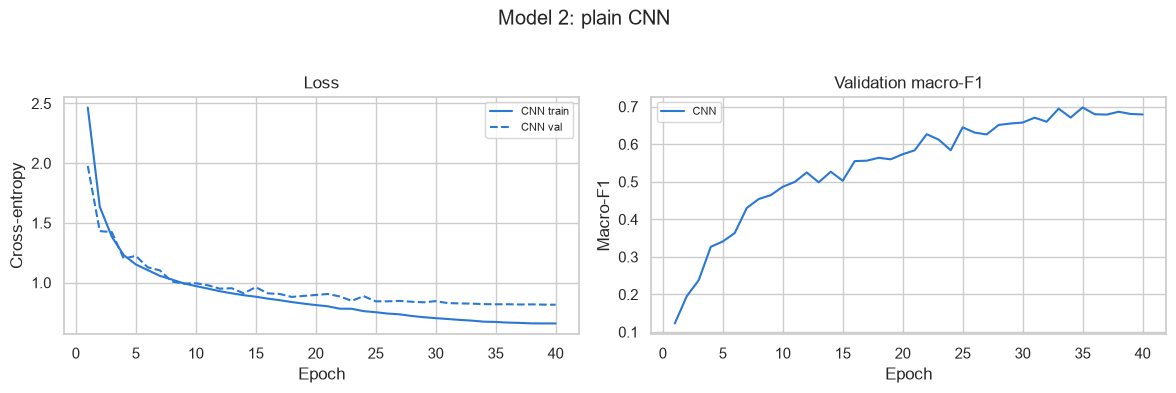

[memory after CNN] host RSS 2.46 GB | device allocated 0.58 GB reserved 1.38 GB


In [19]:
if wanted("cnn"):
    set_seed(RANDOM_STATE)
    cnn, cnn_history, cnn_logits = train_or_restore("cnn", PlainCNN, label="CNN")

    cnn_pred = cnn_logits.argmax(axis=1)
    record(evaluate_predictions(y_val, cnn_pred, cnn_logits, "2. CNN from scratch"))
    plot_history({"CNN": cnn_history}, "Model 2: plain CNN")
    report_memory("after CNN")
else:
    print("Skipped: 'cnn' is not this machine's job.")


## 6. Model 3: Small ResNet with Decoupled Classifier Retraining

The advanced model makes exactly two changes to model 2, each targeting a different weakness, and
Section 6.3 measures them separately so the report can attribute the gain rather than assert it.

**Change 1, the architecture.** Residual connections, four stages, and a stem adapted to this
input. The standard ImageNet stem is a 7x7 stride-2 convolution followed by a stride-2 max pool,
which reduces a 224-pixel input by a factor of four before the first residual block. Applied to an
80-pixel image that leaves 20x15 immediately and discards most of the spatial detail the task
depends on. This implementation uses the CIFAR-style stem instead: a single 3x3 stride-1
convolution, with all downsampling performed inside the stages.

**Change 2, the objective.** Kang et al. (ICLR 2020) report that on long-tailed data the feature
extractor learns best from the natural, instance-balanced distribution, while the classifier is
what needs rebalancing. That decomposition suggests training in two stages: fit the whole network
normally, then freeze the backbone, reinitialise the final linear layer, and retrain only that
layer under class-balanced sampling. It is a few hundred parameters' worth of retraining and it
typically moves macro-F1 more than any architectural change.

Section 6.3 also evaluates logit-adjusted cross-entropy (Menon et al., ICLR 2021), a one-line
alternative that adds `tau * log(prior)` to the logits during training, as a competing treatment
for the same problem.

In [20]:
class BasicBlock(nn.Module):
    """Standard two-convolution residual block with an optional projection shortcut."""

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x), inplace=True)


class SmallResNet(nn.Module):
    """ResNet-18 topology with a stride-1 3x3 stem, sized for 60x80 inputs.

    The backbone and the classifier are separate attributes so that Section 6.2 can freeze
    one and replace the other without touching the forward pass.
    """

    def __init__(self, n_classes=N_CLASSES, width=64, blocks=(2, 2, 2, 2), dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, width, 3, 1, 1, bias=False),
            nn.BatchNorm2d(width), nn.ReLU(inplace=True),
        )
        stages, in_channels = [], width
        for stage_index, n_blocks in enumerate(blocks):
            out_channels = width * (2 ** stage_index)
            for block_index in range(n_blocks):
                stride = 2 if (block_index == 0 and stage_index > 0) else 1
                stages.append(BasicBlock(in_channels, out_channels, stride))
                in_channels = out_channels
        self.stages = nn.Sequential(*stages)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.feature_dim = in_channels
        self.fc = nn.Linear(in_channels, n_classes)

    def embed(self, x):
        """Penultimate features. Used by the decoupled stage and by the saliency check."""
        return self.pool(self.stages(self.stem(x))).flatten(1)

    def forward(self, x):
        return self.fc(self.dropout(self.embed(x)))


set_seed(RANDOM_STATE)
resnet = SmallResNet()
print(f"SmallResNet parameters: {count_parameters(resnet):,}")
print("Output shape check:", tuple(resnet(torch.zeros(2, 3, IMAGE_TARGET_SIZE[1],
                                                      IMAGE_TARGET_SIZE[0])).shape))

SmallResNet parameters: 11,232,444
Output shape check: (2, 124)


### 6.1 Stage 1: Instance-Balanced Training

  [ResNet stage 1] epoch   1/40  train 2.129  val 1.998  acc 0.540  macro-F1 0.1374  121s  duty 65%
  [ResNet stage 1] epoch   2/40  train 1.481  val 1.411  acc 0.682  macro-F1 0.2508  59s  duty 65%
  [ResNet stage 1] epoch   3/40  train 1.294  val 1.311  acc 0.715  macro-F1 0.2994  74s  duty 65%
  [ResNet stage 1] epoch   4/40  train 1.164  val 1.176  acc 0.770  macro-F1 0.3530  84s  duty 65%
  [ResNet stage 1] epoch   5/40  train 1.087  val 1.148  acc 0.775  macro-F1 0.4005  72s  duty 65%
  [ResNet stage 1] epoch   6/40  train 1.029  val 1.055  acc 0.806  macro-F1 0.4272  82s  duty 65%
  [ResNet stage 1] epoch   7/40  train 0.990  val 1.032  acc 0.807  macro-F1 0.4695  69s  duty 65%
  [ResNet stage 1] epoch   8/40  train 0.956  val 0.955  acc 0.837  macro-F1 0.4755  76s  duty 65%
  [ResNet stage 1] epoch   9/40  train 0.923  val 1.012  acc 0.822  macro-F1 0.4922  66s  duty 65%
  [ResNet stage 1] epoch  10/40  train 0.897  val 0.973  acc 0.818  macro-F1 0.5169  92s  duty 65%
  [ResNet

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,3a. ResNet (plain CE),0.8960,0.7601,0.7417,0.8930,0.9884,0.9036,0.8552,0.7429,0.5952


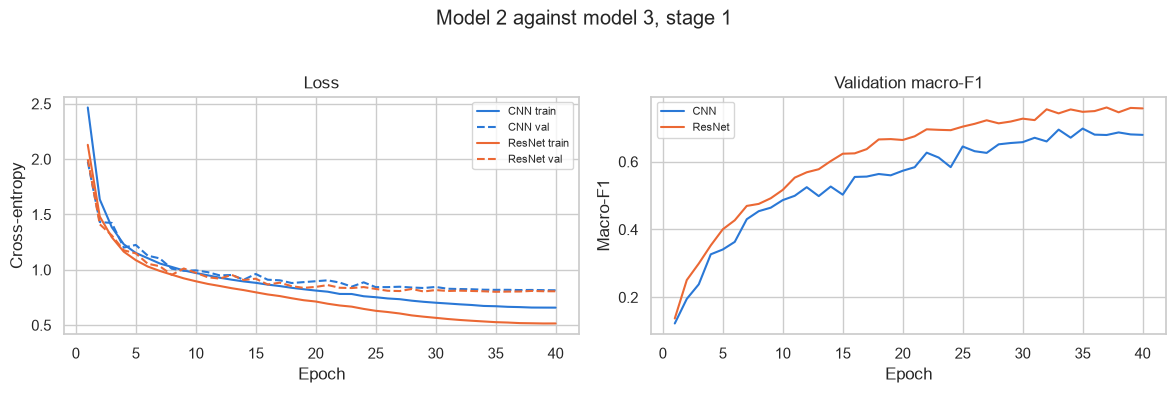

[memory after ResNet stage 1] host RSS 2.63 GB | device allocated 0.68 GB reserved 3.98 GB


In [21]:
if wanted("resnet"):
    set_seed(RANDOM_STATE)
    resnet, resnet_history, resnet_logits = train_or_restore(
        "resnet_stage1", SmallResNet, label="ResNet stage 1", compile_ok=False
    )

    resnet_pred = resnet_logits.argmax(axis=1)
    resnet_stage1 = record(evaluate_predictions(
        y_val, resnet_pred, resnet_logits, "3a. ResNet (plain CE)"
    ))
    plot_history({"CNN": globals().get("cnn_history"), "ResNet": resnet_history},
                 "Model 2 against model 3, stage 1")
    report_memory("after ResNet stage 1")
else:
    print("Skipped: 'resnet' is not this machine's job.")


### 6.2 Stage 2: Class-Balanced Classifier Retraining

The backbone is frozen and held in evaluation mode, so its batch-normalisation running statistics
do not drift under the resampled distribution; only the reinitialised final linear layer trains.
The sampler draws each class with probability proportional to `1 / support`, so a batch is
approximately class-balanced rather than image-balanced.

This is deliberately cheap. It touches roughly 0.4% of the network's parameters for a tenth of the
stage-1 epoch budget, which is the point: if it produces a material macro-F1 gain, that is direct
evidence for the claim that the classifier, not the representation, was the bottleneck.

In [ ]:
# --- Stage-2 machinery -------------------------------------------------------------
# Definitions only, and deliberately outside any job gate: `build_decoupled` and
# `run_stage_two` are read by the seed study and by Phase 2 as well as by this section,
# so a machine assigned only one of those still needs them defined.
# Inverse-support weights, one per training row. Classes with a single example are drawn as
# often as Tshirts, which is the intended behaviour of a class-balanced sampler.
class_weights = 1.0 / np.maximum(np.bincount(y_train, minlength=N_CLASSES), 1)
sample_weights = class_weights[y_train]
balanced_loader, _ = make_loaders(weights=sample_weights)


def build_decoupled(source_model):
    """A frozen copy of a stage-1 backbone carrying a freshly initialised classifier.

    Freeze everything, then replace the head. eval() on the whole model keeps BatchNorm in
    inference mode, so the running statistics do not drift under the resampled distribution.
    The new linear layer carries no BatchNorm of its own, so nothing is lost by that.
    """
    model = prepare_model(SmallResNet(), compile_ok=False)
    load_model_state(model, model_state(source_model))
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.fc = nn.Linear(model.feature_dim, N_CLASSES).to(DEVICE)
    model.eval()
    return model


def run_stage_two(model, loader, epochs=STAGE2_EPOCHS, lr=STAGE2_LR, run_name=None):
    """Retrain the classifier only, under class-balanced sampling.

    The backbone runs under no_grad, so this pass costs a forward only. It is the cheapest
    thing in the notebook and usually the largest single macro-F1 gain.

    Two details differ from a naive implementation. The head is trained through the same
    dropout the forward pass applies, because `model(x)` at inference is `fc(dropout(embed(x)))`
    and training `fc` on undropped features would be training a different function from the one
    that is evaluated. And the stage checkpoints its own state each epoch, so an interruption
    here costs at most one epoch rather than the whole stage.
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimiser = torch.optim.AdamW(model.fc.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    scaler = make_scaler()
    best = {"macro_f1": -1.0, "epoch": -1, "state": None, "logits": None}
    first_epoch = 0

    resume_path = checkpoint_path(run_name or "stage2", "epoch")
    if RESUME and run_name and resume_path.exists():
        blob = torch_load(resume_path)
        if blob.get("fingerprint") == RUN_FINGERPRINT:
            load_model_state(model, blob["model"])
            optimiser.load_state_dict(blob["optimiser"])
            scheduler.load_state_dict(blob["scheduler"])
            restore_rng_state(blob["rng"])
            best, first_epoch = blob["best"], blob["epoch"]
            print(f"  [stage 2] resumed at epoch {first_epoch + 1}/{epochs}")

    for epoch in range(first_epoch, epochs):
        start = time.time()
        model.eval()                      # backbone stays in inference mode throughout
        model.fc.train()
        if STAGE2_USE_DROPOUT:
            model.dropout.train()
        throttle = make_throttle()
        for images, labels in loader:
            with throttle:
                with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE,
                                    enabled=AMP_ENABLED):
                    with torch.no_grad():
                        features = model.embed(images)
                    features = features.float()
                    if STAGE2_USE_DROPOUT:
                        features = model.dropout(features)
                    loss = criterion(model.fc(features), labels)
                optimiser.zero_grad(set_to_none=True)
                if scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.step(optimiser)
                    scaler.update()
                else:
                    loss.backward()
                    optimiser.step()
        scheduler.step()

        _, logits = run_epoch(model, val_loader, criterion, None, None, None)
        macro = f1_score(y_val, logits.argmax(axis=1), labels=SCOREABLE,
                         average="macro", zero_division=0)
        print(f"  [stage 2] epoch {epoch + 1}/{epochs}  macro-F1 {macro:.4f}  "
              f"{time.time() - start:.0f}s"
              + (f"  duty {throttle.measured_duty:.0%}" if throttle.enabled else ""))
        if macro > best["macro_f1"]:
            best.update({"macro_f1": macro, "epoch": epoch + 1,
                         "state": model_state(model), "logits": logits})

        if run_name:
            atomic_save({
                "fingerprint": RUN_FINGERPRINT, "epoch": epoch + 1,
                "model": model_state(model), "optimiser": optimiser.state_dict(),
                "scheduler": scheduler.state_dict(), "rng": capture_rng_state(), "best": best,
            }, resume_path)

    load_model_state(model, best["state"])
    if run_name and resume_path.exists() and not KEEP_EPOCH_CHECKPOINTS:
        resume_path.unlink()
    return best["logits"], best["macro_f1"]


In [ ]:
if wanted("resnet"):
    # Seeded before the head is built so the fresh classifier's initialisation is reproducible
    # rather than inherited from wherever the previous cell left the generator.
    set_seed(RANDOM_STATE)
    decoupled = build_decoupled(resnet)

    trainable = count_parameters(decoupled)
    print(f"Trainable parameters in stage 2: {trainable:,} "
          f"({trainable / sum(p.numel() for p in decoupled.parameters()) * 100:.2f}% of the model)")

    cached = restore("resnet_decoupled", decoupled)
    if cached is None:
        set_seed(RANDOM_STATE)
        decoupled_logits, _ = run_stage_two(decoupled, balanced_loader, run_name="resnet_decoupled")
        bank("resnet_decoupled", decoupled, decoupled_logits)
    else:
        decoupled_logits = cached["val_logits"]

    decoupled_pred = decoupled_logits.argmax(axis=1)
    record(evaluate_predictions(
        y_val, decoupled_pred, decoupled_logits, "3. ResNet + decoupled classifier"
    ))
else:
    print("Skipped: 'resnet' is not this machine's job.")


### 6.3 Ablation: Which Change Paid?

Three treatments of the same imbalance, on the same architecture, the same split and the same
budget. This is an ablation table, not three more submissions: the point is to attribute the
macro-F1 gain, and to expose the trade-off it costs.

| Row | Treatment |
|---|---|
| Plain CE | Stage 1 alone. The reference. |
| Logit-adjusted CE | `tau * log(prior)` added to the logits during training only; evaluation uses the raw logits. One line, no extra training stage. |
| Decoupled classifier | Stage 1 followed by class-balanced retraining of the final layer. |

Expect the two rebalanced rows to raise macro-F1 and to *lower* top-1 accuracy: shifting decision
boundaries toward rare classes necessarily costs some head-class precision. That trade-off, and
the decision about which side of it to land on, is the substance of the ultimate judgement in
Section 8.

In [23]:
if wanted("logit_adjusted"):
    # Logit-adjusted cross-entropy. The bias is added inside the loss during training and never
    # at evaluation, so the deployed model is an ordinary softmax classifier.
    log_prior = torch.log(
        torch.tensor(np.bincount(y_train, minlength=N_CLASSES) / len(y_train), dtype=torch.float32)
    ).to(DEVICE)

    set_seed(RANDOM_STATE)
    adjusted, adjusted_history, adjusted_logits = train_or_restore(
        "resnet_logit_adjusted", SmallResNet, label="ResNet logit-adjusted",
        logit_bias=LOGIT_ADJUST_TAU * log_prior,
    )

    adjusted_pred = adjusted_logits.argmax(axis=1)
    record(evaluate_predictions(
        y_val, adjusted_pred, adjusted_logits, f"3b. ResNet (logit-adjusted, tau={LOGIT_ADJUST_TAU})"
    ))

    # This row is an ablation, not a candidate. Its weights are banked, so nothing below needs it
    # resident and the VRAM is better spent on the seed study.
    release("adjusted")
    report_memory("after the ablation")
else:
    print("Skipped: 'logit_adjusted' is not this machine's job.")


  [ResNet logit-adjusted] epoch   1/40  train 2.079  val 3.354  acc 0.407  macro-F1 0.1718  97s  duty 65%
  [ResNet logit-adjusted] epoch   2/40  train 1.470  val 3.175  acc 0.413  macro-F1 0.2489  77s  duty 65%
  [ResNet logit-adjusted] epoch   3/40  train 1.297  val 2.904  acc 0.448  macro-F1 0.3338  99s  duty 65%
  [ResNet logit-adjusted] epoch   4/40  train 1.161  val 2.944  acc 0.418  macro-F1 0.3846  96s  duty 65%
  [ResNet logit-adjusted] epoch   5/40  train 1.081  val 3.094  acc 0.384  macro-F1 0.3921  89s  duty 65%
  [ResNet logit-adjusted] epoch   6/40  train 1.028  val 3.032  acc 0.390  macro-F1 0.4432  95s  duty 65%
  [ResNet logit-adjusted] epoch   7/40  train 0.985  val 3.109  acc 0.341  macro-F1 0.3985  84s  duty 65%
  [ResNet logit-adjusted] epoch   8/40  train 0.953  val 2.958  acc 0.375  macro-F1 0.4805  55s  duty 65%
  [ResNet logit-adjusted] epoch   9/40  train 0.921  val 2.788  acc 0.511  macro-F1 0.4948  78s  duty 65%
  [ResNet logit-adjusted] epoch  10/40  train 

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,"3b. ResNet (logit-adjusted, tau=1.0)",0.5646,0.6882,0.7470,0.6387,0.6775,0.6229,0.8170,0.7399,0.3924


[memory after the ablation] host RSS 2.62 GB | device allocated 0.72 GB reserved 1.07 GB


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,3a. ResNet (plain CE),0.8960,0.7601,0.7417,0.8930,0.9884,0.9036,0.8552,0.7429,0.5952
1,3. ResNet + decoupled classifier,0.8906,0.7603,0.7694,0.8915,0.9835,0.9008,0.8534,0.7313,0.6270
2,"3b. ResNet (logit-adjusted, tau=1.0)",0.5646,0.6882,0.7470,0.6387,0.6775,0.6229,0.8170,0.7399,0.3924


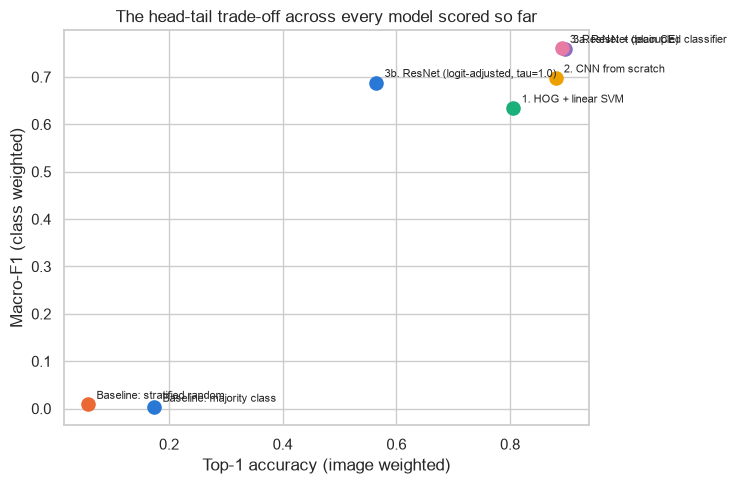

In [24]:
if COMBINE:
    ablation = pd.concat([r for r in RESULTS if r["Model"].iloc[0].startswith("3")], ignore_index=True)
    display(ablation.style.format({c: "{:.4f}" for c in ablation.columns if c != "Model"}))

    # The trade-off, drawn rather than described: accuracy against macro-F1 for every model so far.
    comparison = pd.concat(RESULTS, ignore_index=True)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for (_, row), colour in zip(comparison.iterrows(), PALETTE * 3):
        ax.scatter(row["Top-1 accuracy"], row["Macro-F1"], s=90, color=colour, zorder=3)
        ax.annotate(row["Model"], (row["Top-1 accuracy"], row["Macro-F1"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=8)
    ax.set(xlabel="Top-1 accuracy (image weighted)", ylabel="Macro-F1 (class weighted)",
           title="The head-tail trade-off across every model scored so far")
    plt.tight_layout(); save_figure("03_head_tail_tradeoff"); plt.show()
else:
    print('Skipped in worker mode: this runs on the combine machine.')


## 7. Seed Variance

With classes held by two or three groups, one validation example can move a per-class F1 from 0 to
1, and 124 such classes enter the macro average. A difference of a point or two between two models
may therefore be a difference in the random draw rather than in the models.

The two finalists are run under three seeds and reported as mean +/- standard deviation.
The seed governs weight initialisation, augmentation draws and sampler draws; **the split is held
fixed** so the comparison is on identical validation rows.

Two of those six runs are not retrained. Seed 42 is `RANDOM_STATE`, so the seed 42 CNN is the run
already fitted in Section 5 and the seed 42 ResNet is the one already fitted in Sections 6.1 and
6.2: same architecture, same seed, same split, same loaders. Refitting them would consume a third
of this section's budget to reproduce two numbers that are already in the comparison table, so
their logits are reused and the remaining four runs are trained. Every run, reused or not, is
scored by the same function on the same validation rows. That measures optimisation variance,
which is the variance a model choice is exposed to; split variance would require repeated
resplitting and is noted as a limitation in Section 10 rather than estimated here.

In [25]:
ACTIVE_SEEDS = wanted_seeds(SEEDS)

if ACTIVE_SEEDS:
    # The seed 42 runs are already trained. `run_finalist` would rebuild the same architecture from
    # the same seed against the same fixed split and the same loaders, so it would reproduce these
    # logits exactly; reusing them removes two of six full trainings from the most expensive section
    # of the notebook without changing a single reported number.
    # In worker mode this machine may never have run Sections 5 and 6, so the logits are
    # looked for on disk as well as in memory. Without that, a seed job would retrain the
    # seed 42 models under their own keys and the combine machine would then ignore the
    # result, because it reuses the Section 6 logits for that row.
    def _seed42_logits(name, key):
        logits = globals().get(name)
        if logits is None:
            cached = restore(key)
            logits = None if cached is None else cached["val_logits"]
        return logits

    PRECOMPUTED = {name: logits for name, logits in
                   (("CNN", _seed42_logits("cnn_logits", "cnn")),
                    ("ResNet + decoupled",
                     _seed42_logits("decoupled_logits", "resnet_decoupled")))
                   if logits is not None}


    def run_finalist(name, seed):
        """One full training run of a finalist under a given seed. Returns a scored row.

        Every stage is banked under its own key, so an interrupted seed study resumes at the run
        it was on rather than restarting the section. Those same checkpoints are what make the
        ensembling suggested in Section 10.4 possible; the original notebook discarded them.

        The stream tensors are shared, so a seed run allocates a model and nothing else.
        """
        key = f"seed_{slug(name)}_{seed}"

        if seed == RANDOM_STATE and name in PRECOMPUTED:
            print(f"  reusing the seed {seed} run already trained and scored above")
            logits = PRECOMPUTED[name]
        elif name == "CNN":
            set_seed(seed)
            loader, _ = make_loaders()
            model = prepare_model(PlainCNN())
            cached = restore(key, model)
            if cached is None:
                _, logits, _ = fit(model, loader, val_loader, label=f"CNN s{seed}",
                                   run_name=key, verbose_every=10)
                bank(key, model, logits)
            else:
                logits = cached["val_logits"]
            del model
        else:
            backbone_key = f"{key}_backbone"
            set_seed(seed)
            loader, _ = make_loaders()
            backbone = prepare_model(SmallResNet(), compile_ok=False)
            cached = restore(backbone_key, backbone)
            if cached is None:
                _, backbone_logits, _ = fit(backbone, loader, val_loader, label=f"ResNet s{seed}",
                                            run_name=backbone_key, verbose_every=10)
                bank(backbone_key, backbone, backbone_logits)

            set_seed(seed)
            head = build_decoupled(backbone)
            cached = restore(key, head)
            if cached is None:
                balanced, _ = make_loaders(weights=sample_weights)
                logits, _ = run_stage_two(head, balanced, run_name=key)
                bank(key, head, logits)
            else:
                logits = cached["val_logits"]
            del backbone, head

        scored = evaluate_predictions(y_val, logits.argmax(axis=1), logits, name)
        scored["seed"] = seed

        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        return scored


    SEED_RESULTS_PATH = ARTEFACT_DIR / "task1_seed_study.csv"

    if RUN_SEED_STUDY:
        seed_rows = []
        for name in ["CNN", "ResNet + decoupled"]:
            for seed in ACTIVE_SEEDS:
                print(f"--- {name}, seed {seed} ---")
                seed_rows.append(run_finalist(name, seed))
                # Written after every run, so an interruption keeps the runs already paid for.
                pd.concat(seed_rows, ignore_index=True).to_csv(SEED_RESULTS_PATH, index=False)
        seed_results = pd.concat(seed_rows, ignore_index=True)

        variance = seed_results.groupby("Model")[["Top-1 accuracy", "Macro-F1", "Balanced accuracy"]]
        summary = variance.agg(["mean", "std"]).round(4)
        display(summary)
        print(f"\nSaved to {SEED_RESULTS_PATH.name}. Read the standard deviation before claiming a "
              "winner: if the gap between the two means is inside one combined standard deviation, "
              "the models are not distinguishable on this evidence.")
    else:
        seed_results = pd.read_csv(SEED_RESULTS_PATH) if SEED_RESULTS_PATH.exists() else None
        if seed_results is not None:
            print("RUN_SEED_STUDY is False; reusing the seed study saved by an earlier run.")
            display(seed_results.groupby("Model")[["Top-1 accuracy", "Macro-F1",
                                                   "Balanced accuracy"]].agg(["mean", "std"]).round(4))
        else:
            print("RUN_SEED_STUDY is False and no earlier seed study is on disk. The comparison "
                  "rests on a single seed and the report must say so.")
else:
    print('Skipped: no seed of the seed study is this machine\'s job.')


--- CNN, seed 42 ---
  reusing the seed 42 run already trained and scored above
--- CNN, seed 1337 ---
  [CNN s1337] epoch   1/40  train 2.420  val 2.044  acc 0.589  macro-F1 0.1261  6s  duty 65%
  [CNN s1337] epoch  10/40  train 0.967  val 0.980  acc 0.827  macro-F1 0.4677  6s  duty 65%
  [CNN s1337] epoch  20/40  train 0.813  val 0.873  acc 0.859  macro-F1 0.5746  5s  duty 65%
  [CNN s1337] epoch  30/40  train 0.705  val 0.825  acc 0.876  macro-F1 0.6741  5s  duty 65%
  [CNN s1337] epoch  40/40  train 0.662  val 0.817  acc 0.880  macro-F1 0.6919  6s  duty 65%
  [CNN s1337] best macro-F1 0.7040 at epoch 34 (226s this session, 6s per epoch)
  banked -> model_seed_cnn_1337.pt (10.2 MB)
--- CNN, seed 2024 ---
  [CNN s2024] epoch   1/40  train 2.427  val 2.032  acc 0.538  macro-F1 0.1030  6s  duty 65%
  [CNN s2024] epoch  10/40  train 0.970  val 1.004  acc 0.818  macro-F1 0.4525  6s  duty 65%
  [CNN s2024] epoch  20/40  train 0.809  val 0.891  acc 0.855  macro-F1 0.5817  6s  duty 65%
  [C

Top-1 accuracy         Macro-F1         Balanced accuracy        
                             mean     std     mean     std              mean     std
Model                                                                               
CNN                        0.8803  0.0023   0.6979  0.0061            0.6798  0.0071
ResNet + decoupled         0.8890  0.0015   0.7752  0.0131            0.7835  0.0133


Saved to task1_seed_study.csv. Read the standard deviation before claiming a winner: if the gap between the two means is inside one combined standard deviation, the models are not distinguishable on this evidence.


## 7.5 Phase 1: Post-hoc Gains From Models That Already Exist

Sections 5 to 7 produced six trained networks and then used four of them for nothing but a
variance estimate. This section spends no training time at all: it combines checkpoints that are
already on disk, and it applies one correction whose parameter is fitted on validation
predictions rather than on images.

Three changes, each with a separate justification and each measured separately below.

| Change | Why it should help here |
|---|---|
| **Flip-averaged inference (TTA)** | Section 2.4 already asserts that catalogue images carry no meaningful left-right orientation, and trains under a p=0.5 horizontal flip. If that assumption holds, the image and its mirror are two views of the same product and averaging their predictions reduces variance for free. If it does not hold, this row will show no gain, which would itself falsify an assumption the augmentation policy depends on. |
| **Seed ensembling** | The seed study measured a macro-F1 spread of 0.0116 across three runs of the same architecture. That spread is evidence the three runs make partly independent errors, which is exactly the condition under which averaging their predictions beats any single one of them. |
| **Post-hoc logit adjustment** | Section 6.3 applied `tau * log(prior)` inside the training objective at `tau = 1.0` and top-1 accuracy collapsed from 0.896 to 0.549. Menon et al. (2021) give the post-hoc form as the alternative: subtract `tau * log(prior)` from the logits at inference, with `tau` chosen on held-out data. The training run committed to `tau = 1.0` before seeing any result; here `tau` is a decision made against evidence, and `tau = 0` is inside the search space, so the procedure can decline to adjust at all. |

**On honest measurement of a tuned parameter.** `tau` is chosen to maximise validation macro-F1,
so scoring the chosen `tau` on the same rows that chose it is optimistic by construction. The
validation set is therefore split in two: `tau` is fitted on fold A and used to predict fold B,
then fitted on B and used to predict A. Every validation row ends up predicted by a `tau` that
never saw it, and the macro-F1 over that combined out-of-fold prediction is the number reported.
The optimistic in-sample figure is printed beside it so the size of the selection bias is visible
rather than assumed small.

In [26]:
# --- Phase 1 configuration --------------------------------------------------------
RUN_PHASE1 = True
PHASE1_TTA = True          # average each prediction with its horizontal mirror
TAU_GRID = np.round(np.arange(0.0, 1.001, 0.05), 3)   # tau = 0 means "do not adjust"

# The three banked runs of the finalist architecture. The keys are the ones Sections 6.2
# and 7 wrote, so this list is a description of what is on disk rather than a new decision.
PHASE1_MEMBERS = [
    ("resnet_decoupled", 42),
    ("seed_resnet___decoupled_1337", 1337),
    ("seed_resnet___decoupled_2024", 2024),
]

# The training prior, in logs. Fitted on training rows only, like every other constant here.
LOG_PRIOR = np.log(np.bincount(y_train, minlength=N_CLASSES) / len(y_train) + 1e-12)


def stream_probabilities(model, stream, tta=None):
    """Softmax probabilities for every row of a stream, in the stream's own order.

    Probabilities rather than logits, because averaging across models is only well defined
    on a common scale: two networks' logits differ by an arbitrary additive constant per row,
    while their probabilities are directly comparable.

    Args:
        tta: average with the horizontally flipped input. Defaults to PHASE1_TTA.
    """
    tta = PHASE1_TTA if tta is None else tta
    model.eval()
    chunks = []
    with torch.no_grad():
        for images, _ in stream:
            with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=AMP_ENABLED):
                probabilities = model(images).float().softmax(dim=1)
                if tta:
                    mirrored = images.flip(-1)
                    if CHANNELS_LAST:
                        mirrored = mirrored.contiguous(memory_format=torch.channels_last)
                    probabilities = (probabilities + model(mirrored).float().softmax(dim=1)) / 2
            chunks.append(probabilities.float().cpu())
    return torch.cat(chunks).numpy()


def load_banked(key, factory=None):
    """Rebuild a banked model from its checkpoint, or return None if it is not usable.

    The fingerprint check is the same safety property `restore` enforces: a checkpoint written
    under a different split or recipe is not a shortcut, so it is refused rather than averaged
    into an ensemble where the mismatch would be invisible.
    """
    factory = factory or SmallResNet
    path = checkpoint_path(key, "model")
    if not path.exists():
        print(f"  '{key}': no checkpoint on disk, skipped")
        return None
    blob = torch_load(path)
    if blob.get("fingerprint") != RUN_FINGERPRINT:
        print(f"  '{key}': fingerprint mismatch, refused")
        return None
    model = prepare_model(factory(), compile_ok=False)
    load_model_state(model, blob["state_dict"])
    return model


def predict_probabilities(stream, members, tta=None):
    """Mean softmax over a list of (checkpoint key, factory) members.

    Members are loaded and released one at a time, so an ensemble of any size costs the VRAM
    of a single model. This is the function Section 9 reuses at test time, which is what makes
    the deployed pipeline literally the same code path as the one scored here.
    """
    total, n_used = None, 0
    for key, factory in members:
        model = load_banked(key, factory)
        if model is None:
            continue
        probabilities = stream_probabilities(model, stream, tta=tta)
        total = probabilities if total is None else total + probabilities
        n_used += 1
        del model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    if not n_used:
        raise RuntimeError("No usable ensemble member was found on disk.")
    # Published rather than returned, so the three call sites below keep their shape. A
    # missing member is survivable, but reporting the score under the configured member
    # count would put a single model in the table under an ensemble's name.
    global ENSEMBLE_MEMBERS_USED
    ENSEMBLE_MEMBERS_USED = n_used
    if n_used < len(members):
        print(f"  WARNING: {len(members) - n_used} of {len(members)} members were not "
              f"usable. Every row below is an ensemble of {n_used}, not {len(members)}.")
    return total / n_used


def macro_f1_on(rows, y_pred):
    """Macro-F1 over a subset of validation rows, using the notebook's SCOREABLE label set."""
    return f1_score(y_val[rows], y_pred[rows], labels=SCOREABLE, average="macro",
                    zero_division=0)


def adjusted_prediction(probabilities, tau):
    """argmax of log p - tau * log prior. tau = 0 recovers the unadjusted prediction."""
    return (np.log(probabilities + 1e-12) - tau * LOG_PRIOR).argmax(axis=1)


def best_tau(probabilities, rows):
    """The tau on TAU_GRID that maximises macro-F1 over the given rows."""
    return max(TAU_GRID, key=lambda t: macro_f1_on(rows, adjusted_prediction(probabilities, t)))


print(f"RUN_PHASE1: {RUN_PHASE1} | TTA: {PHASE1_TTA} | "
      f"tau grid: {TAU_GRID[0]:.2f} to {TAU_GRID[-1]:.2f} in {len(TAU_GRID)} steps")

RUN_PHASE1: True | TTA: True | tau grid: 0.00 to 1.00 in 21 steps


In [27]:
if COMBINE:
    if RUN_PHASE1:
        # --- The three changes, applied one at a time so each is attributable ------------
        print("Scoring ensemble members (one forward pass each, no training):")

        single_plain = predict_probabilities(val_loader, [(PHASE1_MEMBERS[0][0], SmallResNet)],
                                             tta=False)
        single_tta = predict_probabilities(val_loader, [(PHASE1_MEMBERS[0][0], SmallResNet)],
                                           tta=True)
        ensemble_probabilities = predict_probabilities(
            val_loader, [(key, SmallResNet) for key, _ in PHASE1_MEMBERS], tta=PHASE1_TTA
        )
        # Captured here rather than read later: the two single-model calls above set the
        # same global, and any call added below would too.
        PHASE1_N_MEMBERS = ENSEMBLE_MEMBERS_USED

        # --- Out-of-fold tau, so the reported number is not the number that chose tau -----
        fold = np.random.RandomState(RANDOM_STATE).permutation(len(y_val)) % 2
        fold_a, fold_b = np.flatnonzero(fold == 0), np.flatnonzero(fold == 1)

        tau_from_a, tau_from_b = best_tau(ensemble_probabilities, fold_a), \
                                 best_tau(ensemble_probabilities, fold_b)

        # Each fold is predicted with the tau fitted on the other one. Assembling both halves
        # into a single array lets the honest score be computed by the same scorer as every
        # other row in the table, over exactly the same rows.
        out_of_fold = np.empty(len(y_val), dtype=np.int64)
        out_of_fold[fold_a] = adjusted_prediction(ensemble_probabilities, tau_from_b)[fold_a]
        out_of_fold[fold_b] = adjusted_prediction(ensemble_probabilities, tau_from_a)[fold_b]

        # The tau that would be deployed: fitted on all of validation, which is the most data
        # available for the choice. It is reported, not used for the headline score.
        PHASE1_TAU = float(best_tau(ensemble_probabilities, np.arange(len(y_val))))
        in_sample = adjusted_prediction(ensemble_probabilities, PHASE1_TAU)

        # Adjusted scores, so that top-5 accuracy ranks candidates the way the deployed system
        # does. Scoring an adjusted prediction against an unadjusted ranking would report a
        # top-5 figure for a model that is not the one making the top-1 decision.
        PHASE1_LOGITS = np.log(ensemble_probabilities + 1e-12) - PHASE1_TAU * LOG_PRIOR

        # --- The ladder ------------------------------------------------------------------
        ladder = pd.concat([
            evaluate_predictions(y_val, single_plain.argmax(axis=1), single_plain,
                                 "P1.0 single model (seed 42), no TTA"),
            evaluate_predictions(y_val, single_tta.argmax(axis=1), single_tta,
                                 "P1.1 + flip TTA"),
            evaluate_predictions(y_val, ensemble_probabilities.argmax(axis=1),
                                 ensemble_probabilities, "P1.2 + 3-seed ensemble"),
            evaluate_predictions(y_val, out_of_fold, PHASE1_LOGITS,
                                 "P1.3 + logit adjustment (out-of-fold tau)"),
        ], ignore_index=True)
        display(ladder.style.format({c: "{:.4f}" for c in ladder.columns if c != "Model"}))

        honest = ladder.loc[3, "Macro-F1"]
        optimistic = f1_score(y_val, in_sample, labels=SCOREABLE, average="macro", zero_division=0)
        print(f"\ntau fitted on fold A: {tau_from_a:.2f} | on fold B: {tau_from_b:.2f} | "
              f"on all validation rows: {PHASE1_TAU:.2f}")
        print(f"Macro-F1 with out-of-fold tau: {honest:.4f}  <- reported")
        print(f"Macro-F1 with in-sample tau:   {optimistic:.4f}  "
              f"(selection bias: {optimistic - honest:+.4f})")
        if abs(tau_from_a - tau_from_b) > 0.2:
            print("The two folds disagree substantially about tau; treat the adjustment as "
                  "unstable and prefer the unadjusted row.")

        # Two rows, because these are two different predictions and putting them under one
        # name would place two macro-F1 values on the same label. PHASE1_NAME describes the
        # configuration that is actually deployed: tau enters the name only when the search
        # chose a non-zero value, and on both runs so far it chose 0.00. The out-of-fold row
        # stays in the table as the evidence for declining the adjustment, not as a candidate.
        PHASE1_NAME = f"4. Ensemble x{PHASE1_N_MEMBERS} + TTA"
        if PHASE1_TAU > 0:
            PHASE1_NAME += f" + logit adjustment (tau {PHASE1_TAU:.2f})"
        deployed_pred = adjusted_prediction(ensemble_probabilities, PHASE1_TAU)
        record(evaluate_predictions(y_val, deployed_pred, PHASE1_LOGITS, PHASE1_NAME))
        record(evaluate_predictions(
            y_val, out_of_fold, PHASE1_LOGITS,
            "4b. + logit adjustment, out-of-fold tau (measured, not deployed)"
        ))

        # Carried to Section 8. Scores rather than probabilities, so `final_logits` behaves like
        # every other model's logits: softmax of this is a proper distribution, and argmax of it
        # reproduces `out_of_fold` up to the fold-vs-deployment tau distinction noted above.
        PHASE1_PROBABILITIES = ensemble_probabilities
        PHASE1_MEMBER_SPEC = [(key, SmallResNet) for key, _ in PHASE1_MEMBERS]

        report_memory("after Phase 1")
    else:
        print("RUN_PHASE1 is False; Section 8 will choose among the Section 6 models only.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


Scoring ensemble members (one forward pass each, no training):


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,"P1.0 single model (seed 42), no TTA",0.8906,0.7603,0.7694,0.8915,0.9835,0.9008,0.8534,0.7313,0.6270
1,P1.1 + flip TTA,0.8873,0.7518,0.7622,0.8881,0.9845,0.8980,0.8488,0.7223,0.6111
2,P1.2 + 3-seed ensemble,0.8948,0.7930,0.7939,0.8950,0.9881,0.9030,0.8588,0.7777,0.6825
3,P1.3 + logit adjustment (out-of-fold tau),0.8935,0.7869,0.7940,0.8945,0.9881,0.9030,0.8569,0.7720,0.6667



tau fitted on fold A: 0.00 | on fold B: 0.10 | on all validation rows: 0.00
Macro-F1 with out-of-fold tau: 0.7869  <- reported
Macro-F1 with in-sample tau:   0.7930  (selection bias: +0.0061)


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,4. Ensemble x3 + TTA,0.8948,0.7930,0.7939,0.8950,0.9881,0.9030,0.8588,0.7777,0.6825


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,"4b. + logit adjustment, out-of-fold tau (measured, not deployed)",0.8935,0.7869,0.7940,0.8945,0.9881,0.9030,0.8569,0.7720,0.6667


[memory after Phase 1] host RSS 2.59 GB | device allocated 0.72 GB reserved 1.07 GB


#### Reading the Ladder

Each row adds exactly one change to the row above it, so the differences are attributable rather
than merely observed. Three things to check before quoting any of it in the report.

- **Row P1.0 should reproduce the Section 6.2 result.** It is the same checkpoint scored by the
  same function on the same rows, so a discrepancy larger than floating-point noise means a
  checkpoint has been overwritten and the rest of this section is not trustworthy.
- **The TTA row tests an assumption, not just a number.** No gain means catalogue images are less
  left-right symmetric than Section 2.4 assumed, which would be an argument for removing the flip
  from the augmentation policy rather than for adding it at inference.
- **The gap between the out-of-fold and in-sample macro-F1 is the cost of tuning `tau`.** If it is
  a fraction of a point, the tuned adjustment generalises. If it is large, `tau` is fitting the
  particular validation draw and the unadjusted row is the honest recommendation.

None of this costs a training run, which also makes it the cheapest evidence in the notebook for
a claim the report has to make anyway: that the improvement is a property of the method rather
than of one lucky initialisation.

## 7.6 Phase 2: Testing the Localised-Evidence Hypothesis

Phase 1 recombined existing models and changed what this section should ask. Two of its results
matter here.

- The prior-correction family is closed. Post-hoc `tau` was unstable across folds (0.00 against
  0.40, selection bias +0.0294) and in-training `tau = 1.0` collapsed top-1 accuracy to 0.549.
  Both endpoints of that family are now measured and both fail, which is what makes the softened
  interpolation below a decision against evidence rather than another guess.
- The remaining errors are overwhelmingly *within family*: 73.3% of them, and the largest
  confusions are `Flats` to `Heels` at 36.9%, `Sports Sandals` to `Sandals` at 30.8%, `Duffel Bag`
  to `Handbags` at 23.5% and `Tops` to `Tshirts` at 18.8%. Every one of those is a fine-grained
  distinction carried by a small region of the frame. Auxiliary supervision on `subCategory`
  teaches the model to get the family right, and it already does, so hierarchical supervision is
  no longer the most promising change available. The pooling resolution is.

Phase 2 therefore runs as two configurations, selected by `P2_VARIANT` in the cell below.

**Run A, the hypothesis test.** `P2_FINER_MAP = True` and nothing else changed: aux weight 0,
sampler power 1.0, stage 2 of 10 epochs, which is the Section 6 recipe exactly. Stage 3 keeps
stride 1 so the final feature map is 20x15 rather than 10x8, leaving the input untouched. Any
difference is attributable to the pooling resolution and to nothing else. Both outcomes are
publishable: a gain says the global average pool was destroying localised evidence, and no gain
says the 60x80 image does not carry the distinction, which turns Section 8.1's confusions into a
property of the data supported by an experiment rather than an assertion.

**Run B, the candidate.** Aux weight 0.3, sampler power 0.5, stage 2 of 30 epochs, on top of
whichever map resolution Run A vindicates. This is the configuration that competes for the
finalist slot. It is run second because a number from it cannot be explained without Run A.

### The comparison bar, fixed before the run

Phase 2 produces one model. Phase 1's best is three models under flip TTA. Those are not
comparable, and deciding what counts as a win after seeing the number is the failure mode this
block exists to prevent.

1. **Primary readout is not macro-F1.** `Flats` and `Heels` hold roughly 293 validation images
   between them out of 7,566. Eliminating that confusion outright would move macro-F1 by about
   half a point, which is inside the 0.0116 seed standard deviation. The hypothesis is about
   localised evidence, so the confusion rates on the localised-detail pairs test it and macro-F1
   is only the check that nothing else broke.
2. **Single against single.** Phase 2 stage 2 is compared to the seed **mean** of the Section 6
   finalist, 0.7767 with standard deviation 0.0116, not to seed 42's individual 0.7673. Seed 42
   drew below its own mean, and scoring a new model against a weak draw would manufacture a gain.
3. **Matched inference budget.** Phase 2 plus flip TTA is two forward passes per image, so its
   comparison row is P1.1 at 0.7741, not the six-pass ensemble at 0.7947.
4. **Ensemble against ensemble, or not at all.** Phase 2 may only be compared to P1.2 after three
   Phase 2 seeds have been trained and ensembled. Until that exists, the report states the
   single-model comparison and says why.

A result inside one standard deviation of its own comparison row is a draw and is reported as one.

### Run A result: the hypothesis is rejected

Recorded here so the config below is read against it. Run A trained to completion at 52 seconds
per epoch and lost on every one of its own criteria.

| Comparison | Run A | Reference | Delta |
|---|---|---|---|
| Stage 1, plain CE | 0.7349 | 0.7633 (row 3a) | -0.0284 |
| Stage 2, decoupled | 0.7594 | 0.7767, the seed mean | -0.0173, 1.5 std |
| Matched budget, plus flip TTA | 0.7636 | 0.7732 (P1.1) | -0.0096, a draw |

The pair table in Section 7.7 is the substantive result. `Flats` to `Heels` rose from 27.4% to
35.7%, `Duffel Bag` to `Handbags` from 23.5% to 35.3%, and `Tunics` to `Tops` from 22.9% to 34.3%.
Per-class F1 fell for 11 of the 13 watched classes and the count of classes scoring exactly zero
F1 rose from 4 to 6. A finer feature map did not recover localised evidence; it destroyed global
evidence the model was relying on.

One pattern in that table supports a mechanism, offered as a reading rather than a demonstration.
Removing a stride halves the receptive field at the final layer in image terms. The pairs that
worsened are silhouette distinctions needing the whole garment in view: bag shape, tunic length,
shoe profile. The one pair that clearly improved, `Scarves` against `Mufflers` at 22.7% down to
13.6%, is a texture distinction a local window can settle. The finer map traded context for
resolution and this data wanted context. The supports involved are small, 17 validation images for
`Duffel Bag` and 13 for `Sports Sandals`, so the reading is consistent with the evidence rather
than established by it.

**Consequence for Run B.** Its finer map is set False below. Carrying a change Run A showed to be
harmful would confound every number Run B produced.


In [28]:
# --- Phase 2 configuration --------------------------------------------------------
RUN_PHASE2 = True

# "A": the finer-map hypothesis test. Section 6's recipe with exactly one change, so the
#      result is attributable to the pooling resolution alone. Run this first.
# "B": the full Phase 2 candidate. Only interpretable once A has been read.
P2_VARIANT = "A"

if P2_VARIANT == "A":
    P2_AUX_WEIGHT = 0.0      # no auxiliary heads: 73.3% of errors are already within-family
    P2_SAMPLER_POWER = 1.0   # Section 6.2 sampler, unchanged
    P2_STAGE2_EPOCHS = 10    # Section 6.2 budget, unchanged
    P2_FINER_MAP = True      # the one change under test: final map 20x15 rather than 10x8
else:
    P2_AUX_WEIGHT = 0.3      # weight on each auxiliary head; 0 disables hierarchical supervision
    P2_SAMPLER_POWER = 0.5   # stage-2 sampling weight is support ** -power. 1.0 is Section 6.2.
    P2_STAGE2_EPOCHS = 30    # the frozen-backbone stage is cheap; Section 6.2 used 10
    P2_FINER_MAP = False     # Run A rejected it: see the verdict table in Section 7.6

# Phase 2's settings are not part of RUN_FINGERPRINT, so they are folded into the run key
# instead. Changing any of them yields a different key and therefore a different checkpoint,
# which preserves the property that a banked file can never be silently reused under a
# different recipe.
P2_TAG = hashlib.sha1(json.dumps({
    "aux": P2_AUX_WEIGHT, "power": P2_SAMPLER_POWER,
    "stage2": P2_STAGE2_EPOCHS, "finer": P2_FINER_MAP,
    "fingerprint": RUN_FINGERPRINT,
}, sort_keys=True).encode()).hexdigest()[:6]
P2_BACKBONE_KEY = f"phase2_backbone_{P2_TAG}"
P2_HEAD_KEY = f"phase2_decoupled_{P2_TAG}"

# Stated before the run rather than discovered after it. A restored checkpoint is the same
# weights that were reported when it trained, but a restore here would mean this variant has
# already been run, and the distinction matters when reading the timing.
print(f"Phase 2 variant {P2_VARIANT} | aux {P2_AUX_WEIGHT} | sampler power "
      f"{P2_SAMPLER_POWER} | stage 2 epochs {P2_STAGE2_EPOCHS} | finer map {P2_FINER_MAP}")
for key in (P2_BACKBONE_KEY, P2_HEAD_KEY):
    state = "on disk, will be restored" if checkpoint_path(key, "model").exists() \
            else "not on disk, will train"
    print(f"  {key}: {state}")

# --- The label hierarchy ----------------------------------------------------------
# Built from the manifest, mapped through CLASS_TO_INDEX so the lookup is indexed by the
# same class ordering every other array in this notebook uses. Built even when
# P2_AUX_WEIGHT is 0, because the purity table is evidence for the report either way and
# MultiTaskResNet still needs the two head widths to construct.
HIERARCHY_COLUMNS = ["subCategory", "masterCategory"]
HIERARCHY_AVAILABLE = all(column in frame.columns for column in HIERARCHY_COLUMNS)

if not HIERARCHY_AVAILABLE:
    print(f"Manifest lacks {HIERARCHY_COLUMNS}, which MultiTaskResNet needs to build its "
          "auxiliary heads; Phase 2 is disabled for this run.")
    RUN_PHASE2 = False
else:
    hierarchy_lookup, purity = {}, {}
    for column in HIERARCHY_COLUMNS:
        pairs = frame.dropna(subset=[TARGET, column])
        counts = pairs.groupby([TARGET, column]).size()
        # The modal coarse label for each article type, and the share of rows it covers.
        modal = counts.groupby(level=0).idxmax().map(lambda key: key[1])
        share = (counts.groupby(level=0).max() / counts.groupby(level=0).sum())
        levels = sorted(modal.unique())
        level_index = {name: position for position, name in enumerate(levels)}
        # Fallback index 0 for any class the manifest does not cover; asserted empty below.
        hierarchy_lookup[column] = torch.as_tensor(
            [level_index.get(modal.get(name, levels[0]), 0) for name in CLASSES],
            dtype=torch.long, device=DEVICE,
        )
        purity[column] = {"levels": len(levels), "min purity": float(share.min()),
                          "mean purity": float(share.mean()),
                          "classes below 1.0": int((share < 1.0).sum())}

    display(pd.DataFrame(purity).T)
    print("Purity is the share of a class's rows carried by its modal coarse label. Values at "
          "1.0 confirm the mapping is a function, which is what makes the auxiliary task a "
          "structural constraint on the representation rather than a source of new information.")

    SUB_OF_CLASS = hierarchy_lookup["subCategory"]
    MASTER_OF_CLASS = hierarchy_lookup["masterCategory"]
    N_SUB = int(SUB_OF_CLASS.max().item()) + 1
    N_MASTER = int(MASTER_OF_CLASS.max().item()) + 1
    print(f"\nAuxiliary label spaces: {N_SUB} subCategory, {N_MASTER} masterCategory "
          f"(against {N_CLASSES} articleType)")
    print(f"Phase 2 run key: {P2_TAG}")


Phase 2 variant A | aux 0.0 | sampler power 1.0 | stage 2 epochs 10 | finer map True
  phase2_backbone_efb440: not on disk, will train
  phase2_decoupled_efb440: not on disk, will train


,levels,min purity,mean purity,classes below 1.0
subCategory,39.0,0.615385,0.986191,20.0
masterCategory,7.0,0.666667,0.996823,11.0


Purity is the share of a class's rows carried by its modal coarse label. Values at 1.0 confirm the mapping is a function, which is what makes the auxiliary task a structural constraint on the representation rather than a source of new information.

Auxiliary label spaces: 39 subCategory, 7 masterCategory (against 124 articleType)
Phase 2 run key: efb440


In [29]:
class MultiTaskResNet(SmallResNet):
    """SmallResNet with two auxiliary classification heads on the shared embedding.

    `forward` returns the articleType logits alone, exactly as SmallResNet does, and stashes
    the auxiliary logits on the module. That is what allows this model to be trained by the
    unmodified `fit`, `run_epoch`, `run_stage_two` and `bank` from Section 4: only the loss
    knows the model is multi-headed, and every other part of the pipeline sees a plain
    124-way classifier. The alternative, returning a tuple, would have required a parallel
    copy of the training machinery and with it the risk that the two recipes drift apart.
    """

    def __init__(self, n_classes=N_CLASSES, width=64, blocks=(2, 2, 2, 2), dropout=0.2,
                 n_sub=None, n_master=None, finer=None):
        super().__init__(n_classes=n_classes, width=width, blocks=blocks, dropout=dropout)
        finer = P2_FINER_MAP if finer is None else finer

        if finer:
            # Stage 3 keeps stride 1, so the final feature map is 20x15 rather than 10x8.
            # The input is untouched: this tests whether the pooled map is too coarse to
            # localise a discriminative detail, which is a different question from whether
            # the image carries enough pixels. See the note after this section.
            stages, in_channels = [], width
            for stage_index, n_blocks in enumerate(blocks):
                out_channels = width * (2 ** stage_index)
                for block_index in range(n_blocks):
                    stride = 2 if (block_index == 0 and 0 < stage_index < 3) else 1
                    stages.append(BasicBlock(in_channels, out_channels, stride))
                    in_channels = out_channels
            self.stages = nn.Sequential(*stages)

        self.fc_sub = nn.Linear(self.feature_dim, n_sub or 1)
        self.fc_master = nn.Linear(self.feature_dim, n_master or 1)
        self.last_aux = None

    def forward(self, x):
        features = self.dropout(self.embed(x))
        self.last_aux = (self.fc_sub(features), self.fc_master(features))
        return self.fc(features)


class HierarchicalLoss(nn.Module):
    """Cross-entropy on articleType plus weighted cross-entropy on the two coarse levels.

    The coarse targets are looked up from the fine target, so no extra label tensor has to be
    threaded through BatchStream. Reading the auxiliary logits off the model is what keeps
    `run_epoch`'s `criterion(logits, labels)` call signature intact.
    """

    def __init__(self, model, weight=P2_AUX_WEIGHT):
        super().__init__()
        self.model = model
        self.weight = weight
        self.ce = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    def forward(self, logits, target):
        loss = self.ce(logits, target)
        auxiliary = getattr(self.model, "last_aux", None)
        if auxiliary is not None and self.weight > 0:
            sub_logits, master_logits = auxiliary
            loss = loss + self.weight * (self.ce(sub_logits, SUB_OF_CLASS[target])
                                         + self.ce(master_logits, MASTER_OF_CLASS[target]))
        return loss


def build_decoupled_from(source_model, factory):
    """Section 6.2's `build_decoupled`, generalised to any backbone factory.

    Identical semantics: freeze everything, hold the whole model in eval mode so the
    BatchNorm running statistics cannot drift under the resampled distribution, and replace
    the articleType head with a fresh one. The auxiliary heads stay frozen and unread.
    """
    model = prepare_model(factory(), compile_ok=False)
    load_model_state(model, model_state(source_model))
    for parameter in model.parameters():
        parameter.requires_grad = False
    model.fc = nn.Linear(model.feature_dim, N_CLASSES).to(DEVICE)
    model.eval()
    return model


def phase2_factory():
    return MultiTaskResNet(n_sub=N_SUB, n_master=N_MASTER, finer=P2_FINER_MAP)


if RUN_PHASE2:
    set_seed(RANDOM_STATE)
    probe = phase2_factory()
    print(f"MultiTaskResNet parameters: {total_parameters(probe):,} "
          f"(SmallResNet: 11,232,444)")
    print("Output shape check:", tuple(probe(torch.zeros(
        2, 3, IMAGE_TARGET_SIZE[1], IMAGE_TARGET_SIZE[0])).shape))
    print("Auxiliary head shapes:", tuple(probe.last_aux[0].shape),
          tuple(probe.last_aux[1].shape))
    del probe
    gc.collect()

MultiTaskResNet parameters: 11,256,042 (SmallResNet: 11,232,444)
Output shape check: (2, 124)
Auxiliary head shapes: (2, 39) (2, 7)


  [Phase 2 stage 1] epoch   1/40  train 2.246  val 1.731  acc 0.619  macro-F1 0.1672  56s  duty 65%
  [Phase 2 stage 1] epoch   2/40  train 1.626  val 1.504  acc 0.665  macro-F1 0.2331  42s  duty 65%
  [Phase 2 stage 1] epoch   3/40  train 1.376  val 1.417  acc 0.695  macro-F1 0.2728  43s  duty 65%
  [Phase 2 stage 1] epoch   4/40  train 1.221  val 1.133  acc 0.785  macro-F1 0.3563  42s  duty 65%
  [Phase 2 stage 1] epoch   5/40  train 1.129  val 1.304  acc 0.740  macro-F1 0.3549  42s  duty 65%
  [Phase 2 stage 1] epoch   6/40  train 1.071  val 1.169  acc 0.776  macro-F1 0.4175  42s  duty 65%
  [Phase 2 stage 1] epoch   7/40  train 1.026  val 1.152  acc 0.778  macro-F1 0.4390  42s  duty 65%
  [Phase 2 stage 1] epoch   8/40  train 0.997  val 0.980  acc 0.828  macro-F1 0.4678  42s  duty 65%
  [Phase 2 stage 1] epoch   9/40  train 0.957  val 0.992  acc 0.825  macro-F1 0.4871  42s  duty 65%
  [Phase 2 stage 1] epoch  10/40  train 0.929  val 0.959  acc 0.823  macro-F1 0.5217  42s  duty 65%


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,5a. Multi-task ResNet (plain CE),0.8899,0.7424,0.7301,0.8859,0.9908,0.8977,0.8423,0.7470,0.5159


Sampler over-representation of the rarest class relative to the largest: 5,267x at power 1.0 (Section 6.2 used 5,267x)
  [stage 2] epoch 1/10  macro-F1 0.7240  13s  duty 65%
  [stage 2] epoch 2/10  macro-F1 0.7214  13s  duty 65%
  [stage 2] epoch 3/10  macro-F1 0.7176  13s  duty 65%
  [stage 2] epoch 4/10  macro-F1 0.7271  13s  duty 65%
  [stage 2] epoch 5/10  macro-F1 0.7192  13s  duty 65%
  [stage 2] epoch 6/10  macro-F1 0.7440  13s  duty 65%
  [stage 2] epoch 7/10  macro-F1 0.7474  13s  duty 65%
  [stage 2] epoch 8/10  macro-F1 0.7564  13s  duty 65%
  [stage 2] epoch 9/10  macro-F1 0.7557  13s  duty 65%
  [stage 2] epoch 10/10  macro-F1 0.7508  13s  duty 65%
  banked -> model_phase2_decoupled_efb440.pt (50.3 MB)


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,5. Multi-task ResNet + softened decoupling,0.8792,0.7564,0.7601,0.8814,0.9823,0.8958,0.8317,0.7519,0.5952


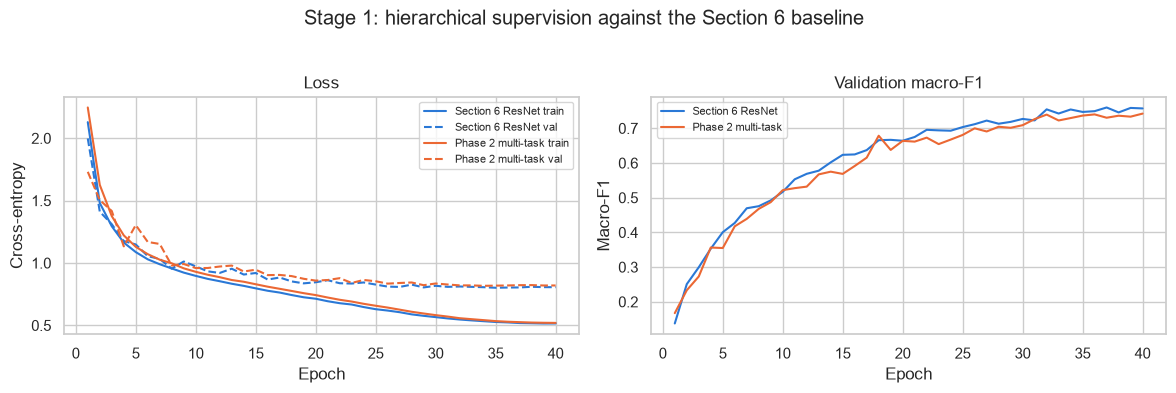

[memory after Phase 2] host RSS 2.69 GB | device allocated 0.86 GB reserved 1.39 GB


In [30]:
if RUN_PHASE2 and wanted("phase2"):
    # --- Stage 1: instance-balanced, with hierarchical supervision -------------------
    set_seed(RANDOM_STATE)
    p2_backbone = prepare_model(phase2_factory(), compile_ok=False)
    cached = restore(P2_BACKBONE_KEY, p2_backbone)
    if cached is None:
        p2_criterion = HierarchicalLoss(p2_backbone, weight=P2_AUX_WEIGHT)
        p2_history, p2_stage1_logits, _ = fit(
            p2_backbone, train_loader, val_loader, label="Phase 2 stage 1",
            run_name=P2_BACKBONE_KEY, criterion=p2_criterion,
        )
        bank(P2_BACKBONE_KEY, p2_backbone, p2_stage1_logits, p2_history)
    else:
        p2_history, p2_stage1_logits = cached["history"], cached["val_logits"]

    record(evaluate_predictions(y_val, p2_stage1_logits.argmax(axis=1), p2_stage1_logits,
                                "5a. Multi-task ResNet (plain CE)"))

    # --- Stage 2: softened class-balanced classifier retraining ----------------------
    support = np.maximum(np.bincount(y_train, minlength=N_CLASSES), 1).astype(np.float64)
    p2_sample_weights = (support ** -P2_SAMPLER_POWER)[y_train]
    ratio_before = (support.max() / support.min()) ** 1.0
    ratio_after = (support.max() / support.min()) ** P2_SAMPLER_POWER
    print(f"Sampler over-representation of the rarest class relative to the largest: "
          f"{ratio_after:,.0f}x at power {P2_SAMPLER_POWER} "
          f"(Section 6.2 used {ratio_before:,.0f}x)")

    p2_balanced, _ = make_loaders(weights=p2_sample_weights)

    set_seed(RANDOM_STATE)
    p2_head = build_decoupled_from(p2_backbone, phase2_factory)
    cached = restore(P2_HEAD_KEY, p2_head)
    if cached is None:
        PHASE2_LOGITS, p2_stage2_history = run_stage_two(
            p2_head, p2_balanced, epochs=P2_STAGE2_EPOCHS, run_name=P2_HEAD_KEY,
        )
        bank(P2_HEAD_KEY, p2_head, PHASE2_LOGITS)
    else:
        PHASE2_LOGITS = cached["val_logits"]

    record(evaluate_predictions(y_val, PHASE2_LOGITS.argmax(axis=1), PHASE2_LOGITS,
                                "5. Multi-task ResNet + softened decoupling"))

    PHASE2_MEMBER_SPEC = [(P2_HEAD_KEY, phase2_factory)]
    plot_history({"Section 6 ResNet": globals().get("resnet_history"),
                  "Phase 2 multi-task": p2_history},
                 "Stage 1: hierarchical supervision against the Section 6 baseline")

    release("p2_backbone")
    report_memory("after Phase 2")
else:
    print("RUN_PHASE2 is False.")

### 7.7 Reading Run A: The Localised-Detail Pairs

The rule fixed in Section 7.6 applies here. The pairs below were not chosen after seeing this
run; they are the confusions Section 8.1 already reported for the Phase 1 finalist, and they are
the ones whose discriminative evidence occupies a small region of the frame. If removing a stride
recovers evidence the global average pool was destroying, it shows here first and in macro-F1
second, if at all.

Three outcomes and what each licenses the report to say.

- **Pair rates fall materially and macro-F1 holds.** The pooling was the bottleneck for
  fine-grained separation. The report gets a mechanism rather than an observation, and the
  follow-up is spatial capacity, not more data.
- **Pair rates are flat.** The 60x80 image does not carry the distinction. Section 8.1's
  confusions become a documented property of the data, evidenced by an experiment that could have
  come out the other way, and the honest recommendation is higher-resolution source images.
- **Pair rates fall but macro-F1 drops.** The finer map traded tail performance for head
  separation. That is a real finding and it argues for the change as a component of an ensemble
  rather than as a replacement.


In [31]:
if COMBINE:
    # --- Run A readout: the pairs the hypothesis is about ------------------------------
    # Fixed in Section 7.6 before the run. Read this table before macro-F1: Flats and Heels hold
    # roughly 293 validation images between them, so this whole family of confusions is worth about
    # half a point of macro-F1, which is inside the 0.0116 seed standard deviation.
    READOUT_PAIRS = [
        ("Flats", "Heels"), ("Heels", "Flats"),
        ("Sports Sandals", "Sandals"), ("Duffel Bag", "Handbags"),
        ("Tops", "Tshirts"), ("Tunics", "Tops"),
        ("Kurtis", "Kurtas"), ("Scarves", "Mufflers"),
    ]


    def pair_rates(predictions):
        """Error count and share of the true class for each watched pair."""
        matrix = confusion_matrix(y_val, predictions, labels=np.arange(N_CLASSES))
        rows = {}
        for true_name, predicted_name in READOUT_PAIRS:
            if true_name not in CLASS_TO_INDEX or predicted_name not in CLASS_TO_INDEX:
                continue
            true_index = CLASS_TO_INDEX[true_name]
            support = matrix[true_index].sum()
            errors = matrix[true_index, CLASS_TO_INDEX[predicted_name]]
            rows[f"{true_name} -> {predicted_name}"] = (
                np.nan if support == 0 else 100.0 * errors / support
            )
        return rows


    if RUN_PHASE2 and "PHASE2_LOGITS" in globals():
        # The three models compared on identical rows by identical code.
        watched = {}
        if "decoupled_logits" in globals():
            watched["Section 6 finalist (seed 42)"] = decoupled_logits.argmax(axis=1)
        watched[f"Phase 2 variant {P2_VARIANT}"] = PHASE2_LOGITS.argmax(axis=1)
        if "PHASE1_PROBABILITIES" in globals():
            watched["Phase 1 ensemble + TTA"] = PHASE1_PROBABILITIES.argmax(axis=1)

        pair_table = pd.DataFrame(
            {name: pair_rates(predictions) for name, predictions in watched.items()}
        ).T
        print("Share of the true class sent to the confused class, in percent. Lower is better.")
        display(pair_table.style.format("{:.1f}%", na_rep="-"))

        # Per-class F1 for the classes involved, since a pair rate can fall because the model
        # stopped predicting the class at all rather than because it separated it.
        involved = sorted({name for pair in READOUT_PAIRS for name in pair
                           if name in CLASS_TO_INDEX})
        f1_table = pd.DataFrame({
            name: per_class_f1(y_val, predictions).reindex(involved)
            for name, predictions in watched.items()
        })
        print("\nPer-class F1 for the classes in those pairs. A pair rate that falls while F1 "
              "falls with it means the class was abandoned, not separated.")
        display(f1_table.style.format("{:.3f}", na_rep="-"))

        # --- The comparison bar, applied ----------------------------------------------
        SEED_MEAN, SEED_STD = 0.7767, 0.0116          # Section 7, ResNet + decoupled, 3 seeds
        p2_macro = f1_score(y_val, PHASE2_LOGITS.argmax(axis=1), labels=SCOREABLE,
                            average="macro", zero_division=0)
        print(f"\nSingle against single: Phase 2 {p2_macro:.4f} against the Section 6 seed mean "
              f"{SEED_MEAN:.4f} +/- {SEED_STD:.4f} (delta {p2_macro - SEED_MEAN:+.4f}, "
              f"{abs(p2_macro - SEED_MEAN) / SEED_STD:.1f} standard deviations)")
        if abs(p2_macro - SEED_MEAN) <= SEED_STD:
            print("  Inside one standard deviation. This is a draw and is reported as one.")

        # Matched inference budget: two forward passes each.
        p2_tta = predict_probabilities(val_loader, PHASE2_MEMBER_SPEC, tta=True)
        p2_tta_macro = f1_score(y_val, p2_tta.argmax(axis=1), labels=SCOREABLE,
                                average="macro", zero_division=0)
        if "single_tta" in globals():
            p11_macro = f1_score(y_val, single_tta.argmax(axis=1), labels=SCOREABLE,
                                 average="macro", zero_division=0)
            print(f"Matched budget (2 passes): Phase 2 + TTA {p2_tta_macro:.4f} against P1.1 "
                  f"{p11_macro:.4f} (delta {p2_tta_macro - p11_macro:+.4f})")
        record(evaluate_predictions(y_val, p2_tta.argmax(axis=1), np.log(p2_tta + 1e-12),
                                    f"5b. Phase 2 {P2_VARIANT} + flip TTA"))

        # Coverage of the label space, which the pair table cannot show.
        p2_f1_all = per_class_f1(y_val, PHASE2_LOGITS.argmax(axis=1))
        print(f"\nClasses scoring exactly zero F1: {(p2_f1_all == 0).sum()} of {len(p2_f1_all)}")
        print(f"Distinct classes predicted on validation: "
              f"{len(np.unique(PHASE2_LOGITS.argmax(axis=1)))} of {N_CLASSES}")
    else:
        print("Run the Phase 2 cell above first.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


Share of the true class sent to the confused class, in percent. Lower is better.


,Flats -> Heels,Heels -> Flats,Sports Sandals -> Sandals,Duffel Bag -> Handbags,Tops -> Tshirts,Tunics -> Tops,Kurtis -> Kurtas,Scarves -> Mufflers
Section 6 finalist (seed 42),36.9%,15.3%,15.4%,17.6%,13.2%,17.1%,22.0%,18.2%
Phase 2 variant A,53.6%,5.3%,53.8%,23.5%,8.9%,25.7%,9.8%,13.6%
Phase 1 ensemble + TTA,40.5%,14.4%,30.8%,23.5%,13.2%,20.0%,14.6%,13.6%



Per-class F1 for the classes in those pairs. A pair rate that falls while F1 falls with it means the class was abandoned, not separated.


,Section 6 finalist (seed 42),Phase 2 variant A,Phase 1 ensemble + TTA
Duffel Bag,0.750,0.690,0.800
Flats,0.509,0.375,0.482
Handbags,0.942,0.927,0.948
Heels,0.775,0.802,0.767
Kurtas,0.918,0.909,0.925
Kurtis,0.409,0.466,0.527
Mufflers,0.471,0.588,0.625
Sandals,0.813,0.804,0.839
Scarves,0.727,0.773,0.792
Sports Sandals,0.485,0.242,0.414



Single against single: Phase 2 0.7564 against the Section 6 seed mean 0.7767 +/- 0.0116 (delta -0.0203, 1.8 standard deviations)
Matched budget (2 passes): Phase 2 + TTA 0.7606 against P1.1 0.7518 (delta +0.0088)


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,5b. Phase 2 A + flip TTA,0.8817,0.7606,0.7633,0.8837,0.9836,0.8966,0.8361,0.7583,0.5952



Classes scoring exactly zero F1: 7 of 110
Distinct classes predicted on validation: 110 of 124


### 7.8 Sampler Strength: A Sweep Rather Than a Second Full Model

Run B proposes three changes at once. One of them, the softened sampler, can be isolated for a
fraction of the cost, because it acts only on stage 2 and stage 2 runs on a frozen backbone. This
section reuses the Section 6 stage-1 backbone already on disk and retrains nothing but a
63,612-parameter linear head, five times.

The question is sharper than "is 0.5 better than 1.0". Stage-2 sampling draws each row with weight
`support ** -power`, so `power` interpolates between two named recipes and the sweep measures the
whole path between them:

| power | What it is | Rarest against largest draw ratio |
|---|---|---|
| 0.0 | uniform. The head is retrained but not rebalanced | 1x |
| 0.25, 0.5, 0.75 | softened class balancing | 12x to 653x |
| 1.0 | Section 6.2 exactly | 5,267x |

Three things this buys that a single Run B could not.

- **`power = 0.0` is a free ablation.** It separates *retraining the head at all* from *rebalancing
  it*, which is the precise claim Section 6 attributes to Kang et al. Until now the notebook has
  those two changes bundled.
- **`power = 1.0` is a reproduction check.** Same backbone, same seed, same budget as Section 6.2,
  so it must land on 0.7673. A material discrepancy means a checkpoint moved and the sweep is not
  trustworthy, exactly as row P1.0 checks Phase 1.
- **A curve rather than a point.** If macro-F1 is flat across the middle of the range, sampler
  strength is not the lever and Run B loses its most promising component. If it peaks, the peak
  is a tuned hyper-parameter with the shape of the response behind it.

The bucket columns carry the real answer. A sampler that helps must move the rare and tail
buckets, and the cost it charges shows in the head bucket and in top-1 accuracy.


In [32]:
if wanted("sweep"):
    # --- Stage-2 sampler sweep on the banked Section 6 backbone ------------------------
    # A job of its own rather than combine-only work: five stage-2 heads is roughly eight
    # minutes that need not sit on the machine doing the final assembly. It is the one job
    # with a prerequisite, `model_resnet_stage1.pt`, so it pairs onto the resnet machine
    # as JOB_FILTER = {"resnet", "sweep"} unless that file is copied in first.
    # No backbone training happens here. `build_decoupled` freezes a copy of the stage-1 model
    # and attaches a fresh head, so each run costs one forward pass per epoch over the training
    # set plus the validation pass. Section 6.2's own settings are reused unchanged apart from
    # the sampler weight, which is the variable under test.
    RUN_SAMPLER_SWEEP = True
    SAMPLER_POWERS = [0.0, 0.25, 0.5, 0.75, 1.0]

    if RUN_SAMPLER_SWEEP:
        source_backbone = resnet if "resnet" in globals() else load_banked("resnet_stage1",
                                                                           SmallResNet)
        assert source_backbone is not None, "Section 6 stage-1 backbone is not available."

        support_counts = np.maximum(np.bincount(y_train, minlength=N_CLASSES), 1).astype(np.float64)
        imbalance = support_counts.max() / support_counts.min()

        sweep_rows, SWEEP_LOGITS, SWEEP_KEYS = [], {}, {}
        for power in SAMPLER_POWERS:
            key = f"stage2_power_{str(power).replace('.', 'p')}"
            SWEEP_KEYS[power] = key
            print(f"\n--- sampler power {power} "
                  f"(rarest class drawn {imbalance ** power:,.0f}x the largest) ---")

            sweep_loader, _ = make_loaders(weights=(support_counts ** -power)[y_train])

            # Seeded before the head is built, so every power starts from the same fresh
            # classifier initialisation and the difference between rows is the sampler alone.
            set_seed(RANDOM_STATE)
            head = build_decoupled(source_backbone)
            cached = restore(key, head)
            if cached is None:
                set_seed(RANDOM_STATE)
                logits, _ = run_stage_two(head, sweep_loader, run_name=key)
                bank(key, head, logits)
            else:
                logits = cached["val_logits"]

            SWEEP_LOGITS[power] = logits
            row = evaluate_predictions(y_val, logits.argmax(axis=1), logits,
                                       f"S2 sampler power {power}")
            row.insert(1, "Draw ratio", imbalance ** power)
            sweep_rows.append(row)

            del head
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        sweep = pd.concat(sweep_rows, ignore_index=True)
        display(sweep.style.format({c: "{:.4f}" for c in sweep.columns
                                    if c not in ("Model", "Draw ratio")})
                .format({"Draw ratio": "{:,.0f}x"})
                .background_gradient(subset=["Macro-F1"], cmap="Blues"))
else:
    print("Skipped: 'sweep' is not this machine's job.")



--- sampler power 0.0 (rarest class drawn 1x the largest) ---
  [stage 2] epoch 1/10  macro-F1 0.6685  9s  duty 65%
  [stage 2] epoch 2/10  macro-F1 0.6860  9s  duty 65%
  [stage 2] epoch 3/10  macro-F1 0.6740  9s  duty 65%
  [stage 2] epoch 4/10  macro-F1 0.7129  9s  duty 65%
  [stage 2] epoch 5/10  macro-F1 0.7198  9s  duty 65%
  [stage 2] epoch 6/10  macro-F1 0.7231  9s  duty 65%
  [stage 2] epoch 7/10  macro-F1 0.7338  9s  duty 65%
  [stage 2] epoch 8/10  macro-F1 0.7016  9s  duty 65%
  [stage 2] epoch 9/10  macro-F1 0.7543  9s  duty 65%
  [stage 2] epoch 10/10  macro-F1 0.7531  9s  duty 65%
  banked -> model_stage2_power_0p0.pt (50.5 MB)

--- sampler power 0.25 (rarest class drawn 9x the largest) ---
  [stage 2] epoch 1/10  macro-F1 0.7366  9s  duty 65%
  [stage 2] epoch 2/10  macro-F1 0.7225  9s  duty 65%
  [stage 2] epoch 3/10  macro-F1 0.6992  9s  duty 65%
  [stage 2] epoch 4/10  macro-F1 0.7309  9s  duty 65%
  [stage 2] epoch 5/10  macro-F1 0.7153  9s  duty 65%
  [stage 2] ep

,Model,Draw ratio,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,S2 sampler power 0.0,1x,0.892970,0.754339,0.734570,0.889811,0.982955,0.900125,0.850823,0.747204,0.563492
1,S2 sampler power 0.25,9x,0.890592,0.754192,0.746098,0.888124,0.981633,0.902607,0.842985,0.751841,0.563492
2,S2 sampler power 0.5,73x,0.893763,0.762814,0.753336,0.891781,0.983087,0.900377,0.852267,0.755175,0.587302
3,S2 sampler power 0.75,618x,0.888742,0.761329,0.760425,0.888209,0.981633,0.894488,0.850129,0.736863,0.626984
4,S2 sampler power 1.0,"5,267x",0.890592,0.760331,0.769434,0.891539,0.983483,0.900781,0.853365,0.731302,0.626984


Reproduction check: power 1.0 scores 0.7603 against Section 6.2's 0.7673 (delta -0.0070)
  Larger than inference noise. Treat the sweep as untrustworthy until this is explained: a checkpoint or the split has moved.


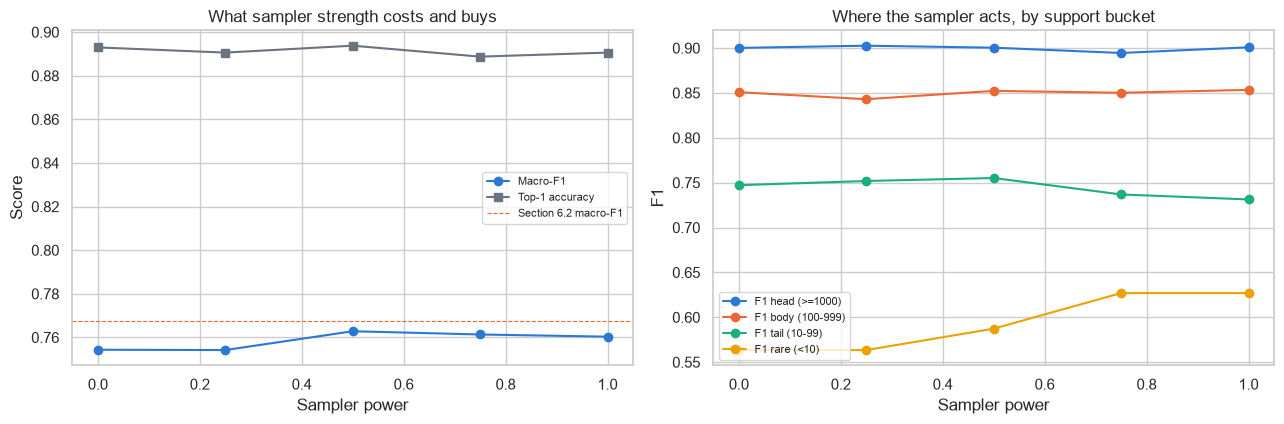


Best power: 0.5 at macro-F1 0.7628, against 0.7603 at power 1.0 (delta +0.0025, 0.2 seed standard deviations)
  Inside one standard deviation of the Section 6.2 recipe. Sampler strength is not the lever, and Run B loses its most promising component.

Retraining the head without rebalancing it (power 0.0) reaches 0.7543. Rebalancing adds +0.0085 on top of that, which is the decomposition Section 6 asserted and did not measure.


In [33]:
if COMBINE:
    if RUN_SAMPLER_SWEEP:
        # --- Reproduction check ----------------------------------------------------------
        # power 1.0 is Section 6.2 rebuilt from the same backbone, seed and budget.
        at_one = float(sweep.loc[sweep["Model"] == "S2 sampler power 1.0", "Macro-F1"].iloc[0])
        reference = 0.7673
        print(f"Reproduction check: power 1.0 scores {at_one:.4f} against Section 6.2's "
              f"{reference:.4f} (delta {at_one - reference:+.4f})")
        if abs(at_one - reference) > 0.005:
            print("  Larger than inference noise. Treat the sweep as untrustworthy until this "
                  "is explained: a checkpoint or the split has moved.")

        # --- The curve -------------------------------------------------------------------
        buckets = [c for c in sweep.columns if c.startswith("F1 ")]
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
        axes[0].plot(SAMPLER_POWERS, sweep["Macro-F1"], marker="o", color=PALETTE[0],
                     label="Macro-F1")
        axes[0].plot(SAMPLER_POWERS, sweep["Top-1 accuracy"], marker="s", color=MUTED,
                     label="Top-1 accuracy")
        axes[0].axhline(reference, color=PALETTE[1], lw=0.8, ls="--",
                        label="Section 6.2 macro-F1")
        axes[0].set(title="What sampler strength costs and buys", xlabel="Sampler power",
                    ylabel="Score")
        axes[0].legend(fontsize=8)

        for position, column in enumerate(buckets):
            axes[1].plot(SAMPLER_POWERS, sweep[column], marker="o",
                         color=PALETTE[position % len(PALETTE)], label=column)
        axes[1].set(title="Where the sampler acts, by support bucket",
                    xlabel="Sampler power", ylabel="F1")
        axes[1].legend(fontsize=8)
        plt.tight_layout(); save_figure("04_sampler_sweep"); plt.show()

        # --- The verdict, against the pre-committed bar -----------------------------------
        SEED_STD = 0.0116
        best_position = int(sweep["Macro-F1"].idxmax())
        SWEEP_BEST_POWER = SAMPLER_POWERS[best_position]
        best_macro = float(sweep.loc[best_position, "Macro-F1"])
        print(f"\nBest power: {SWEEP_BEST_POWER} at macro-F1 {best_macro:.4f}, against "
              f"{at_one:.4f} at power 1.0 (delta {best_macro - at_one:+.4f}, "
              f"{abs(best_macro - at_one) / SEED_STD:.1f} seed standard deviations)")
        if best_macro - at_one <= SEED_STD:
            print("  Inside one standard deviation of the Section 6.2 recipe. Sampler strength "
                  "is not the lever, and Run B loses its most promising component.")
            SWEEP_BEST_KEY = None
        else:
            SWEEP_BEST_KEY = SWEEP_KEYS[SWEEP_BEST_POWER]
            print(f"  Clears the band. Registered as a Section 8 candidate from {SWEEP_BEST_KEY}.")

        uniform = float(sweep.loc[0, "Macro-F1"])
        print(f"\nRetraining the head without rebalancing it (power 0.0) reaches {uniform:.4f}. "
              f"Rebalancing adds {best_macro - uniform:+.4f} on top of that, which is the "
              f"decomposition Section 6 asserted and did not measure.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


In [34]:
if COMBINE:
    # Every candidate so far, in one place. The Phase rows are the new evidence; the Section 3-6
    # rows are unchanged and are what the new rows have to beat.
    progress = pd.concat(RESULTS, ignore_index=True)
    display(progress.style.format({c: "{:.4f}" for c in progress.columns if c != "Model"})
            .background_gradient(subset=["Macro-F1"], cmap="Blues"))

    if {"3. ResNet + decoupled classifier"}.issubset(set(progress["Model"])):
        reference_macro = float(progress.loc[progress["Model"]
                                == "3. ResNet + decoupled classifier", "Macro-F1"].iloc[0])
        seed_spread = 0.0
        seed_path = ARTEFACT_DIR / "task1_seed_study.csv"
        if seed_path.exists():
            seed_frame = pd.read_csv(seed_path)
            if "Macro-F1" in seed_frame.columns:
                seed_spread = float(seed_frame.groupby("Model")["Macro-F1"].std().max())
        print(f"Section 6 finalist macro-F1: {reference_macro:.4f} | "
              f"largest seed standard deviation observed: {seed_spread:.4f}")
        print("A new row is only a real improvement if it clears the reference by more than "
              "roughly one standard deviation. Anything inside that band is a draw, and should "
              "be reported as one.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,Baseline: majority class,0.1740,0.0027,0.0091,0.0516,0.2557,0.0371,0.0000,0.0000,0.0000
1,Baseline: stratified random,0.0579,0.0088,0.0089,0.0583,0.4309,0.0701,0.0095,0.0019,0.0000
2,1. HOG + linear SVM,0.8056,0.6343,0.6671,0.8081,0.9536,0.8195,0.7375,0.6336,0.4032
3,2. CNN from scratch,0.8799,0.6979,0.6806,0.8735,0.9922,0.8891,0.8181,0.6803,0.4762
4,3a. ResNet (plain CE),0.8960,0.7601,0.7417,0.8930,0.9884,0.9036,0.8552,0.7429,0.5952
5,3. ResNet + decoupled classifier,0.8906,0.7603,0.7694,0.8915,0.9835,0.9008,0.8534,0.7313,0.6270
6,"3b. ResNet (logit-adjusted, tau=1.0)",0.5646,0.6882,0.7470,0.6387,0.6775,0.6229,0.8170,0.7399,0.3924
7,4. Ensemble x3 + TTA,0.8948,0.7930,0.7939,0.8950,0.9881,0.9030,0.8588,0.7777,0.6825
8,"4b. + logit adjustment, out-of-fold tau (measured, not deployed)",0.8935,0.7869,0.7940,0.8945,0.9881,0.9030,0.8569,0.7720,0.6667
9,5a. Multi-task ResNet (plain CE),0.8899,0.7424,0.7301,0.8859,0.9908,0.8977,0.8423,0.7470,0.5159


Section 6 finalist macro-F1: 0.7603 | largest seed standard deviation observed: 0.0131
A new row is only a real improvement if it clears the reference by more than roughly one standard deviation. Anything inside that band is a draw, and should be reported as one.


#### On `P2_FINER_MAP`, and What It Would and Would Not Show

The images are 60x80 and the source data cannot be changed, so upsampling them is not on the
table: bicubic interpolation is a deterministic function of the input and adds no information a
convolutional network could not compute for itself. It would cost four times the compute for
pixels carrying no new evidence.

There is a separate question that is often confused with it. The network's final feature map is
10x8, and the pooled embedding is an average over those 80 positions. If the evidence separating
`Flats` from `Heels` occupies one or two of them, it is being averaged against 78 positions of
white background before the classifier ever sees it. `P2_FINER_MAP = True` removes one stride so
the map is 20x15, leaving the input untouched.

That makes it a clean test with an interpretable outcome either way. A gain says the pooling
was destroying localised evidence, and the sensible follow-up is more capacity in the spatial
dimension. No gain says the 60x80 image genuinely does not contain the distinction, the
confusions in Section 8.1 are a property of the data, and the report should say so with this
experiment as the evidence rather than asserting it. It is Run A above, and it writes to its own checkpoint
key, so neither variant can disturb the other.

**Outcome.** No gain, and a loss on the pairs the experiment was designed to test. By the terms
set out above, that licenses the second reading: the 60x80 image does not carry these
distinctions, and the confusions reported in Section 8.1 are a property of the data. The report
states that with this experiment as the evidence rather than asserting it, and the honest
recommendation for improving these classes is higher-resolution source images, not a larger
model.

## 7.9 Learning-Rate Search

Every hyperparameter in Section 1.1 was fixed by argument rather than by experiment. This
section closes that gap for the one that matters most, on the two models that are not
baselines: the CNN of Section 5 and the ResNet backbone of Section 6.

Three decisions define the search and each is a claim the reader can check.

**A log-spaced grid.** `3e-4`, `1e-3`, `3e-3`, a factor of three apart. Learning rate acts
multiplicatively, so a linear grid around 1e-3 would compare three values that behave almost
identically; a decade-wide log grid is what actually separates them.

**A reduced budget of 15 epochs, with early stopping switched off.** A search is a ranking
problem, not a final-score problem, and 15 epochs is enough to order three learning rates an
order of magnitude apart. Patience is set equal to the budget so every arm trains for the same
number of epochs — otherwise a rate that plateaus early would be scored on fewer updates than
its rivals and the comparison would confound rate with budget. The scores below are therefore
15-epoch scores and are not comparable with the 40-epoch numbers in the main table.

**Everything else held fixed**, including the seed and the split. Any difference between rows
is attributable to the learning rate alone. `fit()` takes `lr` and `epochs` as arguments, so
Section 1.1 is untouched and `RUN_FINGERPRINT` is unchanged: every checkpoint already on disk
stays valid and this section only adds files of its own.

Six runs. The table and the figure are written to disk, losers included, because the point of
reporting a search is to show the space that was explored rather than only the value that won.


In [ ]:
# --- Learning-rate search over the two non-baseline models -------------------------------
RUN_LR_SEARCH = True
LR_GRID = [3e-4, 1e-3, 3e-3]
LR_SEARCH_EPOCHS = 15

if RUN_LR_SEARCH and wanted("lrsearch"):
    lr_rows = []
    for architecture, factory in (("CNN", PlainCNN), ("ResNet", SmallResNet)):
        for lr in LR_GRID:
            key = f"lrsearch_{architecture.lower()}_{lr:.0e}".replace("-", "m")
            print(f"\n--- {architecture}, lr = {lr:.0e} ---")

            # Seeded before construction so all six arms start from the same initialisation.
            set_seed(RANDOM_STATE)
            candidate = prepare_model(factory(), compile_ok=False)
            cached = restore(key, candidate)
            if cached is None:
                history, logits, _ = fit(
                    candidate, train_loader, val_loader,
                    epochs=LR_SEARCH_EPOCHS, lr=lr,
                    patience=LR_SEARCH_EPOCHS,      # equal budget for every arm
                    label=f"{architecture} lr={lr:.0e}", run_name=key, verbose_every=5,
                )
                bank(key, candidate, logits, history)
            else:
                logits = cached["val_logits"]

            row = evaluate_predictions(y_val, logits.argmax(axis=1), logits,
                                       f"{architecture} lr={lr:.0e}")
            row.insert(1, "Learning rate", lr)
            lr_rows.append(row)

            del candidate
            gc.collect()
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    lr_search = pd.concat(lr_rows, ignore_index=True)
    lr_search.to_csv(ARTEFACT_DIR / "task1_lr_search.csv", index=False)
    display(lr_search.style
            .format({c: "{:.4f}" for c in lr_search.columns
                     if c not in ("Model", "Learning rate")})
            .format({"Learning rate": "{:.0e}"})
            .background_gradient(subset=["Macro-F1"], cmap="Blues"))
    report_memory("after the learning-rate search")
else:
    print("RUN_LR_SEARCH is False.")


In [ ]:
if RUN_LR_SEARCH and (COMBINE or wanted("lrsearch")):
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    for position, architecture in enumerate(("CNN", "ResNet")):
        subset = lr_search[lr_search["Model"].str.startswith(architecture)]
        ax.plot(subset["Learning rate"], subset["Macro-F1"], marker="o",
                color=PALETTE[position], label=architecture)
    ax.axvline(LEARNING_RATE, color=MUTED, lw=0.8, ls="--", label="Section 1.1 value")
    ax.set(xscale="log", xlabel="Learning rate (log scale)", ylabel="Validation macro-F1",
           title=f"Learning-rate search at {LR_SEARCH_EPOCHS} epochs, seed {RANDOM_STATE}")
    ax.legend(fontsize=8)
    plt.tight_layout(); save_figure("09_lr_search"); plt.show()

    # The verdict, stated against the noise floor rather than as a bare argmax. SEED_SPREAD
    # is the largest seed standard deviation Section 7 observed; a gap smaller than that is
    # a draw, and reporting it as a win would be reading noise.
    spread = float(globals().get("seed_spread") or 0.0131)
    for architecture in ("CNN", "ResNet"):
        subset = lr_search[lr_search["Model"].str.startswith(architecture)].reset_index(drop=True)
        best = subset.loc[subset["Macro-F1"].idxmax()]
        incumbent = subset.loc[(subset["Learning rate"] - LEARNING_RATE).abs().idxmin()]
        margin = best["Macro-F1"] - incumbent["Macro-F1"]
        verdict = ("beats" if margin > spread else "ties")
        print(f"{architecture}: best lr = {best['Learning rate']:.0e} "
              f"(macro-F1 {best['Macro-F1']:.4f}) {verdict} the incumbent "
              f"{incumbent['Learning rate']:.0e} ({incumbent['Macro-F1']:.4f}), "
              f"margin {margin:+.4f} against a noise floor of {spread:.4f}")


In [ ]:
# --- Worker stop ------------------------------------------------------------------------
# In combine mode this is a no-op and the notebook continues. In worker mode it halts a
# "Run All" here with a visible message, which is the point: everything below reads models
# this machine was not asked to train.
if not COMBINE:
    print("Worker finished:", sorted(JOB_FILTER))
    print("\nCheckpoints written this session:")
    # .npz and .joblib included: model_hog_svm_scores.npz is what the SVM restore actually
    # reads, and listing only .pt sends the reader to the combine machine without it.
    for _pattern in ("*.pt", "*.joblib", "*.npz"):
        for _path in sorted(CHECKPOINT_DIR.glob(_pattern)):
            print(f"  {_path.name}  ({_path.stat().st_size / 1e6:.1f} MB)")
    print(f"\nCopy the contents of {CHECKPOINT_DIR} to the combine machine's "
          f"models/task1/checkpoints/, then run this notebook there with JOB_FILTER = None.")
    raise RuntimeError("Worker mode: deliberate stop, not a failure. "
                       "Set JOB_FILTER = None in Section 1.0 to run the full notebook.")


## 8. Ultimate Judgement

The metric table narrows the field; it does not settle it. This section applies six checks that a
performance number cannot answer, and the recommendation in Section 8.7 rests on those six and the
metric table together.

Assign the finalist here once, so every diagnostic below reads the same model.

In [35]:
if COMBINE:
    # The model taken forward. Every diagnostic below reads FINAL_* and nothing hard-codes a
    # candidate, so changing FINAL_CHOICE re-runs the whole of Section 8 on a different model.
    #
    # "auto" takes the highest macro-F1 among the candidates that actually exist in this run.
    # That is a defensible default and not a judgement: Sections 8.1 to 8.6 exist precisely
    # because the metric does not settle the choice, and 8.7 may well override this.
    FINAL_CHOICE = "auto"

    candidates = {}
    if "decoupled_logits" in globals():
        candidates["3. ResNet + decoupled classifier"] = {
            "logits": decoupled_logits, "model": decoupled,
            "members": [("resnet_decoupled", SmallResNet)], "tta": False, "tau": 0.0,
        }
    if "PHASE2_LOGITS" in globals():
        candidates["5. Multi-task ResNet + softened decoupling"] = {
            "logits": PHASE2_LOGITS, "model": p2_head,
            "members": PHASE2_MEMBER_SPEC, "tta": False, "tau": 0.0,
        }
    if "PHASE1_LOGITS" in globals():
        candidates[PHASE1_NAME] = {
            "logits": PHASE1_LOGITS, "model": None,
            "members": PHASE1_MEMBER_SPEC, "tta": PHASE1_TTA, "tau": PHASE1_TAU,
        }

    # The sweep enters as a candidate only when Section 7.8 found it clears the seed band.
    # A row that is a draw is evidence for the report, not a model to deploy.
    if globals().get("SWEEP_BEST_KEY"):
        candidates[f"6. ResNet + decoupled classifier (sampler power {SWEEP_BEST_POWER})"] = {
            "logits": SWEEP_LOGITS[SWEEP_BEST_POWER], "model": None,
            "members": [(SWEEP_BEST_KEY, SmallResNet)], "tta": False, "tau": 0.0,
        }

    if FINAL_CHOICE == "auto":
        scored = {
            name: f1_score(y_val, spec["logits"].argmax(axis=1), labels=SCOREABLE,
                           average="macro", zero_division=0)
            for name, spec in candidates.items()
        }
        FINAL_NAME = max(scored, key=scored.get)
        print("Candidates by validation macro-F1:")
        for name, value in sorted(scored.items(), key=lambda item: -item[1]):
            print(f"  {value:.4f}  {name}")
    else:
        FINAL_NAME = FINAL_CHOICE

    selected = candidates[FINAL_NAME]
    final_logits = selected["logits"]
    final_pred = final_logits.argmax(axis=1)
    FINAL_MEMBERS, FINAL_TTA, FINAL_TAU = selected["members"], selected["tta"], selected["tau"]

    # Sections 8.5 and 8.6 need a single nn.Module to time and to differentiate. For an ensemble
    # that is one representative member, and the cost table multiplies its latency by the number
    # of forward passes the deployed pipeline actually performs.
    final_model = selected["model"]
    if final_model is None:
        final_model = load_banked(*FINAL_MEMBERS[0])
    FINAL_FORWARD_PASSES = len(FINAL_MEMBERS) * (2 if FINAL_TTA else 1)

    reference_name, reference_pred = "2. CNN from scratch", cnn_pred

    print(f"\nSelected: {FINAL_NAME}")
    print(f"Inference: {len(FINAL_MEMBERS)} model(s) x {2 if FINAL_TTA else 1} view(s) "
          f"= {FINAL_FORWARD_PASSES} forward passes per image | tau = {FINAL_TAU:.2f}")

    summary_table = pd.concat(RESULTS, ignore_index=True)
    display(summary_table.style.format({c: "{:.4f}" for c in summary_table.columns if c != "Model"})
            .background_gradient(subset=["Macro-F1"], cmap="Blues"))
else:
    print('Skipped in worker mode: this runs on the combine machine.')


Candidates by validation macro-F1:
  0.7930  4. Ensemble x3 + TTA
  0.7603  3. ResNet + decoupled classifier
  0.7564  5. Multi-task ResNet + softened decoupling

Selected: 4. Ensemble x3 + TTA
Inference: 3 model(s) x 2 view(s) = 6 forward passes per image | tau = 0.00


,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-5 accuracy,F1 head (>=1000),F1 body (100-999),F1 tail (10-99),F1 rare (<10)
0,Baseline: majority class,0.1740,0.0027,0.0091,0.0516,0.2557,0.0371,0.0000,0.0000,0.0000
1,Baseline: stratified random,0.0579,0.0088,0.0089,0.0583,0.4309,0.0701,0.0095,0.0019,0.0000
2,1. HOG + linear SVM,0.8056,0.6343,0.6671,0.8081,0.9536,0.8195,0.7375,0.6336,0.4032
3,2. CNN from scratch,0.8799,0.6979,0.6806,0.8735,0.9922,0.8891,0.8181,0.6803,0.4762
4,3a. ResNet (plain CE),0.8960,0.7601,0.7417,0.8930,0.9884,0.9036,0.8552,0.7429,0.5952
5,3. ResNet + decoupled classifier,0.8906,0.7603,0.7694,0.8915,0.9835,0.9008,0.8534,0.7313,0.6270
6,"3b. ResNet (logit-adjusted, tau=1.0)",0.5646,0.6882,0.7470,0.6387,0.6775,0.6229,0.8170,0.7399,0.3924
7,4. Ensemble x3 + TTA,0.8948,0.7930,0.7939,0.8950,0.9881,0.9030,0.8588,0.7777,0.6825
8,"4b. + logit adjustment, out-of-fold tau (measured, not deployed)",0.8935,0.7869,0.7940,0.8945,0.9881,0.9030,0.8569,0.7720,0.6667
9,5a. Multi-task ResNet (plain CE),0.8899,0.7424,0.7301,0.8859,0.9908,0.8977,0.8423,0.7470,0.5159


### 8.1 Confusion Structure Against the EDA Hypotheses

Section 2.3 of notebook 00 ranked article types by the cosine similarity of their class mean
images and predicted which pairs a model would confuse, with Kurtas against Stoles the strongest
cross-family pair at 0.982. Those were hypotheses formed before any model existed. Checking them
against the realised confusion matrix closes the loop, and either outcome is informative:

- **Agreement** supports a visual explanation: the classes really are hard to separate at this
  resolution, and the error is a property of the data rather than of the model.
- **Disagreement** points elsewhere, to label noise, to imbalance, or to optimisation, and the
  remedy is different in each case.

Fill `EDA_HYPOTHESISED_PAIRS` from the cross-family table printed by Section 2.3 of notebook 00.

In [36]:
if COMBINE:
    # From Section 2.3 of the preprocessing notebook. Extend with the other leading cross-family
    # pairs printed there.
    EDA_HYPOTHESISED_PAIRS = [
        ("Kurtas", "Stoles"),
    ]

    confusion = confusion_matrix(y_val, final_pred, labels=np.arange(N_CLASSES))

    # Off-diagonal mass as a share of the true class's support: "when it is an X, how often is X
    # called Y". Normalising by support stops head classes from dominating purely by volume.
    with np.errstate(invalid="ignore", divide="ignore"):
        rates = confusion / confusion.sum(axis=1, keepdims=True)
    rates = np.nan_to_num(rates)
    np.fill_diagonal(rates, 0.0)

    pairs = []
    for true_index, predicted_index in zip(*np.where(rates > 0)):
        pairs.append({
            "True class": CLASSES[true_index],
            "Predicted as": CLASSES[predicted_index],
            "Errors": int(confusion[true_index, predicted_index]),
            "Share of true class %": rates[true_index, predicted_index] * 100,
            "Validation support": int(confusion[true_index].sum()),
        })
    confused = (pd.DataFrame(pairs)
                .query("`Validation support` >= 10")
                .sort_values("Share of true class %", ascending=False)
                .head(15).reset_index(drop=True))
    print("Most frequent confusions among classes with at least 10 validation images:")
    display(confused.style.format({"Share of true class %": "{:.1f}%"}))

    print("\nEDA hypotheses checked against the realised confusion matrix:")
    for left, right in EDA_HYPOTHESISED_PAIRS:
        if left not in CLASS_TO_INDEX or right not in CLASS_TO_INDEX:
            print(f"  {left} / {right}: not both present in the training label space.")
            continue
        a, b = CLASS_TO_INDEX[left], CLASS_TO_INDEX[right]
        both_ways = confusion[a, b] + confusion[b, a]
        support = confusion[a].sum() + confusion[b].sum()
        print(f"  {left} <-> {right}: {both_ways} mutual errors out of {support} validation images "
              f"({both_ways / max(support, 1) * 100:.1f}%)")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


Most frequent confusions among classes with at least 10 validation images:


,True class,Predicted as,Errors,Share of true class %,Validation support
0,Free Gifts,Watches,7,53.8%,13
1,Flats,Heels,34,40.5%,84
2,Sports Sandals,Sandals,4,30.8%,13
3,Duffel Bag,Handbags,4,23.5%,17
4,Tunics,Tops,7,20.0%,35
5,Bracelet,Bangle,2,20.0%,10
6,Capris,Shorts,5,18.5%,27
7,Fragrance Gift Set,Perfume and Body Mist,2,18.2%,11
8,Lounge Pants,Track Pants,2,18.2%,11
9,Necklace and Chains,Pendant,2,16.7%,12



EDA hypotheses checked against the realised confusion matrix:
  Kurtas <-> Stoles: 0 mutual errors out of 329 validation images (0.0%)


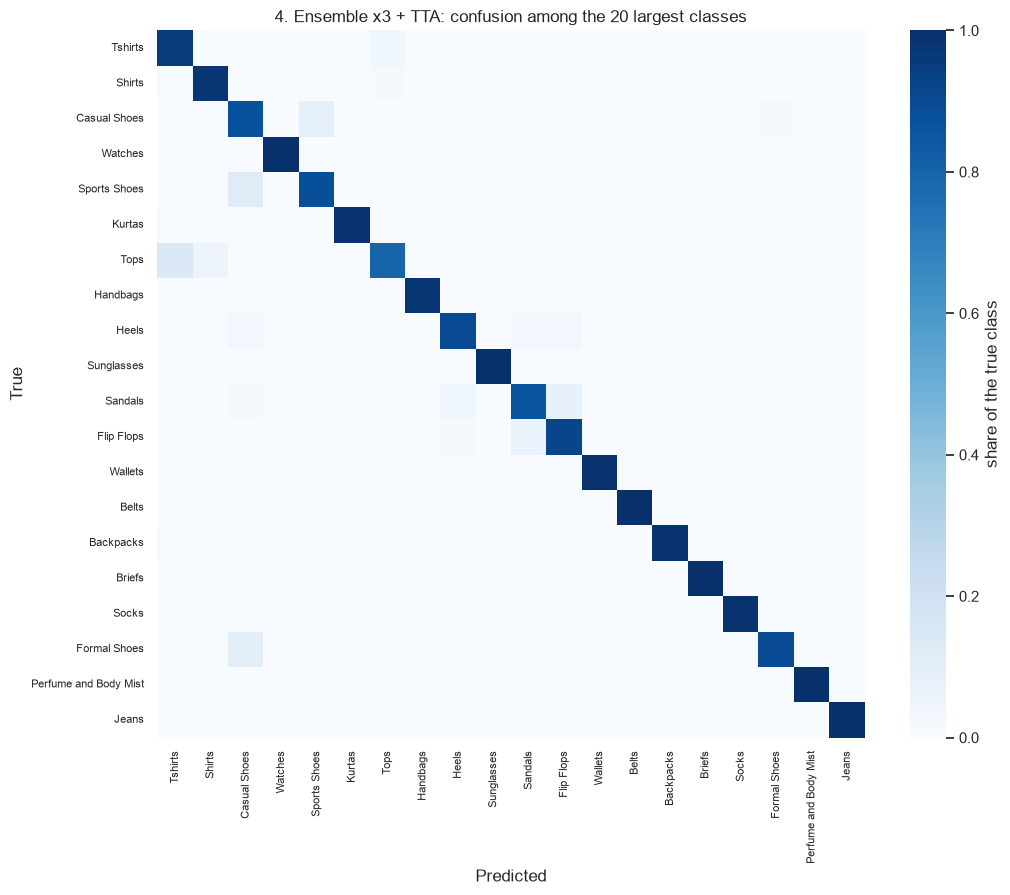

In [37]:
if COMBINE:
    # The head of the label space, where the confusion matrix is dense enough to read. The full
    # 124x124 matrix belongs in the appendix, not in a figure anyone is expected to interpret.
    top_classes = train_support.sort_values(ascending=False).head(20).index
    top_indices = [CLASS_TO_INDEX[c] for c in top_classes]
    block = confusion[np.ix_(top_indices, top_indices)]
    block_rates = block / np.maximum(block.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(block_rates, xticklabels=top_classes, yticklabels=top_classes,
                cmap="Blues", vmin=0, vmax=1, square=True, ax=ax,
                cbar_kws={"label": "share of the true class"})
    ax.set(title=f"{FINAL_NAME}: confusion among the 20 largest classes",
           xlabel="Predicted", ylabel="True")
    plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout(); save_figure("05_confusion_matrix"); plt.show()
else:
    print('Skipped in worker mode: this runs on the combine machine.')


### 8.2 Per-Class F1 Against Support

Where does the model stop working, and at what support? The scatter answers a question the bucket
averages only summarise, and it is the figure that tells a reader how much labelled data a new
article type would need before the system could be trusted with it.

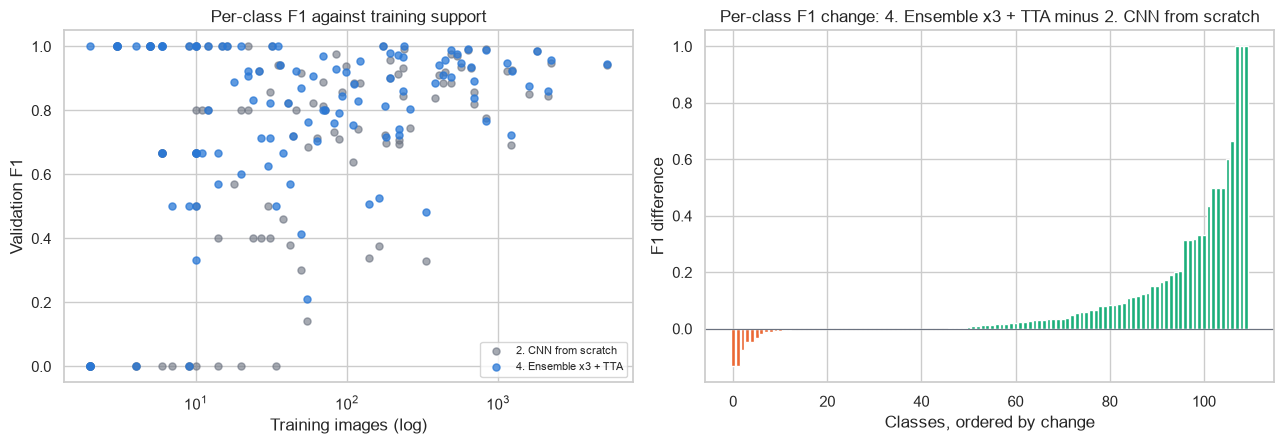

Classes improved: 65 | unchanged: 31 | degraded: 14

Largest gains:
Rucksacks             0.500
Messenger Bag         0.500
Tights                0.500
Jeggings              0.600
Waist Pouch           0.667
Hat                   1.000
Nehru Jackets         1.000
Salwar and Dupatta    1.000

Largest losses:
Basketballs           -0.133
Waistcoat             -0.133
Tracksuits            -0.077
Necklace and Chains   -0.047
Accessory Gift Set    -0.045
Boxers                -0.034
Pendant               -0.019
Dupatta               -0.013

Classes scoring exactly zero F1: 5 of 110


In [38]:
if COMBINE:
    final_f1 = per_class_f1(y_val, final_pred)
    reference_f1 = per_class_f1(y_val, reference_pred)
    support_scoreable = train_support.iloc[SCOREABLE]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    axes[0].scatter(support_scoreable, reference_f1, s=26, alpha=0.6,
                    color=MUTED, label=reference_name)
    axes[0].scatter(support_scoreable, final_f1, s=26, alpha=0.75,
                    color=PALETTE[0], label=FINAL_NAME)
    axes[0].set_xscale("log")
    axes[0].set(title="Per-class F1 against training support", xlabel="Training images (log)",
                ylabel="Validation F1")
    axes[0].legend(fontsize=8)

    delta = (final_f1 - reference_f1).sort_values()
    colours = [PALETTE[1] if value < 0 else PALETTE[2] for value in delta]
    axes[1].bar(range(len(delta)), delta.values, color=colours)
    axes[1].axhline(0, color=MUTED, lw=0.8)
    axes[1].set(title=f"Per-class F1 change: {FINAL_NAME} minus {reference_name}",
                xlabel="Classes, ordered by change", ylabel="F1 difference")
    plt.tight_layout(); save_figure("06_per_class_f1"); plt.show()

    print(f"Classes improved: {(delta > 0).sum()} | unchanged: {(delta == 0).sum()} | "
          f"degraded: {(delta < 0).sum()}")
    print("\nLargest gains:"); print(delta.tail(8).round(3).to_string())
    print("\nLargest losses:"); print(delta.head(8).round(3).to_string())
    print(f"\nClasses scoring exactly zero F1: {(final_f1 == 0).sum()} of {len(final_f1)}")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


### 8.3 Error Severity: Does the Model Stay in the Right Product Family?

Not every error costs the same. Predicting `Tshirts` for a `Tops` keeps the item inside Topwear,
where a shopper browsing that department still finds it; predicting `Watches` for a `Sarees` does
not. `subCategory` is available in the manifest as a diagnostic field, and Section 2.5 of notebook
00 permits exactly this use, so error severity can be measured without any metadata entering the
model.

A model with slightly lower accuracy but a higher share of within-family errors may well be the
better system to deploy, which is why this is part of the judgement rather than an aside.

In [39]:
if COMBINE:
    family_of_class = (
        frame.dropna(subset=[TARGET, "subCategory"])
        .groupby(TARGET)["subCategory"]
        .agg(lambda values: values.value_counts().index[0])
    )
    family_index = np.array([family_of_class.get(label, "unknown") for label in CLASSES])

    severity_rows = []
    for name, predictions in [(reference_name, reference_pred), (FINAL_NAME, final_pred)]:
        wrong = predictions != y_val
        same_family = family_index[predictions[wrong]] == family_index[y_val[wrong]]
        severity_rows.append({
            "Model": name,
            "Errors": int(wrong.sum()),
            "Error rate %": wrong.mean() * 100,
            "Within-family errors": int(same_family.sum()),
            "Within-family share of errors %": same_family.mean() * 100 if wrong.sum() else np.nan,
            "Cross-family error rate %": (wrong.sum() - same_family.sum()) / len(y_val) * 100,
        })
    display(pd.DataFrame(severity_rows).style.format({
        "Error rate %": "{:.2f}%", "Within-family share of errors %": "{:.1f}%",
        "Cross-family error rate %": "{:.2f}%",
    }))
else:
    print('Skipped in worker mode: this runs on the combine machine.')


,Model,Errors,Error rate %,Within-family errors,Within-family share of errors %,Cross-family error rate %
0,2. CNN from scratch,909,12.01%,647,71.2%,3.46%
1,4. Ensemble x3 + TTA,796,10.52%,590,74.1%,2.72%


### 8.4 Calibration

A catalogue tagger is only useful if it knows when it is unsure: the operating design is to
auto-apply confident predictions and route the rest to a human. That makes the reliability of the
confidence score a deployment property in its own right, separate from accuracy.

Expected Calibration Error is reported with a reliability diagram, and the coverage/accuracy curve
below turns it into the operational number: at what confidence threshold, and over what share of
the catalogue, is the system accurate enough to run unattended.

Expected Calibration Error: 0.0340


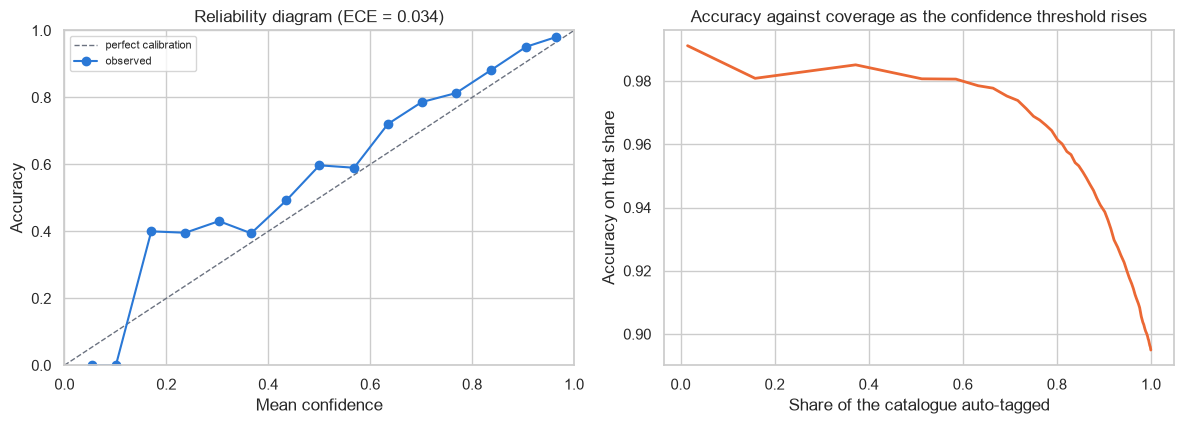

95% accuracy is reachable on 85.5% of the catalogue without human review.
98% accuracy is reachable on 58.5% of the catalogue without human review.


In [40]:
if COMBINE:
    def expected_calibration_error(probabilities, y_true, n_bins=15):
        """ECE with equal-width confidence bins, plus the per-bin data for the diagram."""
        confidence = probabilities.max(axis=1)
        predicted = probabilities.argmax(axis=1)
        correct = (predicted == y_true).astype(float)
        edges = np.linspace(0, 1, n_bins + 1)

        ece, rows = 0.0, []
        for low, high in zip(edges[:-1], edges[1:]):
            in_bin = (confidence > low) & (confidence <= high)
            if not in_bin.any():
                continue
            bin_accuracy, bin_confidence = correct[in_bin].mean(), confidence[in_bin].mean()
            ece += in_bin.mean() * abs(bin_accuracy - bin_confidence)
            rows.append({"confidence": bin_confidence, "accuracy": bin_accuracy,
                         "share": in_bin.mean()})
        return ece, pd.DataFrame(rows)


    final_probabilities = torch.softmax(torch.from_numpy(final_logits), dim=1).numpy()
    ece, reliability = expected_calibration_error(final_probabilities, y_val)
    print(f"Expected Calibration Error: {ece:.4f}")

    confidence = final_probabilities.max(axis=1)
    correct = (final_pred == y_val)
    thresholds = np.linspace(0.05, 0.99, 60)
    coverage = [(confidence >= t).mean() for t in thresholds]
    selective_accuracy = [
        correct[confidence >= t].mean() if (confidence >= t).any() else np.nan for t in thresholds
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    axes[0].plot([0, 1], [0, 1], ls="--", color=MUTED, lw=1, label="perfect calibration")
    axes[0].plot(reliability["confidence"], reliability["accuracy"], "o-", color=PALETTE[0],
                 label="observed")
    axes[0].set(title=f"Reliability diagram (ECE = {ece:.3f})", xlabel="Mean confidence",
                ylabel="Accuracy", xlim=(0, 1), ylim=(0, 1))
    axes[0].legend(fontsize=8)

    axes[1].plot(coverage, selective_accuracy, color=PALETTE[1], lw=2)
    axes[1].set(title="Accuracy against coverage as the confidence threshold rises",
                xlabel="Share of the catalogue auto-tagged", ylabel="Accuracy on that share")
    plt.tight_layout(); save_figure("07_calibration"); plt.show()

    for target_accuracy in [0.95, 0.98]:
        reachable = [c for c, a in zip(coverage, selective_accuracy)
                     if not np.isnan(a) and a >= target_accuracy]
        if reachable:
            print(f"{target_accuracy:.0%} accuracy is reachable on {max(reachable):.1%} "
                  "of the catalogue without human review.")
        else:
            print(f"{target_accuracy:.0%} accuracy is not reachable at any confidence threshold.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


### 8.5 Deployment Cost

Parameter count, checkpoint size and inference latency. The HD/DI extension asks for the model to
sit behind an interface rather than a terminal, which makes single-image latency a design
constraint and not a footnote.

In [41]:
if COMBINE:
    def measure_latency(model, batch_size, repeats=20):
        model.eval()
        dummy = torch.randn(batch_size, 3, IMAGE_TARGET_SIZE[1], IMAGE_TARGET_SIZE[0], device=DEVICE)
        with torch.no_grad():
            for _ in range(3):                       # warm up kernels and caches
                model(dummy)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            start = time.time()
            for _ in range(repeats):
                model(dummy)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
        return (time.time() - start) / repeats / batch_size * 1000


    cost_rows = []
    for name, model, passes in [(reference_name, cnn, 1),
                                (FINAL_NAME, final_model, FINAL_FORWARD_PASSES)]:
        # `total_parameters`, not `count_parameters`. The decoupled model has 99.4% of its
        # weights frozen, so the trainable count describes the stage-2 update rather than the
        # artefact that has to be shipped and loaded, and quoting it here would compare the CNN
        # against a 64K model that does not exist.
        parameters = total_parameters(model)
        cost_rows.append({
            "Model": name,
            "Parameters": parameters,
            "Forward passes per image": passes,
            "Checkpoint size (MB)": parameters * 4 / 1e6 * (len(FINAL_MEMBERS)
                                                            if model is final_model else 1),
            "ms per image (batch 1)": measure_latency(model, 1) * passes,
            "ms per image (batch 128)": measure_latency(model, 128) * passes,
        })
    display(pd.DataFrame(cost_rows).style.format({
        "Parameters": "{:,.0f}", "Forward passes per image": "{:,.0f}",
        "Checkpoint size (MB)": "{:.1f}",
        "ms per image (batch 1)": "{:.2f}", "ms per image (batch 128)": "{:.3f}",
    }))
    print("Latency is the whole deployed pipeline: an ensemble of k models under flip TTA runs "
          "2k forward passes per image, and quoting one member's time would understate it by "
          f"{FINAL_FORWARD_PASSES}x.")
    print(f"Measured on {DEVICE}. A CPU deployment target must be timed on CPU before the "
          "latency figure is quoted in the report.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


,Model,Parameters,Forward passes per image,Checkpoint size (MB),ms per image (batch 1),ms per image (batch 128)
0,2. CNN from scratch,"1,205,084",1,4.8,1.20,0.037
1,4. Ensemble x3 + TTA,"11,232,444",6,134.8,16.20,1.832


Latency is the whole deployed pipeline: an ensemble of k models under flip TTA runs 2k forward passes per image, and quoting one member's time would understate it by 6x.
Measured on cuda. A CPU deployment target must be timed on CPU before the latency figure is quoted in the report.


### 8.6 What the Model Looks At

Gradient saliency on a handful of correct and incorrect predictions. The specific question is
whether the model uses the garment or the studio background: Section 1.5 of notebook 00 noted that
the white background is shared across classes, so any model relying on it is exploiting framing
rather than product appearance and would fail on differently photographed stock.

This is a qualitative check, not evidence of a causal mechanism. It is included because it can
falsify a specific failure mode cheaply, and a few of these panels make a strong appendix figure.

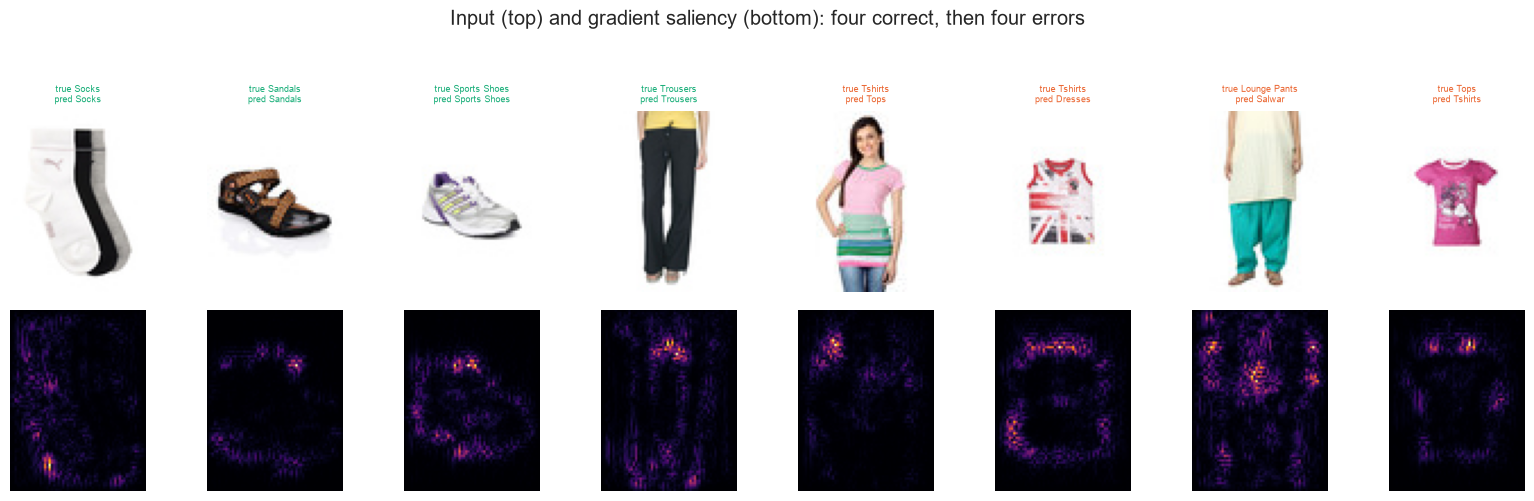

In [42]:
if COMBINE:
    if RUN_SALIENCY:
        def saliency_map(model, image_normalised):
            """Absolute gradient of the top logit with respect to the input, max over channels.

            Run in full precision: autocast would quantise the gradient the figure is showing.
            """
            model.eval()
            image = image_normalised.unsqueeze(0).clone().requires_grad_(True)
            logits = model(image)
            logits[0, logits.argmax()].backward()
            return image.grad.abs().max(dim=1)[0].squeeze().detach().cpu().numpy()

        correct_positions = np.flatnonzero(final_pred == y_val)
        wrong_positions = np.flatnonzero(final_pred != y_val)
        picker = np.random.RandomState(RANDOM_STATE)
        chosen = np.concatenate([
            picker.choice(correct_positions, 4, replace=False),
            picker.choice(wrong_positions, 4, replace=False),
        ])

        index = torch.as_tensor(chosen, device=val_loader.images.device)
        raw = val_loader.images[index].to(DEVICE).permute(0, 3, 1, 2).float().div(255.0)
        normalised = (raw - NORM_MEAN_T) / NORM_STD_T

        fig, axes = plt.subplots(2, 8, figsize=(16, 4.8))
        for column, position in enumerate(chosen):
            axes[0, column].imshow(to_displayable(raw[column]))
            axes[0, column].set_title(
                f"true {CLASSES[y_val[position]]}\npred {CLASSES[final_pred[position]]}",
                fontsize=6.5,
                color=("#1baf7a" if final_pred[position] == y_val[position] else "#eb6834"),
            )
            axes[1, column].imshow(saliency_map(final_model, normalised[column]), cmap="inferno")
            for row in range(2):
                axes[row, column].axis("off")
        fig.suptitle("Input (top) and gradient saliency (bottom): four correct, then four errors",
                     y=1.04)
        plt.tight_layout(); save_figure("08_saliency"); plt.show()
    else:
        print("RUN_SALIENCY is False.")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


### 8.7 The Judgement

Write the recommendation here, against the evidence assembled above rather than against the
headline metric alone. The template below names the six inputs; replace each bracket with the
figure this run actually produced.

> **Recommendation: [model].**
>
> 1. **Aggregate performance.** It reaches [macro-F1] macro-F1 against [x] for the plain CNN and
>    [y] for the HOG baseline, at [z] top-1 accuracy. The majority-class baseline reaches
>    [accuracy] accuracy at essentially zero macro-F1, which is the reason the macro column is
>    the one being read.
> 2. **Where the gain sits.** The bucket breakdown attributes the improvement to the
>    [tail / body] classes, with the head effectively unchanged. The classifier retraining stage
>    accounts for [n] points of it, which supports the Kang et al. claim that the classifier and
>    not the representation was the bottleneck on this distribution.
> 3. **What it costs.** Top-1 accuracy falls by [n] points relative to plain cross-entropy. The
>    trade is [defensible / not defensible] for a catalogue system, where an untagged rare
>    article type is a product that cannot be found at all, while a misfiled common item is
>    still reachable through its neighbours.
> 4. **Error severity.** [n]% of its errors stay inside the correct `subCategory`, against [n]%
>    for the reference model, so its mistakes are systematically cheaper as well as fewer.
> 5. **Reliability.** ECE of [n] means the confidence score can carry an operating threshold:
>    [n]% of the catalogue can be auto-tagged at [n]% accuracy, with the remainder routed for
>    review. This is the property that makes the system deployable rather than merely accurate.
> 6. **Stability.** Across three seeds the macro-F1 spread is [n], so the margin over the
>    reference model [is / is not] larger than the run-to-run variation.
>
> **Where it should not be trusted.** [n] classes score zero F1, all with fewer than [n] training
> images, and [n] further classes have no validation example at all and are therefore unmeasured.
> `Suits` cannot be predicted, as its only record has no image (Section 1.4 of notebook 00). New
> article types should be routed to human review until they reach roughly [n] examples.

## 9. Persisting the Model and Producing Predictions

Four artefacts, and all four are required for the prediction to be reproducible: the weights, the
class-index mapping, the normalisation constants, and the configuration that produced them.
Losing the mapping alone would silently permute every prediction, since nothing in the checkpoint
records which output index means which article type.

In [43]:
if COMBINE:
    ARTEFACT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # The state dict is written as CPU tensors. Saving CUDA tensors would make the checkpoint
    # unloadable on a machine without a GPU unless the reader knows to pass map_location, which is
    # exactly the kind of thing a reproducibility claim should not depend on.
    # An ensemble is not reproducible from one member, so every member's weights are written
    # and the inference-time settings that combine them travel in the same file. A reader who
    # loads this checkpoint has everything needed to reproduce the reported predictions and
    # nothing else has to be inferred from the notebook.
    member_states = []
    for key, factory in FINAL_MEMBERS:
        member = load_banked(key, factory)
        if member is not None:
            member_states.append({"key": key, "architecture": type(member).__name__,
                                  "state_dict": model_state(member)})
            del member
    gc.collect()

    checkpoint = {
        "model_name": FINAL_NAME,
        "architecture": type(final_model).__name__,
        "state_dict": model_state(final_model),      # the representative member
        "ensemble_members": member_states,
        "inference": {
            "member_keys": [key for key, _ in FINAL_MEMBERS],
            "flip_tta": bool(FINAL_TTA),
            "logit_adjustment_tau": float(FINAL_TAU),
            "log_prior": LOG_PRIOR.tolist(),
            "rule": "argmax over log(mean softmax over members and views) - tau * log_prior",
        },
        "classes": CLASSES,
        "normalisation_mean": NORM_MEAN.tolist(),
        "normalisation_std": NORM_STD.tolist(),
        "image_target_size": list(IMAGE_TARGET_SIZE),
        "fingerprint": RUN_FINGERPRINT,
        # Everything Section 1.1 defines that can change a result. The original config recorded
        # eight of these, which was not enough to reproduce the run it described.
        "config": {
            "random_state": RANDOM_STATE, "validation_share": VALIDATION_SHARE,
            "batch_size": BATCH_SIZE, "epochs": EPOCHS, "patience": PATIENCE,
            "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
            "warmup_epochs": WARMUP_EPOCHS, "label_smoothing": LABEL_SMOOTHING,
            "aug_flip_probability": AUG_FLIP_PROBABILITY,
            "aug_rotation_degrees": AUG_ROTATION_DEGREES,
            "aug_translate_fraction": AUG_TRANSLATE_FRACTION,
            "aug_jitter_strength": AUG_JITTER_STRENGTH,
            "logit_adjust_tau": LOGIT_ADJUST_TAU,
            "stage2_epochs": STAGE2_EPOCHS, "stage2_lr": STAGE2_LR,
            "stage2_use_dropout": STAGE2_USE_DROPOUT,
            "seeds": SEEDS, "quick_run": QUICK_RUN,
            "phase1_tta": bool(globals().get("PHASE1_TTA", False)),
            "phase1_tau": float(globals().get("PHASE1_TAU", 0.0)),
            "phase2_aux_weight": globals().get("P2_AUX_WEIGHT"),
            "phase2_sampler_power": globals().get("P2_SAMPLER_POWER"),
            "phase2_stage2_epochs": globals().get("P2_STAGE2_EPOCHS"),
            "phase2_finer_map": globals().get("P2_FINER_MAP"),
            "amp": bool(AMP_ENABLED), "amp_dtype": str(AMP_DTYPE).replace("torch.", ""),
            "deterministic": DETERMINISTIC, "torch_compile": bool(USE_COMPILE),
            "torch_version": torch.__version__,
        },
    }
    atomic_save(checkpoint, ARTEFACT_DIR / "task1_model.pt")
    (ARTEFACT_DIR / "task1_classes.json").write_text(json.dumps(CLASSES, indent=2))
    (ARTEFACT_DIR / "task1_config.json").write_text(json.dumps(checkpoint["config"], indent=2))
    summary_table.to_csv(ARTEFACT_DIR / "task1_results.csv", index=False)

    print("Saved to", ARTEFACT_DIR.resolve())
    for path in sorted(ARTEFACT_DIR.iterdir()):
        if path.is_file():
            print(f"  {path.name}  ({path.stat().st_size / 1e6:.1f} MB)")
    print(f"\nPer-model checkpoints in {CHECKPOINT_DIR.name}/:")
    for path in sorted(CHECKPOINT_DIR.iterdir()):
        print(f"  {path.name}  ({path.stat().st_size / 1e6:.1f} MB)")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


Saved to C:\Users\Administrator\Downloads\Machine-Learning-Assignment-2-feat-task-1\Machine-Learning-Assignment-2-feat-task-1\models\task1
  task1_classes.json  (0.0 MB)
  task1_config.json  (0.0 MB)
  task1_model.pt  (180.0 MB)
  task1_results.csv  (0.0 MB)
  task1_seed_study.csv  (0.0 MB)

Per-model checkpoints in checkpoints/:
  model_cnn.pt  (10.2 MB)
  model_hog_svm.joblib  (1.9 MB)
  model_hog_svm_scores.npz  (3.3 MB)
  model_phase2_backbone_efb440.pt  (50.1 MB)
  model_phase2_decoupled_efb440.pt  (50.3 MB)
  model_resnet_decoupled.pt  (50.4 MB)
  model_resnet_logit_adjusted.pt  (49.9 MB)
  model_resnet_stage1.pt  (49.9 MB)
  model_seed_cnn_1337.pt  (10.2 MB)
  model_seed_cnn_2024.pt  (10.2 MB)
  model_seed_resnet___decoupled_1337.pt  (50.4 MB)
  model_seed_resnet___decoupled_1337_backbone.pt  (49.9 MB)
  model_seed_resnet___decoupled_2024.pt  (50.4 MB)
  model_seed_resnet___decoupled_2024_backbone.pt  (49.9 MB)
  model_stage2_power_0p0.pt  (50.5 MB)
  model_stage2_power_0p25.pt 

In [44]:
if COMBINE:
    # Every id in the template receives a prediction. The test images pass through the identical
    # deterministic transform and the identical training-fitted normalisation constants; no test
    # statistic is computed and nothing here is fitted.
    template = pd.read_csv(PREDICTION_TEMPLATE)
    print(f"Template rows: {len(template):,} | columns: {list(template.columns)}")

    test_paths = [str(Path(TEST_IMAGE_DIR) / f"{image_id}.jpg") for image_id in template["id"]]
    missing = [p for p in test_paths if not Path(p).exists()]
    assert not missing, f"{len(missing)} test images are missing, e.g. {missing[:3]}"

    width, height = IMAGE_TARGET_SIZE
    X_test_images = np.empty((len(test_paths), height, width, 3), dtype=np.uint8)
    start = time.time()
    for position, path in enumerate(test_paths):
        X_test_images[position] = load_image_array(path, target_size=IMAGE_TARGET_SIZE, scale=False)
        if position and position % 5000 == 0:
            print(f"  decoding: {position:,} / {len(test_paths):,}")
    print(f"Decoded {len(X_test_images):,} test images in {time.time() - start:.0f}s "
          f"({X_test_images.nbytes / 1e6:.0f} MB)")

    test_loader = BatchStream(X_test_images, np.zeros(len(X_test_images), dtype=np.int64),
                              batch_size=512, augment=False, shuffle=False)

    # The identical function that produced the validation score in Section 7.5, called with the
    # identical members, views and tau. Using one code path for both is what makes the reported
    # validation macro-F1 an estimate of this file's quality rather than of a similar procedure's.
    test_probabilities = predict_probabilities(test_loader, FINAL_MEMBERS, tta=FINAL_TTA)
    test_logits = np.log(test_probabilities + 1e-12) - FINAL_TAU * LOG_PRIOR

    predictions = template.copy()
    predictions[TARGET] = [CLASSES[index] for index in test_logits.argmax(axis=1)]

    # The adjustment moves probability mass toward rare classes, so the count of distinct
    # predicted classes should rise relative to tau = 0. If it does not, the adjustment is not
    # doing what Section 7.5 claims and the claim should be dropped from the report.
    unadjusted_classes = len(np.unique(test_probabilities.argmax(axis=1)))
    print(f"Distinct classes predicted at tau = 0: {unadjusted_classes} | "
          f"at tau = {FINAL_TAU:.2f}: {len(np.unique(test_logits.argmax(axis=1)))}")

    assert len(predictions) == len(template)
    assert predictions[TARGET].notna().all()
    assert set(predictions["id"]) == set(template["id"])

    prediction_path = OUTPUT_DIR / "task1_predictions.csv"
    predictions.to_csv(prediction_path, index=False)
    np.save(OUTPUT_DIR / "task1_test_logits.npy", test_logits.astype(np.float32))
    print("Written:", prediction_path.resolve())
    display(predictions.head())
    print("\nPredicted class distribution (top 10):")
    print(predictions[TARGET].value_counts().head(10).to_string())
    print(f"\nDistinct classes predicted: {predictions[TARGET].nunique()} of {N_CLASSES} available")

    del X_test_images, test_loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    report_memory("after prediction")
else:
    print('Skipped in worker mode: this runs on the combine machine.')


Template rows: 5,829 | columns: ['id', 'gender', 'articleType', 'season', 'usage']
  decoding: 5,000 / 5,829
Decoded 5,829 test images in 2s (84 MB)
Distinct classes predicted at tau = 0: 99 | at tau = 0.00: 99
Written: C:\Users\Administrator\Downloads\Machine-Learning-Assignment-2-feat-task-1\Machine-Learning-Assignment-2-feat-task-1\outputs\task1_predictions.csv


,id,gender,articleType,season,usage
0,52003,NaN,Watches,NaN,NaN
1,52007,NaN,Dresses,NaN,NaN
2,52017,NaN,Bra,NaN,NaN
3,52021,NaN,Nightdress,NaN,NaN
4,52023,NaN,Jackets,NaN,NaN



Predicted class distribution (top 10):
articleType
Perfume and Body Mist    410
Watches                  325
Handbags                 318
Sarees                   287
Kurtas                   275
Tshirts                  273
Tops                     218
Heels                    213
Lipstick                 198
Bra                      197

Distinct classes predicted: 99 of 124 available
[memory after prediction] host RSS 3.10 GB | device allocated 0.96 GB reserved 1.40 GB


#### A Note on the Predicted Distribution

Compare the predicted class distribution against the training distribution printed above. A model
that predicts only the head classes on the test set has not generalised its tail behaviour,
whatever its validation macro-F1 says, and the discrepancy is worth a sentence in the report.

Two qualifications carry over from notebook 00. Eleven test images are byte identical to training
images (Section 3.6), so any test-set claim is very slightly a memorisation score. And `Suits`
cannot appear in this output at all, because its single record has no image file.

The other three target columns are left as the template supplied them. Tasks 2 and 3 fill their
own columns, and the four are merged into a single submission file before upload.